# PCCP断丝信号特征挖掘

本 notebook 对应开发方案中的 Notebook01-Notebook08，并新增 Notebook09 分类测试。输入是六类已经计算好的特征向量，不重新计算原始波形特征；目标是从数百个候选特征中筛出能够稳定表征 PCCP 断丝响应的少量核心特征。全流程核心代码位于 `src/pccp_feature_mining`，notebook 负责组织实验、展示结果、解释指标含义并给出结论。

## 00 环境初始化与显示工具

本节只做三件事：定位项目根目录、导入显示工具、定义统一的表格/图片展示函数。后续每个表都用 `show_table()` 输出“表号 + 标题 + 表格”，每张结果图都用 `show_image()` 在 notebook 内直接显示。

In [5]:
from pathlib import Path
import sys
import json
import re
from datetime import datetime
import pandas as pd

pd.options.display.float_format = '{:.3f}'.format

from IPython.display import Image, Markdown, display


def find_project_root(start: Path) -> Path:
    """向上查找.git，保证从notebooks目录启动时也能定位项目根目录。"""
    p = start.resolve()
    for candidate in [p] + list(p.parents):
        if (candidate / '.git').exists():
            return candidate
    return p


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from pccp_feature_mining.feature_schema import add_feature_meaning_columns, describe_feature_list

# 需求2：每次重新运行程序存储时，新建一个带时间戳的子文件夹；表格、图片分别放 tables/、plots/
RUN_STAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR = PROJECT_ROOT / 'outputs/PCCP_feature_mining_notebook' / f'run_{RUN_STAMP}'
TABLES_DIR = RUN_DIR / 'tables'
PLOTS_DIR = RUN_DIR / 'plots'
for _d in (RUN_DIR, TABLES_DIR, PLOTS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

TABLE_NO = 0
FIGURE_NO = 0


def _file_slug(title: str) -> str:
    """把中英文标题转成文件名安全片段（保留中文，剔除非法字符）。"""
    slug = re.sub(r'[\\/:*?"<>|#%&\s]+', '_', str(title).strip())
    return slug[:60].strip('_') or 'untitled'


def show_table(title: str, frame: pd.DataFrame, rows: int | None = None) -> pd.DataFrame:
    """显示表格（默认最多10行），并把完整表格另存为带序号的CSV，注明源文件地址。"""
    global TABLE_NO
    TABLE_NO += 1
    out = add_feature_meaning_columns(frame)
    csv_path = TABLES_DIR / f'表{TABLE_NO:02d}_{_file_slug(title)}.csv'
    out.to_csv(csv_path, index=False, encoding='utf-8-sig', float_format='%.3f')
    display(Markdown(f'**表 {TABLE_NO} {title}**'))
    display(Markdown(f'<sub>完整数据已存储: `{csv_path}`</sub>'))
    shown = out.head(rows) if rows is not None else out.head(10)
    shown_display = shown.copy()
    float_cols = shown_display.select_dtypes(include=['float']).columns
    shown_display.loc[:, float_cols] = shown_display.loc[:, float_cols].round(3)
    display(shown_display)
    return shown_display


def show_image(title: str, path: Path) -> None:
    """显示结果图，并把图片另存为带序号的文件名（保留扩展名）。"""
    import shutil

    global FIGURE_NO
    FIGURE_NO += 1
    src = Path(path)
    if not src.exists():
        display(Markdown(f'**图 {FIGURE_NO} {title}**（图片不存在: `{src}`）'))
        return
    dst = PLOTS_DIR / f'图{FIGURE_NO:02d}_{_file_slug(title)}{src.suffix}'
    shutil.move(str(src), str(dst))
    display(Markdown(f'**图 {FIGURE_NO} {title}**'))
    display(Markdown(f'<sub>图片已存储: `{dst}`</sub>'))
    display(Image(filename=str(dst)))


print('项目根目录:', PROJECT_ROOT)
print('本轮输出目录:', RUN_DIR)


项目根目录: E:\codes\ZZ-BK
本轮输出目录: E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308


## 01 数据读取与质量检查

本节实现“数据读取与质量检查”。算法上先递归读取六类输入目录下的 `features*.csv`，使用显式目录标签覆盖 CSV 内部可能不一致的标签，再统一生成 `source_label`、`target_label`、`signal_family`、`flow_condition`、`event_id` 和 `sampling_group_id`。

本版新增行级有效特征检测：旧逻辑只检查 CSV 表头列数和是否为空表，因此类似 `features_20260905_173711_part_0001.csv` 这种“661列、17066行，但 6568 行没有任何有效频带特征值”的文件不会被跳过。现在读取时会计算每行非空有效特征数，并剔除低于 `CONFIG.min_valid_feature_values_per_row` 的行；这些行不会进入 Notebook02-Notebook09 的分布、判别、冗余、组合、稳定性、跨流速或分类分析。

可调参数：`min_feature_csv_columns` 控制文件级表头列数门槛；`min_valid_feature_values_per_row` 控制行级有效特征数门槛。若后续特征总数变化，建议设置为“预期有效特征数的 10%-20%”或至少 50，本 notebook 当前使用 100。

 
 ### missing_rate 缺失率公式

$$\text{missing\_rate} = 1 - \frac{\text{finite\_count}}{N}$$

其中：
- $N$ = 总行数（`len(x)`）
- $\text{finite\_count}$ = 有效值数量（去除 `inf`、`-inf`、`NaN` 后的非空值数量）

代码实现（`quality_control.py:50`）：
```python
finite = s.replace([np.inf, -np.inf], np.nan).dropna()
missing_rate = 1.0 - finite.size / n
```

含义：`missing_rate` 表示该特征中无效值（缺失/无穷大）占总样本数的比例，值域 $[0, 1]$。

In [ ]:
from pccp_feature_mining.config import FeatureInput, MiningConfig
from pccp_feature_mining.data_loader import load_feature_dataset
from pccp_feature_mining.quality_control import build_dataset_summary, build_feature_quality, feature_list_frame
from pccp_feature_mining.report_generator import write_csv, write_markdown_summary

FEATURE_INPUTS = [
    FeatureInput('FL00', PROJECT_ROOT / r'outputs/DATA09_v0-flow_features_20260904_121425/DATA09_v0-flow_features'),
    FeatureInput('FL05', PROJECT_ROOT / r'outputs/DATA09_v0-flow_features_20260904_121425/DATA09_v0.5-flow_features'),
    FeatureInput('BK00', PROJECT_ROOT / r'outputs/DATA09_multi_label_single_event_features/v0-bk_features_BK00'),
    FeatureInput('QJ00', PROJECT_ROOT / r'outputs/DATA09_multi_label_single_event_features/v0-qj_features_QJ00'),
    FeatureInput('BK05', PROJECT_ROOT / r'outputs/DATA09_multi_label_single_event_features/v05-bk_features_BK05'),
    FeatureInput('QJ05', PROJECT_ROOT / r'outputs/DATA09_multi_label_single_event_features/v05-qj_features_QJ05'),
]

CONFIG = MiningConfig(
    # 输出目录：存放所有分析结果、中间产物和可视化图表
    output_dir=PROJECT_ROOT / 'outputs/PCCP_feature_mining_notebook',
    # 特征输入列表：定义六类信号的特征CSV路径，每类信号一个目录
    feature_inputs=tuple(FEATURE_INPUTS),
    # 每个CSV最少列数：剔除列数不足的异常特征文件
    min_feature_csv_columns=100,
    # 每行最少有效特征值：剔除缺失值过多的样本行
    min_valid_feature_values_per_row=100,
    # 随机种子：保证实验可复现
    random_state=42,
    # 相关性阈值：Spearman相关系数超过此值的特征视为冗余，保留其中一个
    correlation_threshold=0.92,
    # Bootstrap重采样轮数：用于估计特征排名的稳定性
    bootstrap_rounds=200,
    # Bootstrap取前K个：每轮重采样后保留排名前K的特征，统计出现频率
    bootstrap_top_ks=(10, 20, 30),
    # 单特征判别重复平衡抽样次数：多数类下采样到少数类数量后重复计算，取均值
    discrimination_balance_repeats=30,
    # mRMR保留特征数：最大相关最小冗余算法保留的特征数量
    mrmr_top_n=80,
    # 相关性分析最大样本数：超过此行数时随机抽样，加速计算
    max_correlation_rows=6000,
    # 分布分析展示Top-N：箱线图和KDE图统一展示Top8，排布为4列2行
    distribution_top_n=8,
    # 投影分析最大样本数：PCA/UMAP降维可视化时的最大样本数
    projection_max_rows=8000,
    # 组合特征数量列表：测试不同大小的特征子集（5,10,20,30,50个特征）
    combination_feature_counts=(5, 10, 20, 30, 50),
    # SFS候选特征数：序列前向选择的初始候选特征池大小
    sfs_candidate_count=30,
    # SFS最大选择数：序列前向选择算法最多选择的特征数量
    sfs_max_selected=15,
    # 分类测试特征数量列表：分类评估时测试的特征子集大小
    classification_feature_counts=(5, 10, 20, 30, 50),
    # 分类训练集每类最大样本数：超过时随机抽样，控制训练时间
    classification_max_train_rows_per_class=3000,
    # 每标签最大样本数：None表示使用全部数据；快速调试可设为1000
    max_rows_per_label=None,  # 快速调试可设为1000；正式分析保持None。
)

config_table = pd.DataFrame([
    {'参数': 'min_feature_csv_columns', '当前值': CONFIG.min_feature_csv_columns, '含义': '文件级最低列数；列数低于该值的CSV直接跳过'},
    {'参数': 'min_valid_feature_values_per_row', '当前值': CONFIG.min_valid_feature_values_per_row, '含义': '行级最低有效特征数；低于该值的样本行不进入后续分析'},
    {'参数': 'bootstrap_rounds', '当前值': CONFIG.bootstrap_rounds, '含义': 'Bootstrap重复抽样次数'},
    {'参数': 'bootstrap_top_ks', '当前值': str(CONFIG.bootstrap_top_ks), '含义': '统计Top-K出现频率的K值'},
    {'参数': 'discrimination_balance_repeats', '当前值': CONFIG.discrimination_balance_repeats, '含义': '第3章单特征判别多数类下采样重复次数'},
])
show_table('Notebook01 关键质量控制参数', config_table)

**表 1 Notebook01 关键质量控制参数**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表01_Notebook01_关键质量控制参数.csv`</sub>

,参数,当前值,含义
0,min_feature_csv_columns,100,文件级最低列数；列数低于该值的CSV直接跳过
1,min_valid_feature_values_per_row,100,行级最低有效特征数；低于该值的样本行不进入后续分析
2,bootstrap_rounds,200,Bootstrap重复抽样次数
3,bootstrap_top_ks,"(10, 20, 30)",统计Top-K出现频率的K值
4,discrimination_balance_repeats,30,第3章单特征判别多数类下采样重复次数


,参数,当前值,含义
0,min_feature_csv_columns,100,文件级最低列数；列数低于该值的CSV直接跳过
1,min_valid_feature_values_per_row,100,行级最低有效特征数；低于该值的样本行不进入后续分析
2,bootstrap_rounds,200,Bootstrap重复抽样次数
3,bootstrap_top_ks,"(10, 20, 30)",统计Top-K出现频率的K值
4,discrimination_balance_repeats,30,第3章单特征判别多数类下采样重复次数


In [7]:
dataset = load_feature_dataset(
    feature_inputs=CONFIG.feature_inputs,
    min_feature_csv_columns=CONFIG.min_feature_csv_columns,
    min_valid_feature_values_per_row=CONFIG.min_valid_feature_values_per_row,
    max_rows_per_label=CONFIG.max_rows_per_label,
    random_state=CONFIG.random_state,
)
df = dataset.frame
feature_cols = list(dataset.feature_columns)

dataset_summary = build_dataset_summary(df)
feature_quality = build_feature_quality(df, feature_cols)
feature_list = feature_list_frame(feature_cols)
load_issues = dataset.load_report[
    (dataset.load_report['status'] != 'ok') | (dataset.load_report['dropped_low_valid_feature_rows'] > 0)
].copy()

write_csv(dataset.load_report, RUN_DIR / 'load_report.csv')
write_csv(dataset_summary, RUN_DIR / 'dataset_summary.csv')
write_csv(feature_list, RUN_DIR / 'feature_list.csv')
write_csv(feature_quality, RUN_DIR / 'quality_report.csv')

print(f'样本行数: {len(df):,}, 特征数: {len(feature_cols):,}')
show_table('六类样本读取汇总', dataset_summary)
show_table('有效特征清单样例', feature_list, rows=10)
show_table('特征质量报告Top20', feature_quality, rows=10)
show_table('读取异常与低有效特征行审计', load_issues)

样本行数: 22,206, 特征数: 632


**表 2 六类样本读取汇总**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表02_六类样本读取汇总.csv`</sub>

,source_label,target_label,signal_family,flow_condition,rows,source_files,sampling_groups
0,BK00,BK,BK,v0,102,17,17
1,BK05,BK,BK,v0.5,60,10,10
2,FL00,Other,FL,v0,10498,84,10498
3,FL05,Other,FL,v0.5,10538,87,10538
4,QJ00,Other,QJ,v0,648,108,108
5,QJ05,Other,QJ,v0.5,360,60,60


**表 3 有效特征清单样例**

...

,feature,特征中文含义,non_missing,missing_rate,unique_values,mean,std,median,iqr,min,max,outlier_rate_iqr3
160,b_10k_20k__A_env,10-20 kHz频带，包络不对称度，描述包络上升与衰减形状差异,22206,0.000,22196,0.025,0.662,0.031,1.231,-1.157,1.115,0.000
205,b_10k_20k__CF_res,10-20 kHz频带，残差峰值因子，残差峰值与RMS之比，描述残差冲击峰值相对能量水平的突出程度,22206,0.000,22206,5.042,1.640,4.657,1.123,1.857,20.928,0.043
159,b_10k_20k__C_E,10-20 kHz频带，能量质心位置，描述能量在时间轴上的前后偏置,22206,0.000,22206,0.015,0.003,0.015,0.003,0.001,0.029,0.015
165,b_10k_20k__C_bulge,10-20 kHz频带，包络鼓包集中度，描述局部鼓包结构强弱,22206,0.000,5997,0.089,0.057,0.080,0.067,0.004,0.879,0.005
232,b_10k_20k__C_damp,10-20 kHz频带，阻尼原子匹配度，描述阻尼振荡成分强弱,22206,0.000,22206,0.060,0.039,0.053,0.041,0.001,0.701,0.009
192,b_10k_20k__C_f,10-20 kHz频带，频率曲率或中心频率相关量，描述主频率轨迹形态,22206,0.000,22009,3425939.184,456020.723,3457141.366,538322.640,262715.427,5087469.331,0.003
185,b_10k_20k__C_h,10-20 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...,22206,0.000,1761,24237.975,4781.902,25390.625,1018.118,1324.593,27878.782,0.053
231,b_10k_20k__D_WPT,10-20 kHz频带，高频-低频小波包能差，描述高频异常偏置,22206,0.000,22206,-1.000,0.000,-1.000,0.000,-1.000,-1.000,0.059
235,b_10k_20k__Delta_J,10-20 kHz频带，加入损伤原子后的误差下降率，描述损伤分量解释增益,22206,0.000,22206,9.282,107.009,0.005,0.013,0.000,6565.993,0.132
191,b_10k_20k__Delta_f_span,10-20 kHz频带，频率跨度，描述主要能量覆盖的频率范围,22206,0.000,4,4876.172,98.948,4882.812,0.000,1953.125,4882.812,0.000


**表 5 读取异常与低有效特征行审计**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表05_读取异常与低有效特征行审计.csv`</sub>

,label,path,status,rows,retained_rows,dropped_low_valid_feature_rows,columns,feature_columns_detected,min_valid_feature_values,median_valid_feature_values,max_valid_feature_values,message
0,FL00,E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features...,ok,17066,10498,6568,661,622,0,622.000,622,剔除有效特征数小于100的行6568条
1,FL05,E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features...,ok,20000,10538,9462,661,622,0,622.000,622,剔除有效特征数小于100的行9462条
2,FL05,E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features...,skipped,0,0,0,21,0,0,0.000,0,表头列数21小于阈值100


,label,path,status,rows,retained_rows,dropped_low_valid_feature_rows,columns,feature_columns_detected,min_valid_feature_values,median_valid_feature_values,max_valid_feature_values,message
0,FL00,E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features...,ok,17066,10498,6568,661,622,0,622.000,622,剔除有效特征数小于100的行6568条
1,FL05,E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features...,ok,20000,10538,9462,661,622,0,622.000,622,剔除有效特征数小于100的行9462条
2,FL05,E:\codes\ZZ-BK\outputs\DATA09_v0-flow_features...,skipped,0,0,0,21,0,0,0.000,0,表头列数21小于阈值100


## 02 特征分布分析

本章对候选特征在不同标签分组上的分布进行可视化和指标化分析，目的是直观判断哪些特征在不同类别之间存在明显差异。所有箱线图和 KDE 图统一展示 Top8 特征，版式为 4 列 2 行，避免单图过长。

- $可视化方法说明$

| 图表 | 英文全称 | 中文全称 | 观察目的 |
|------|----------|----------|----------|
| 箱线图 | Box Plot | 箱线图 | 观察中位数（箱体中线）和四分位距（箱体高度）。四分位距 IQR = Q3 - Q1，即箱体高度，反映中间50%数据的离散程度；须线延伸到 1.5×IQR 边界，须线之外的离散点即离群值（outliers），用于识别极端样本 |
| KDE分布图 | Kernel Density Estimation | 核密度估计图 | 用平滑概率密度曲线观察各类样本在同一特征上的分布重叠程度；曲线重叠越多，说明特征区分能力越弱 |
| PCA投影图 | Principal Component Analysis | 主成分分析投影图 | 用二维投影观察整体特征空间的类间结构，点集分离越好说明特征区分能力越强 |
| UMAP投影图 | Uniform Manifold Approximation and Projection | 均匀流形逼近与投影 | 非线性降维投影，保留局部结构，可发现PCA无法捕捉的非线性类间差异 |

- $KDE核密度的含义与计算$

KDE（Kernel Density Estimation，核密度估计）是一种非参数概率密度估计方法。给定某一类样本在某个特征上的取值 $x_1,x_2,\dots,x_n$，KDE 不假设其服从正态分布，而是在每个样本点附近放置一个核函数，再把这些核函数叠加成平滑密度曲线：

$$
\hat f_h(x)=\frac{1}{nh}\sum_{i=1}^{n}K\left(\frac{x-x_i}{h}\right)
$$

其中 $K(\cdot)$ 是核函数，本 notebook 使用 `scipy.stats.gaussian_kde` 的高斯核；$h$ 是带宽（bandwidth），控制平滑程度。带宽过小会让曲线过度抖动，带宽过大会掩盖真实差异；这里使用 Scott 规则作为自动带宽，适合做批量特征筛查。

- $第二节使用的分布差异指标$

本节采用“两级指标”：

1. **F-ratio 快速预筛**：对全部候选特征计算类间均值方差 / 类内方差均值，用于快速找到均值差异明显的候选特征。
2. **KDE 重叠面积评估展示特征的分布差异**：对预筛出的 Top8 特征，按类别两两计算 KDE 曲线重叠面积：

$$
\mathrm{OVL}(a,b)=\int_{-\infty}^{+\infty}\min\left(\hat f_a(x),\hat f_b(x)\right)\,dx
$$

并定义：

$$
\mathrm{kde\_separation}=1-\mathrm{OVL}
$$

`kde_overlap_mean` 越小，说明各类分布平均重叠越少；`kde_separation_mean` 越大，说明特征分布差异越明显。多类比较时，对所有标签对的 KDE 重叠面积取均值；二类比较时就是这两类的重叠面积。KDE 相关依据来自 Rosenblatt（1956）、Parzen（1962）和 Silverman（1986）的非参数密度估计工作。

- $类间均值方差与类内方差均值的计算$

对**某个特征**，先将全部样本按标签分组（共 $k$ 类），再分别计算两种方差：

**“类”的定义**：这里的“类”指按标签（`source_label`，如 `BK00/BK05/FL00/FL05/QJ00/QJ05`）分组后的每一组信号。第 $i$ 个类 = 标签为第 $i$ 种的所有样本的集合。例如对某特征，把所有样本按 `source_label` 分成6组（用6个标签时 $k=6$），每组样本数量可能不同，但都属于同一个信号类别。

以特征 `b_40k_60k__SF` 为例：把该特征所有样本按 `source_label` 分成6组 -> 每个标签算出一个组均值 $m_i$ -> 这6个 $m_i$ 求方差得类间均值方差；每个标签算组内内部方差，6个求平均得类内方差均值。

**1. 类间均值方差 $\sigma^2_{between}$**（衡量各类均值之间的离散程度）

$$
\sigma^2_{between} = \frac{1}{k}\sum_{i=1}^{k}(m_i - \bar{m})^2
$$

其中 $m_i$ 是第 $i$ 类的均值（该组所有样本的特征值平均值），$\bar{m}$ 是 $k$ 个类均值的平均值。步骤：先求各类均值 `group_means`，再对这 $k$ 个均值求总体方差（`var(ddof=0)`，除以 $k$）。

**2. 类内方差均值 $\sigma^2_{within}$**（衡量各类内部波动的平均程度）

$$
\sigma^2_{within} = \frac{1}{k}\sum_{i=1}^{k}s_i^2
$$

其中 $s_i^2$ 是第 $i$ 类内部的方差（该组样本内部的离散程度）。步骤：先算每类内部方差（`groupby(labels).var(ddof=0)`），再对这 $k$ 个类内方差求平均（`.mean()`）。

**3. 二者比值（F-ratio）**

$$
\text{f\_ratio} = \frac{\sigma^2_{between}}{\sigma^2_{within} + \epsilon}, \quad \epsilon = 10^{-12}
$$

$\epsilon$ 用于防止分母为零。该值越大，说明特征在各类之间均值差异越明显（类间越分散、类内越集中），越适合用于分布展示候选的快速预筛。

**本章子节结构**

- **2.1** 六标签分布比较：`BK00/BK05/FL00/FL05/QJ00/QJ05`
- **2.2** `BK00 vs BK05`：同为断丝信号，比较零流速与半流速的差异
- **2.3** `BK00 vs QJ00`：零流速下，断丝与敲击的差异
- **2.4** `BK05 vs QJ05`：半流速下，断丝与敲击的差异
- **2.5** `(BK00+BK05) vs (QJ00+QJ05)`：断丝集合 vs 敲击集合
- **2.6** `(BK00+BK05) vs (QJ00+QJ05+FL00+FL05)`：断丝集合 vs 全部非断丝集合

**参考文献**

[1] Rosenblatt M. Remarks on some nonparametric estimates of a density function[J]. *The Annals of Mathematical Statistics*, 1956, 27(3): 832-837.  
[2] Parzen E. On estimation of a probability density function and mode[J]. *The Annals of Mathematical Statistics*, 1962, 33(3): 1065-1076.  
[3] Silverman B W. *Density Estimation for Statistics and Data Analysis*[M]. London: Chapman & Hall, 1986.

- $????????$

??????? `2.7`????????????????????????????????????????????????????????????????

### 2.1 六标签分布比较

比较 `BK00/BK05/FL00/FL05/QJ00/QJ05` 六个来源标签上的特征分布。

**表 6 六类分布差异最大的展示特征（F-ratio预筛与KDE重叠度）**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表06_六类分布差异最大的展示特征（F-ratio预筛与KDE重叠度）.csv`</sub>

,feature,six_class_f_ratio,between_var,within_var,kde_pair_count,kde_overlap_mean,kde_overlap_min,kde_overlap_max,kde_separation_mean,kde_separation_max,特征中文含义
7,b_1k_10k__epsilon_rec,2084.758,207663482.797,99610.332,15,0.354,0.000,0.966,0.646,1.000,1-10 kHz频带，整体重构归一化误差，原始信号与谐波重构信号之差的能量占原始能量的比例
3,b_30k_40k__C_h,6607.837,960670095.278,145383.442,15,0.395,0.000,0.990,0.605,1.000,30-40 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
5,b_30k_40k__SF,5843.843,0.220,0.000,15,0.453,0.000,1.000,0.547,1.000,30-40 kHz频带，谱平坦度，描述频谱接近噪声或窄带结构的程度
1,b_40k_60k__SF,23759.596,0.219,0.000,15,0.458,0.000,1.000,0.542,1.000,40-60 kHz频带，谱平坦度，描述频谱接近噪声或窄带结构的程度
2,b_30k_40k__epsilon_2x,11926.571,0.884,0.000,6,0.823,0.721,0.962,0.177,0.279,30-40 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
6,b_20k_30k__epsilon_2x,2702.804,0.837,0.000,6,0.849,0.789,0.929,0.151,0.211,20-30 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
4,b_30k_40k__H2_ratio,6157.242,0.218,0.000,6,0.904,0.874,0.949,0.096,0.126,30-40 kHz频带，二倍频能量比，描述二倍频结构强度
0,b_40k_60k__epsilon_2x,666364.717,0.871,0.000,6,0.909,0.884,0.950,0.091,0.116,40-60 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差


**表 7 PCA解释方差**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表07_PCA解释方差.csv`</sub>

,component,explained_variance_ratio
0,PC1,0.188
1,PC2,0.110


**图 1 六类特征箱线图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图01_六类特征箱线图.png`</sub>

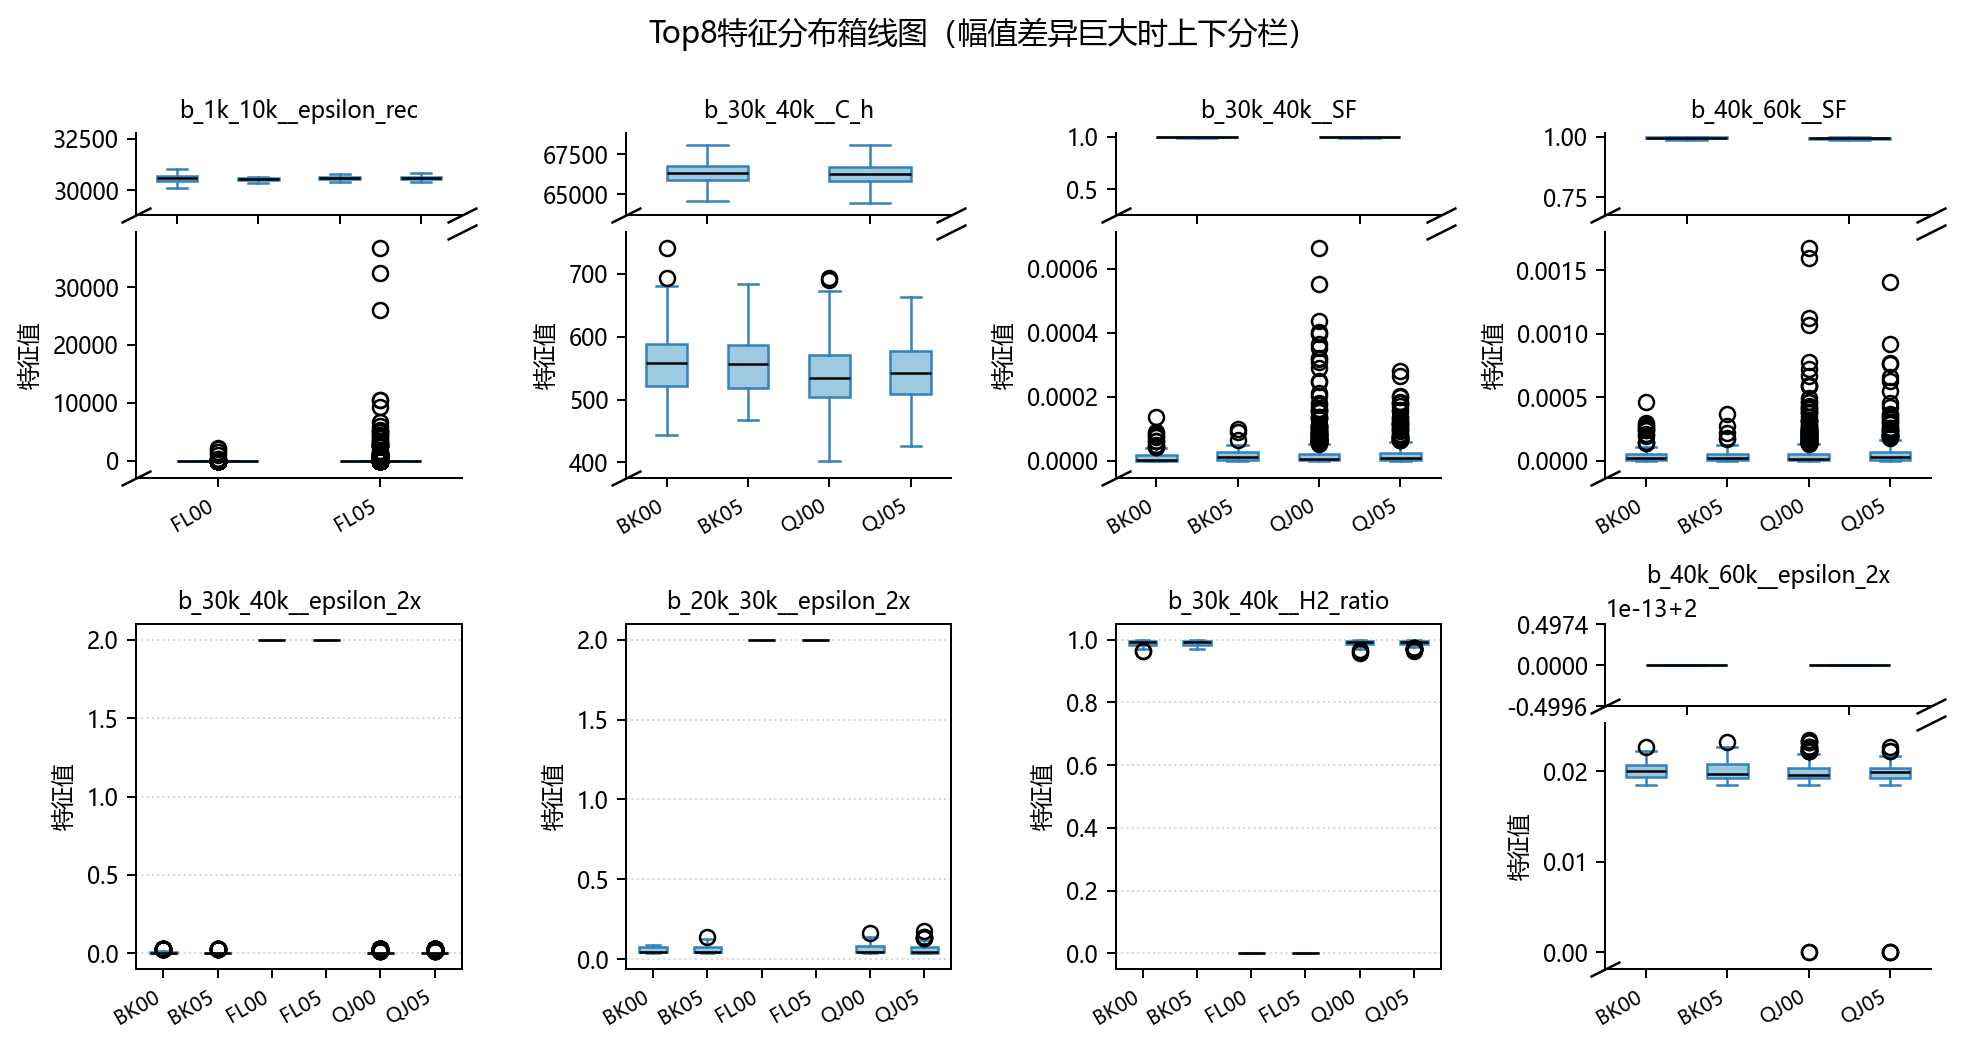

**图 2 六类特征KDE分布图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图02_六类特征KDE分布图.png`</sub>

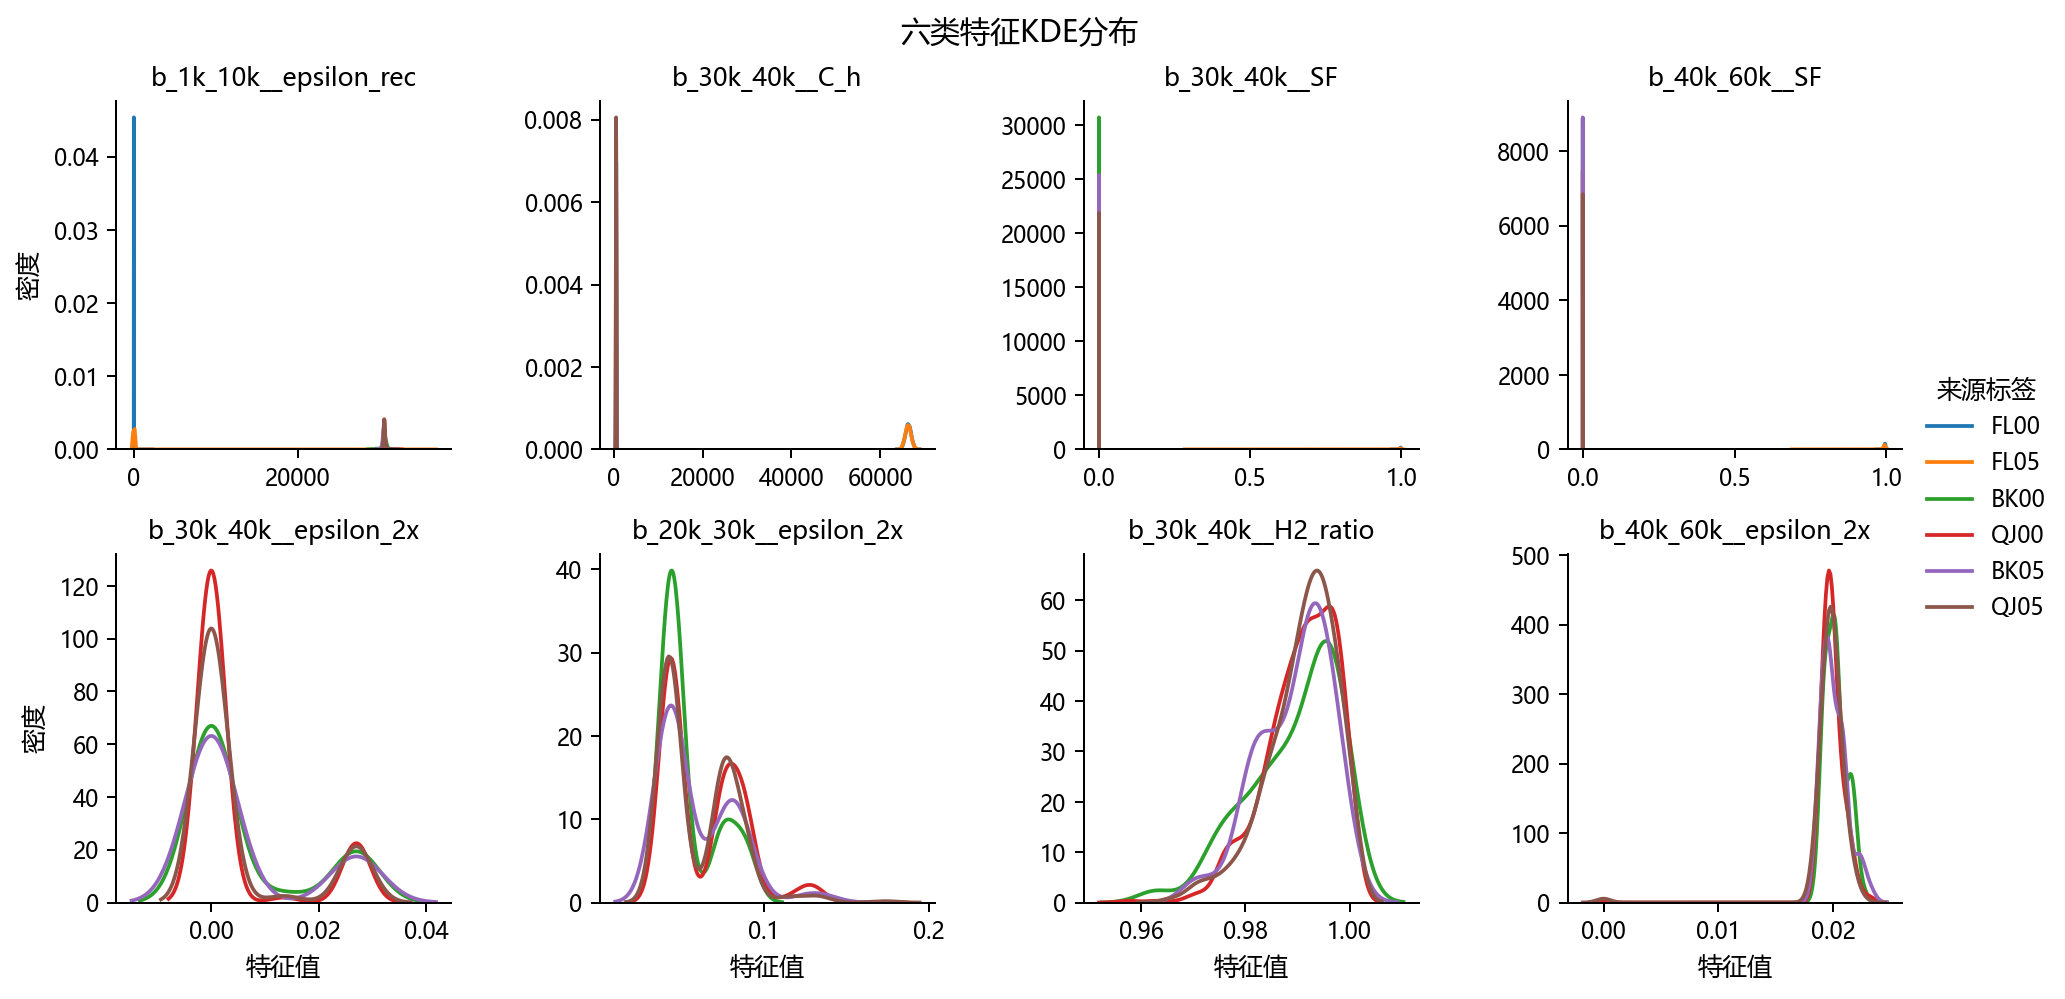

**图 3 六类特征PCA投影图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图03_六类特征PCA投影图.png`</sub>

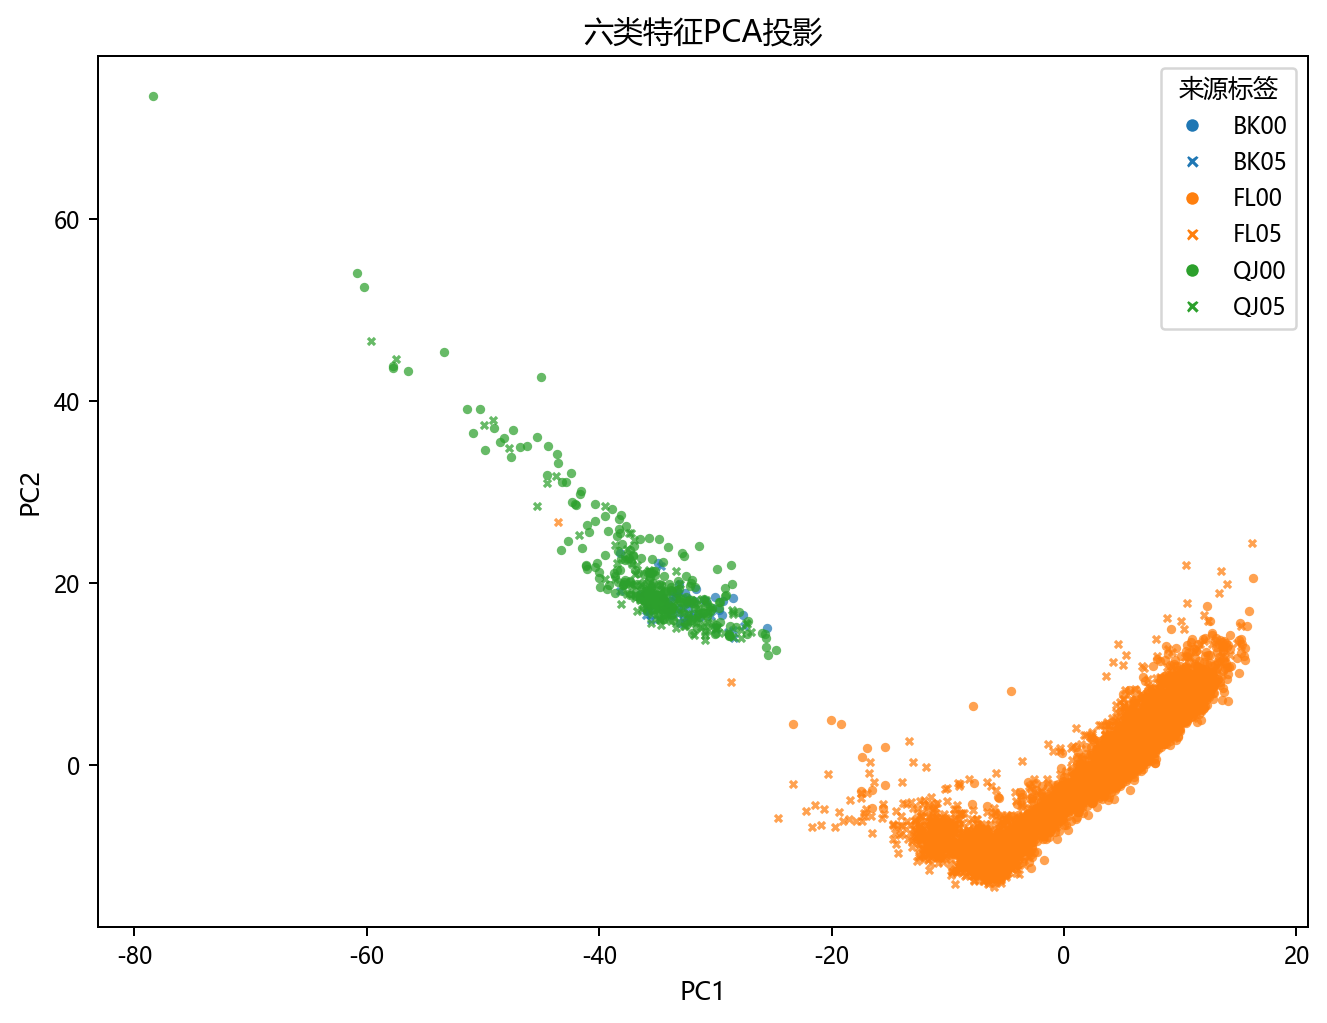

In [8]:
from pccp_feature_mining.distribution_analysis import (
    select_distribution_features,
    run_pca_projection,
    run_umap_projection,
    plot_feature_kde_by_label,
    plot_projection,
    compute_kde_overlap_summary,
)
from pccp_feature_mining.visualization import plot_final_ranking, plot_top_feature_boxplots


def attach_kde_metrics_to_ranking(frame, ranking, label_col, top_n=8):
    candidates = ranking.head(top_n).copy()
    kde_metrics = compute_kde_overlap_summary(
        frame,
        candidates['feature'].tolist(),
        label_col=label_col,
        random_state=CONFIG.random_state,
    )
    out = candidates.merge(kde_metrics, on='feature', how='left')
    ratio_cols = [col for col in ['kde_separation_mean', 'six_class_f_ratio', 'f_ratio'] if col in out.columns]
    ascending = [False for _ in ratio_cols]
    return out.sort_values(ratio_cols, ascending=ascending) if ratio_cols else out

six_class_distribution_candidates = select_distribution_features(df, feature_cols, top_n=CONFIG.distribution_top_n)
six_class_distribution_features = attach_kde_metrics_to_ranking(df, six_class_distribution_candidates, 'source_label', top_n=8)
pca_projection, pca_explained = run_pca_projection(df, feature_cols, max_rows=CONFIG.projection_max_rows, random_state=CONFIG.random_state)
umap_projection = run_umap_projection(df, feature_cols, max_rows=min(CONFIG.projection_max_rows, 5000), random_state=CONFIG.random_state)

write_csv(add_feature_meaning_columns(six_class_distribution_features), RUN_DIR / 'six_class_distribution_features.csv')
write_csv(pca_projection, RUN_DIR / 'six_class_pca_projection.csv')
write_csv(pca_explained, RUN_DIR / 'six_class_pca_explained_variance.csv')
write_csv(umap_projection, RUN_DIR / 'six_class_umap_projection.csv')

boxplot_path = RUN_DIR / 'plots/six_class_feature_boxplots.png'
kde_path = RUN_DIR / 'plots/six_class_feature_kde.png'
pca_path = RUN_DIR / 'plots/six_class_pca.png'
umap_path = RUN_DIR / 'plots/six_class_umap.png'

# ---- 内联箱线图：幅值差异巨大的特征改用断裂坐标轴（截断轴）；代码内联，便于调整 ----
import numpy as np
import matplotlib.pyplot as plt
from pccp_feature_mining.feature_schema import impute_with_median, numeric_feature_frame
from pccp_feature_mining.visualization import _configure_font

_configure_font()
_box_break_ratio = 50.0    # 最大/最小类中位数比值超过该值 => 幅值差异巨大，改用断裂坐标轴
_box_split_factor = 10.0   # 中位数高于几何均值的该倍数视为高幅值类（进入顶部小面板）
_box_fliers = True         # 底部主体面板是否显示离群点（四分位/须线/离群点默认全部可见）
_box_feats = six_class_distribution_features['feature'].head(8).tolist()
_box_df = df
_box_label = 'source_label'
_box_ncols = 4
_box_path = boxplot_path

_box_x = impute_with_median(numeric_feature_frame(_box_df, _box_feats))
_box_p = pd.concat([_box_df[_box_label].reset_index(drop=True).to_frame(), _box_x.reset_index(drop=True)], axis=1)
_box_classes = sorted(str(_c) for _c in _box_p[_box_label].astype(str).unique())
_box_rows = -(-len(_box_feats) // _box_ncols)
_box_fig, _box_axes = plt.subplots(_box_rows, _box_ncols, figsize=(11.0, 2.9 * _box_rows), squeeze=False)
_box_fig.suptitle('Top8特征分布箱线图（幅值差异巨大时上下分栏）', y=0.995, fontsize=12)
_box_bp_kw = dict(widths=0.5, patch_artist=True,
                  medianprops=dict(color='black', lw=1.0),
                  boxprops=dict(facecolor='#9ecae1', edgecolor='#3182bd'),
                  whiskerprops=dict(color='#3182bd'), capprops=dict(color='#3182bd'))
_box_bk_kw = dict(marker=[(-1, -0.5), (1, 0.5)], markersize=12, linestyle='none', color='k', mec='k', mew=1, clip_on=False)

for _i, _feat in enumerate(_box_feats):
    _g = _box_axes[_i // _box_ncols][_i % _box_ncols]
    _cols_data = []
    _meds = []
    for _c in _box_classes:
        _v = np.asarray(_box_p.loc[_box_p[_box_label].astype(str) == _c, _feat].dropna(), dtype=float)
        if _v.size == 0:
            continue
        _cols_data.append((_c, _v))
        _meds.append(float(np.median(_v)))
    if not _cols_data:
        _g.axis('off')
        continue
    _med_abs = np.abs(np.array(_meds))
    _use_break = bool(_med_abs.size >= 2 and _med_abs.min() > 0 and _med_abs.max() / _med_abs.min() >= _box_break_ratio)
    _top = []
    _bot = []
    if _use_break:
        _gm = np.sqrt(_med_abs.max() * _med_abs.min())
        _top = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) > _box_split_factor * _gm]
        _bot = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) <= _box_split_factor * _gm]
        if not _top or not _bot:
            _use_break = False
    if not _use_break:
        _g.boxplot([_v for _, _v in _cols_data], positions=np.arange(len(_cols_data)), showfliers=_box_fliers, **_box_bp_kw)
        _g.set_title(_feat, fontsize=9)
        _g.set_xticks(np.arange(len(_cols_data)))
        _g.set_xticklabels([_c for _c, _ in _cols_data], rotation=30, ha='right', fontsize=8)
        _g.set_ylabel('特征值', fontsize=9)
        _g.grid(axis='y', ls=':', alpha=0.5)
        continue
    _gs = _g.get_subplotspec().subgridspec(2, 1, height_ratios=[1, 3], hspace=0.10)
    _g.axis('off')
    _a_top = _box_fig.add_subplot(_gs[0])
    _a_bot = _box_fig.add_subplot(_gs[1])
    _a_top.boxplot([_v for _, _v in _top], positions=np.arange(len(_top)), showfliers=False, **_box_bp_kw)
    _a_bot.boxplot([_v for _, _v in _bot], positions=np.arange(len(_bot)), showfliers=_box_fliers, **_box_bp_kw)
    _a_top.set_title(_feat, fontsize=9)
    _a_bot.set_ylabel('特征值', fontsize=9)
    _ymin_t = min(float(np.min(_v)) for _, _v in _top)
    _ymax_t = max(float(np.max(_v)) for _, _v in _top)
    _a_top.set_ylim(_ymin_t - 0.05 * (_ymax_t - _ymin_t + 1e-12), _ymax_t + 0.05 * (_ymax_t - _ymin_t + 1e-12))
    _ymin_b = min(float(np.min(_v)) for _, _v in _bot)
    _ymax_b = max(float(np.max(_v)) for _, _v in _bot)
    _a_bot.set_ylim(_ymin_b - 0.08 * (_ymax_b - _ymin_b + 1e-12), _ymax_b + 0.08 * (_ymax_b - _ymin_b + 1e-12))
    _a_top.set_xticks(np.arange(len(_top)))
    _a_top.set_xticklabels([_c for _c, _ in _top], fontsize=7)
    _a_bot.set_xticks(np.arange(len(_bot)))
    _a_bot.set_xticklabels([_c for _c, _ in _bot], rotation=30, ha='right', fontsize=8)
    for _sp in ('top', 'right'):
        _a_top.spines[_sp].set_visible(False)
        _a_bot.spines[_sp].set_visible(False)
    _a_top.plot([0, 1], [0, 0], transform=_a_top.transAxes, **_box_bk_kw)
    _a_bot.plot([0, 1], [0, 1], transform=_a_bot.transAxes, **_box_bk_kw)

_box_fig.tight_layout()
_box_fig.savefig(_box_path, dpi=180, bbox_inches='tight')
plt.close(_box_fig)
plot_feature_kde_by_label(df, six_class_distribution_features['feature'].head(8).tolist(), kde_path, col_wrap=4)
plot_projection(pca_projection, 'PC1', 'PC2', pca_path, '六类特征PCA投影')
if not umap_projection.empty:
    plot_projection(umap_projection, 'UMAP1', 'UMAP2', umap_path, '六类特征UMAP投影')

show_table('六类分布差异最大的展示特征（F-ratio预筛与KDE重叠度）', six_class_distribution_features, rows=10)
show_table('PCA解释方差', pca_explained)
show_image('六类特征箱线图', boxplot_path)
show_image('六类特征KDE分布图', kde_path)
show_image('六类特征PCA投影图', pca_path)
if not umap_projection.empty:
    show_image('六类特征UMAP投影图', umap_path)

In [9]:
# 2.1 已在上方完成（六类特征分布分析）
print('2.1 六标签分布比较已在上方完成')

2.1 六标签分布比较已在上方完成


### 2.2 BK00 vs BK05

同为断丝信号，比较零流速（BK00）与半流速（BK05）的特征分布差异。

**表 8 2.2 BK00 vs BK05 F-ratio与KDE分布差异指标**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表08_2.2_BK00_vs_BK05_F-ratio与KDE分布差异指标.csv`</sub>

,feature,f_ratio,between_var,within_var,kde_pair_count,kde_overlap_mean,kde_overlap_min,kde_overlap_max,kde_separation_mean,kde_separation_max,特征中文含义
0,b_1k_10k__G_gap,1.586,0.001,0.000,1,0.225,0.225,0.225,0.775,0.775,1-10 kHz频带，脊线间隔稳定性，描述主脊线与次脊线分离程度
4,b_1k_10k__rho_down,1.541,0.000,0.000,1,0.236,0.236,0.236,0.764,0.764,1-10 kHz频带，脊线下降率，主脊线频率下降斜率低于 -阈值的帧占比，描述频率下扫的活跃程度
1,b_1k_10k__rho_up,1.566,0.000,0.000,1,0.239,0.239,0.239,0.761,0.761,1-10 kHz频带，脊线上升率，主脊线频率上升斜率超过阈值的帧占比，描述频率上扫的活跃程度
2,b_1k_10k__H2_ratio,1.561,0.010,0.006,1,0.245,0.245,0.245,0.755,0.755,1-10 kHz频带，二倍频能量比，描述二倍频结构强度
3,b_1k_50k__rho_up,1.550,0.000,0.000,1,0.257,0.257,0.257,0.743,0.743,1-50 kHz频带，脊线上升率，主脊线频率上升斜率超过阈值的帧占比，描述频率上扫的活跃程度
5,b_1k_100k__rho_up,1.503,0.000,0.000,1,0.266,0.266,0.266,0.734,0.734,1-100 kHz频带，脊线上升率，主脊线频率上升斜率超过阈值的帧占比，描述频率上扫的活跃程度
6,b_1k_50k__G_gap,1.412,0.001,0.000,1,0.270,0.270,0.270,0.730,0.730,1-50 kHz频带，脊线间隔稳定性，描述主脊线与次脊线分离程度
7,b_1k_100k__G_gap,1.361,0.001,0.000,1,0.284,0.284,0.284,0.716,0.716,1-100 kHz频带，脊线间隔稳定性，描述主脊线与次脊线分离程度


**图 4 2.2 BK00 vs BK05 箱线图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图04_2.2_BK00_vs_BK05_箱线图.png`</sub>

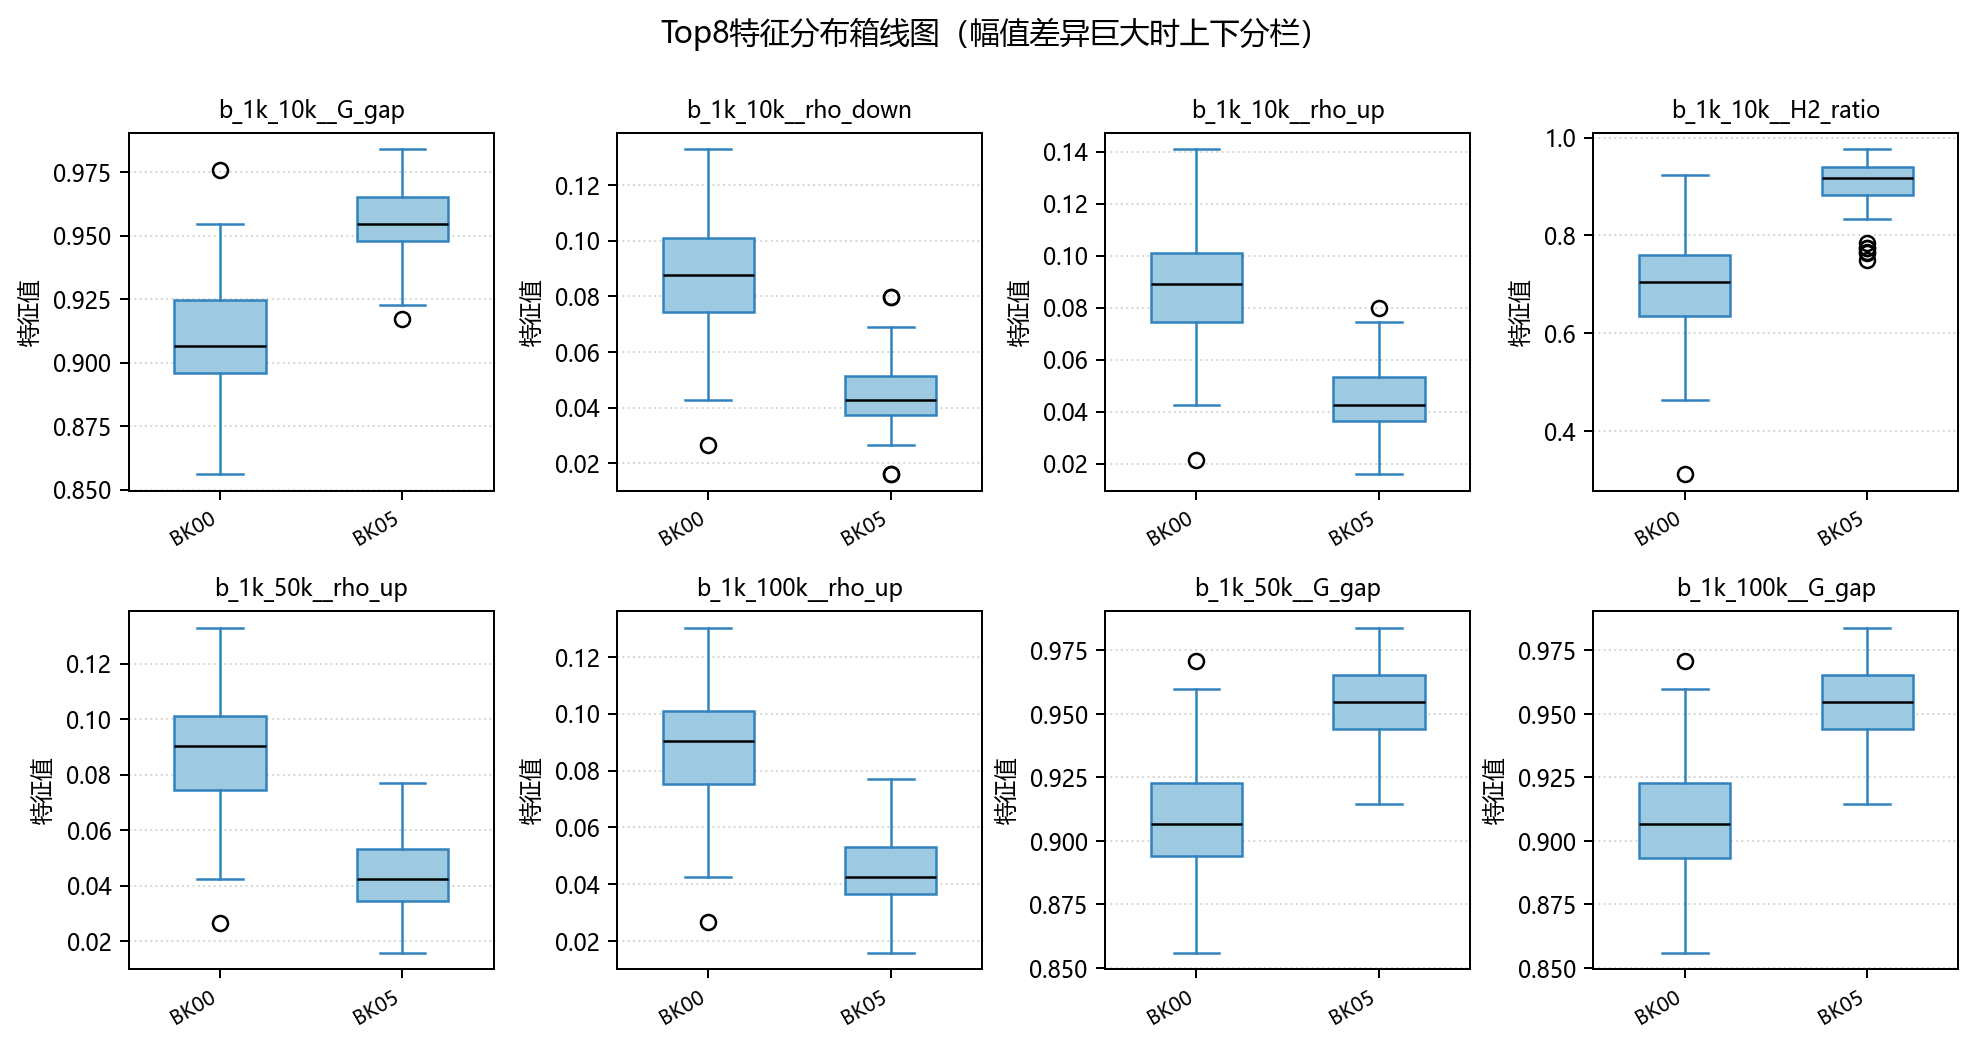

**图 5 2.2 BK00 vs BK05 KDE分布图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图05_2.2_BK00_vs_BK05_KDE分布图.png`</sub>

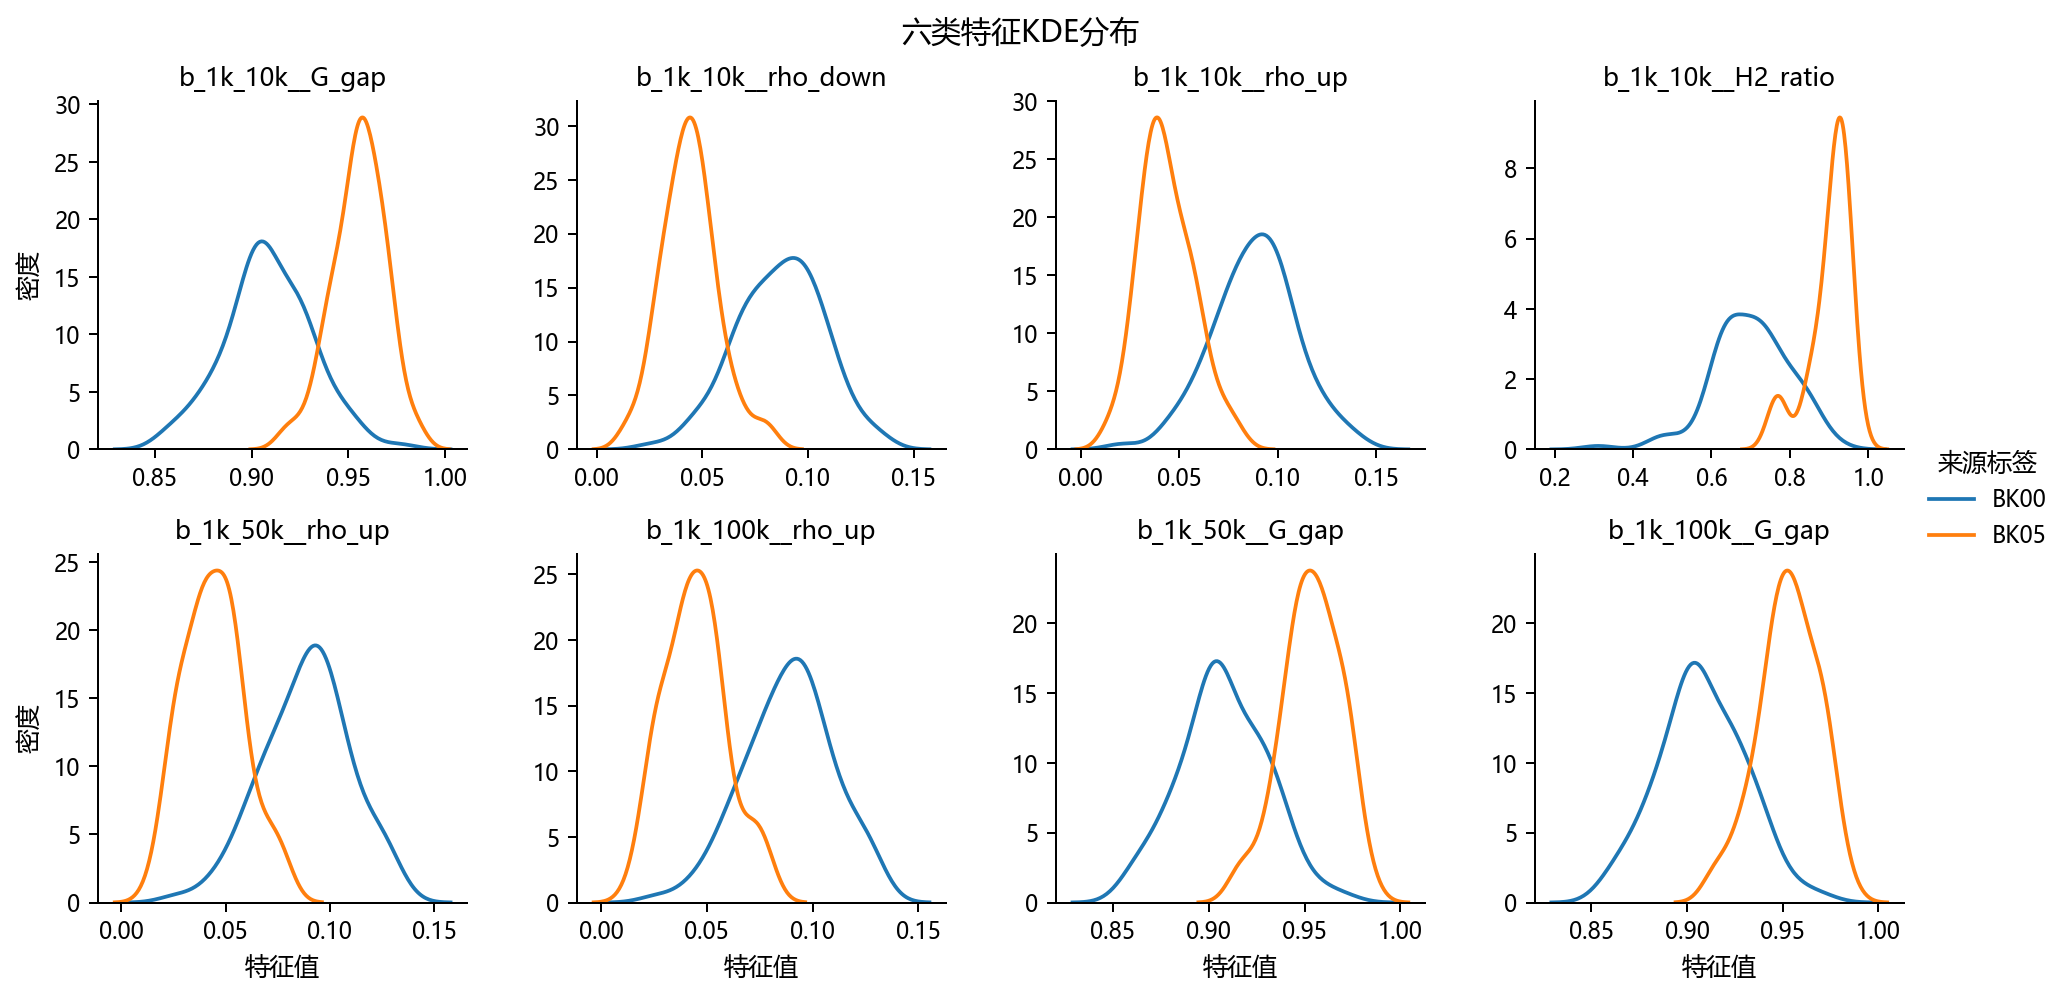

**图 6 2.2 BK00 vs BK05 PCA投影图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图06_2.2_BK00_vs_BK05_PCA投影图.png`</sub>

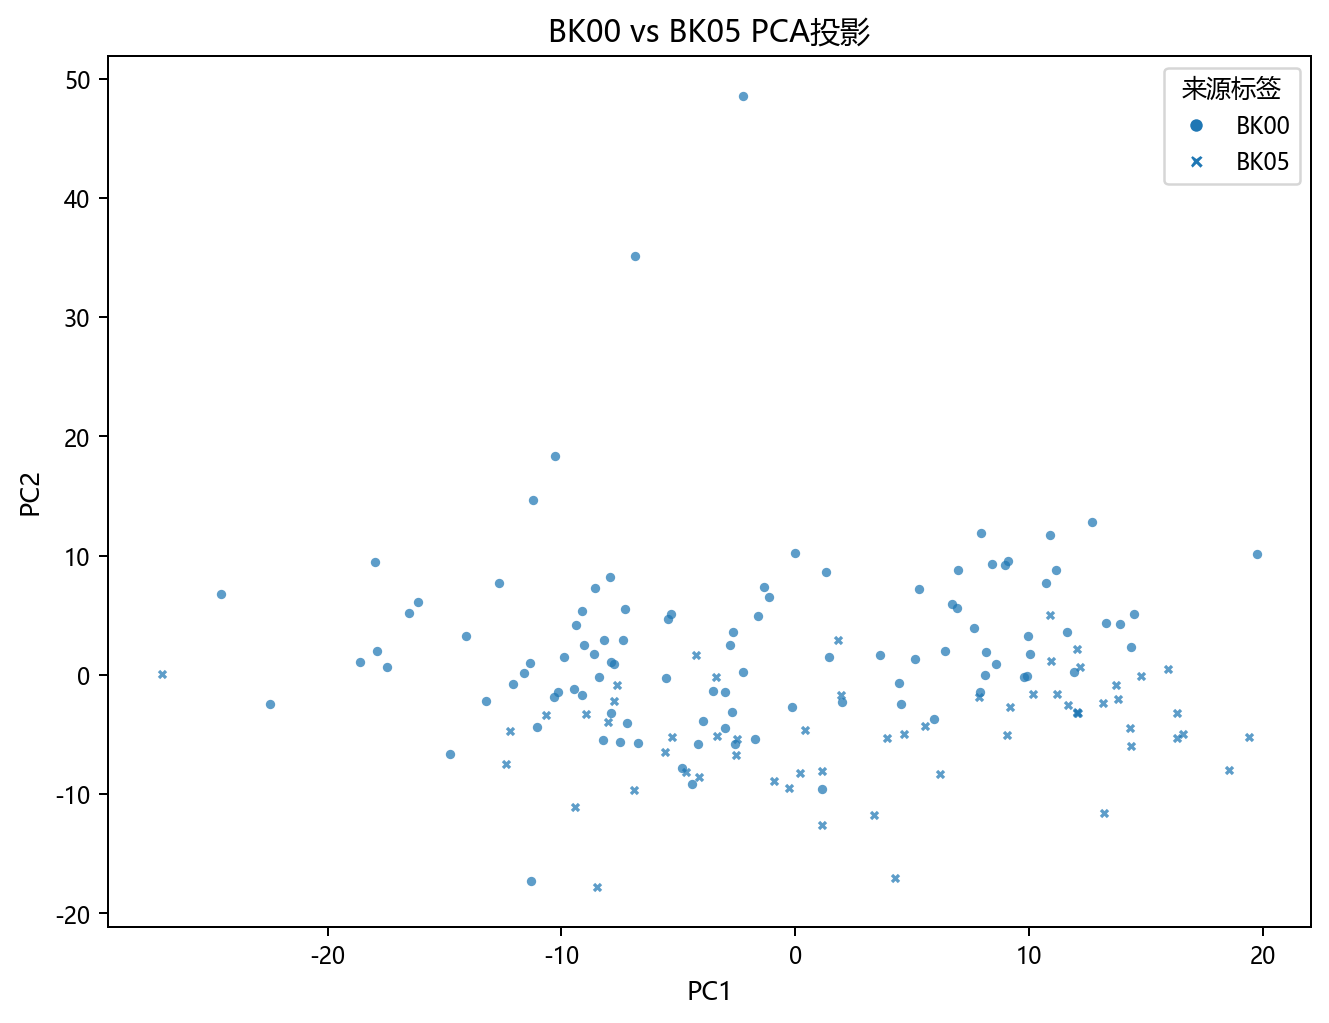

In [10]:
# 2.2 BK00 vs BK05
df_bk00_bk05 = df[df['source_label'].isin(['BK00', 'BK05'])].copy()

def compute_two_class_f_ratio(frame, feature_columns, label_col='source_label', class_a='BK00', class_b='BK05'):
    """计算二分类F-ratio：类间方差/类内方差均值。"""
    from pccp_feature_mining.feature_schema import impute_with_median, numeric_feature_frame
    x = impute_with_median(numeric_feature_frame(frame, feature_columns))
    rows = []
    labels = frame[label_col].astype(str)
    for feature in feature_columns:
        values = x[feature]
        group_means = values.groupby(labels).mean()
        between = float(group_means.var(ddof=0))
        within = float(values.groupby(labels).var(ddof=0).mean())
        score = between / (within + 1e-12)
        rows.append({'feature': feature, 'f_ratio': score, 'between_var': between, 'within_var': within})
    return pd.DataFrame(rows).sort_values('f_ratio', ascending=False)

bk00_bk05_f_ratio = compute_two_class_f_ratio(df_bk00_bk05, feature_cols, class_a='BK00', class_b='BK05')
bk00_bk05_distribution_metrics = attach_kde_metrics_to_ranking(df_bk00_bk05, bk00_bk05_f_ratio, 'source_label', top_n=8)
top_features_2_2 = bk00_bk05_distribution_metrics['feature'].tolist()

# 箱线图
boxplot_path_2_2 = RUN_DIR / 'plots/bk00_vs_bk05_boxplots.png'
# ---- 内联箱线图：幅值差异巨大的特征改用断裂坐标轴（截断轴）；代码内联，便于调整 ----
import numpy as np
import matplotlib.pyplot as plt
from pccp_feature_mining.feature_schema import impute_with_median, numeric_feature_frame
from pccp_feature_mining.visualization import _configure_font

_configure_font()
_box_break_ratio = 50.0    # 最大/最小类中位数比值超过该值 => 幅值差异巨大，改用断裂坐标轴
_box_split_factor = 10.0   # 中位数高于几何均值的该倍数视为高幅值类（进入顶部小面板）
_box_fliers = True         # 底部主体面板是否显示离群点（四分位/须线/离群点默认全部可见）
_box_feats = top_features_2_2[:8]
_box_df = df_bk00_bk05
_box_label = 'source_label'
_box_ncols = 4
_box_path = boxplot_path_2_2

_box_x = impute_with_median(numeric_feature_frame(_box_df, _box_feats))
_box_p = pd.concat([_box_df[_box_label].reset_index(drop=True).to_frame(), _box_x.reset_index(drop=True)], axis=1)
_box_classes = sorted(str(_c) for _c in _box_p[_box_label].astype(str).unique())
_box_rows = -(-len(_box_feats) // _box_ncols)
_box_fig, _box_axes = plt.subplots(_box_rows, _box_ncols, figsize=(11.0, 2.9 * _box_rows), squeeze=False)
_box_fig.suptitle('Top8特征分布箱线图（幅值差异巨大时上下分栏）', y=0.995, fontsize=12)
_box_bp_kw = dict(widths=0.5, patch_artist=True,
                  medianprops=dict(color='black', lw=1.0),
                  boxprops=dict(facecolor='#9ecae1', edgecolor='#3182bd'),
                  whiskerprops=dict(color='#3182bd'), capprops=dict(color='#3182bd'))
_box_bk_kw = dict(marker=[(-1, -0.5), (1, 0.5)], markersize=12, linestyle='none', color='k', mec='k', mew=1, clip_on=False)

for _i, _feat in enumerate(_box_feats):
    _g = _box_axes[_i // _box_ncols][_i % _box_ncols]
    _cols_data = []
    _meds = []
    for _c in _box_classes:
        _v = np.asarray(_box_p.loc[_box_p[_box_label].astype(str) == _c, _feat].dropna(), dtype=float)
        if _v.size == 0:
            continue
        _cols_data.append((_c, _v))
        _meds.append(float(np.median(_v)))
    if not _cols_data:
        _g.axis('off')
        continue
    _med_abs = np.abs(np.array(_meds))
    _use_break = bool(_med_abs.size >= 2 and _med_abs.min() > 0 and _med_abs.max() / _med_abs.min() >= _box_break_ratio)
    _top = []
    _bot = []
    if _use_break:
        _gm = np.sqrt(_med_abs.max() * _med_abs.min())
        _top = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) > _box_split_factor * _gm]
        _bot = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) <= _box_split_factor * _gm]
        if not _top or not _bot:
            _use_break = False
    if not _use_break:
        _g.boxplot([_v for _, _v in _cols_data], positions=np.arange(len(_cols_data)), showfliers=_box_fliers, **_box_bp_kw)
        _g.set_title(_feat, fontsize=9)
        _g.set_xticks(np.arange(len(_cols_data)))
        _g.set_xticklabels([_c for _c, _ in _cols_data], rotation=30, ha='right', fontsize=8)
        _g.set_ylabel('特征值', fontsize=9)
        _g.grid(axis='y', ls=':', alpha=0.5)
        continue
    _gs = _g.get_subplotspec().subgridspec(2, 1, height_ratios=[1, 3], hspace=0.10)
    _g.axis('off')
    _a_top = _box_fig.add_subplot(_gs[0])
    _a_bot = _box_fig.add_subplot(_gs[1])
    _a_top.boxplot([_v for _, _v in _top], positions=np.arange(len(_top)), showfliers=False, **_box_bp_kw)
    _a_bot.boxplot([_v for _, _v in _bot], positions=np.arange(len(_bot)), showfliers=_box_fliers, **_box_bp_kw)
    _a_top.set_title(_feat, fontsize=9)
    _a_bot.set_ylabel('特征值', fontsize=9)
    _ymin_t = min(float(np.min(_v)) for _, _v in _top)
    _ymax_t = max(float(np.max(_v)) for _, _v in _top)
    _a_top.set_ylim(_ymin_t - 0.05 * (_ymax_t - _ymin_t + 1e-12), _ymax_t + 0.05 * (_ymax_t - _ymin_t + 1e-12))
    _ymin_b = min(float(np.min(_v)) for _, _v in _bot)
    _ymax_b = max(float(np.max(_v)) for _, _v in _bot)
    _a_bot.set_ylim(_ymin_b - 0.08 * (_ymax_b - _ymin_b + 1e-12), _ymax_b + 0.08 * (_ymax_b - _ymin_b + 1e-12))
    _a_top.set_xticks(np.arange(len(_top)))
    _a_top.set_xticklabels([_c for _c, _ in _top], fontsize=7)
    _a_bot.set_xticks(np.arange(len(_bot)))
    _a_bot.set_xticklabels([_c for _c, _ in _bot], rotation=30, ha='right', fontsize=8)
    for _sp in ('top', 'right'):
        _a_top.spines[_sp].set_visible(False)
        _a_bot.spines[_sp].set_visible(False)
    _a_top.plot([0, 1], [0, 0], transform=_a_top.transAxes, **_box_bk_kw)
    _a_bot.plot([0, 1], [0, 1], transform=_a_bot.transAxes, **_box_bk_kw)

_box_fig.tight_layout()
_box_fig.savefig(_box_path, dpi=180, bbox_inches='tight')
plt.close(_box_fig)

# KDE图
kde_path_2_2 = RUN_DIR / 'plots/bk00_vs_bk05_kde.png'
plot_feature_kde_by_label(df_bk00_bk05, top_features_2_2[:8], kde_path_2_2, col_wrap=4)

# PCA投影
pca_projection_2_2, pca_explained_2_2 = run_pca_projection(df_bk00_bk05, feature_cols, max_rows=CONFIG.projection_max_rows, random_state=CONFIG.random_state)
pca_path_2_2 = RUN_DIR / 'plots/bk00_vs_bk05_pca.png'
plot_projection(pca_projection_2_2, 'PC1', 'PC2', pca_path_2_2, 'BK00 vs BK05 PCA投影')

show_table('2.2 BK00 vs BK05 F-ratio与KDE分布差异指标', bk00_bk05_distribution_metrics, rows=10)
show_image('2.2 BK00 vs BK05 箱线图', boxplot_path_2_2)
show_image('2.2 BK00 vs BK05 KDE分布图', kde_path_2_2)
show_image('2.2 BK00 vs BK05 PCA投影图', pca_path_2_2)

### 2.3 BK00 vs QJ00

零流速下，断丝信号（BK00）与敲击信号（QJ00）的特征分布差异。

**表 9 2.3 BK00 vs QJ00 F-ratio与KDE分布差异指标**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表09_2.3_BK00_vs_QJ00_F-ratio与KDE分布差异指标.csv`</sub>

,feature,f_ratio,between_var,within_var,kde_pair_count,kde_overlap_mean,kde_overlap_min,kde_overlap_max,kde_separation_mean,kde_separation_max,特征中文含义
0,b_1k_10k__H2_ratio,0.824,0.006,0.007,1,0.383,0.383,0.383,0.617,0.617,1-10 kHz频带，二倍频能量比，描述二倍频结构强度
5,b_10k_20k__epsilon_env,0.620,0.925,1.493,1,0.397,0.397,0.397,0.603,0.603,10-20 kHz频带，包络拟合残差，描述包络形状偏离基准模型的程度
1,b_1k_10k__rho_up,0.704,0.000,0.000,1,0.427,0.427,0.427,0.573,0.573,1-10 kHz频带，脊线上升率，主脊线频率上升斜率超过阈值的帧占比，描述频率上扫的活跃程度
3,b_1k_10k__G_gap,0.688,0.000,0.000,1,0.431,0.431,0.431,0.569,0.569,1-10 kHz频带，脊线间隔稳定性，描述主脊线与次脊线分离程度
2,b_1k_10k__rho_down,0.702,0.000,0.000,1,0.436,0.436,0.436,0.564,0.564,1-10 kHz频带，脊线下降率，主脊线频率下降斜率低于 -阈值的帧占比，描述频率下扫的活跃程度
4,b_1k_50k__rho_up,0.633,0.000,0.000,1,0.451,0.451,0.451,0.549,0.549,1-50 kHz频带，脊线上升率，主脊线频率上升斜率超过阈值的帧占比，描述频率上扫的活跃程度
6,b_1k_100k__rho_up,0.612,0.000,0.000,1,0.457,0.457,0.457,0.543,0.543,1-100 kHz频带，脊线上升率，主脊线频率上升斜率超过阈值的帧占比，描述频率上扫的活跃程度
7,b_1k_50k__rho_down,0.602,0.000,0.000,1,0.473,0.473,0.473,0.527,0.527,1-50 kHz频带，脊线下降率，主脊线频率下降斜率低于 -阈值的帧占比，描述频率下扫的活跃程度


**图 7 2.3 BK00 vs QJ00 箱线图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图07_2.3_BK00_vs_QJ00_箱线图.png`</sub>

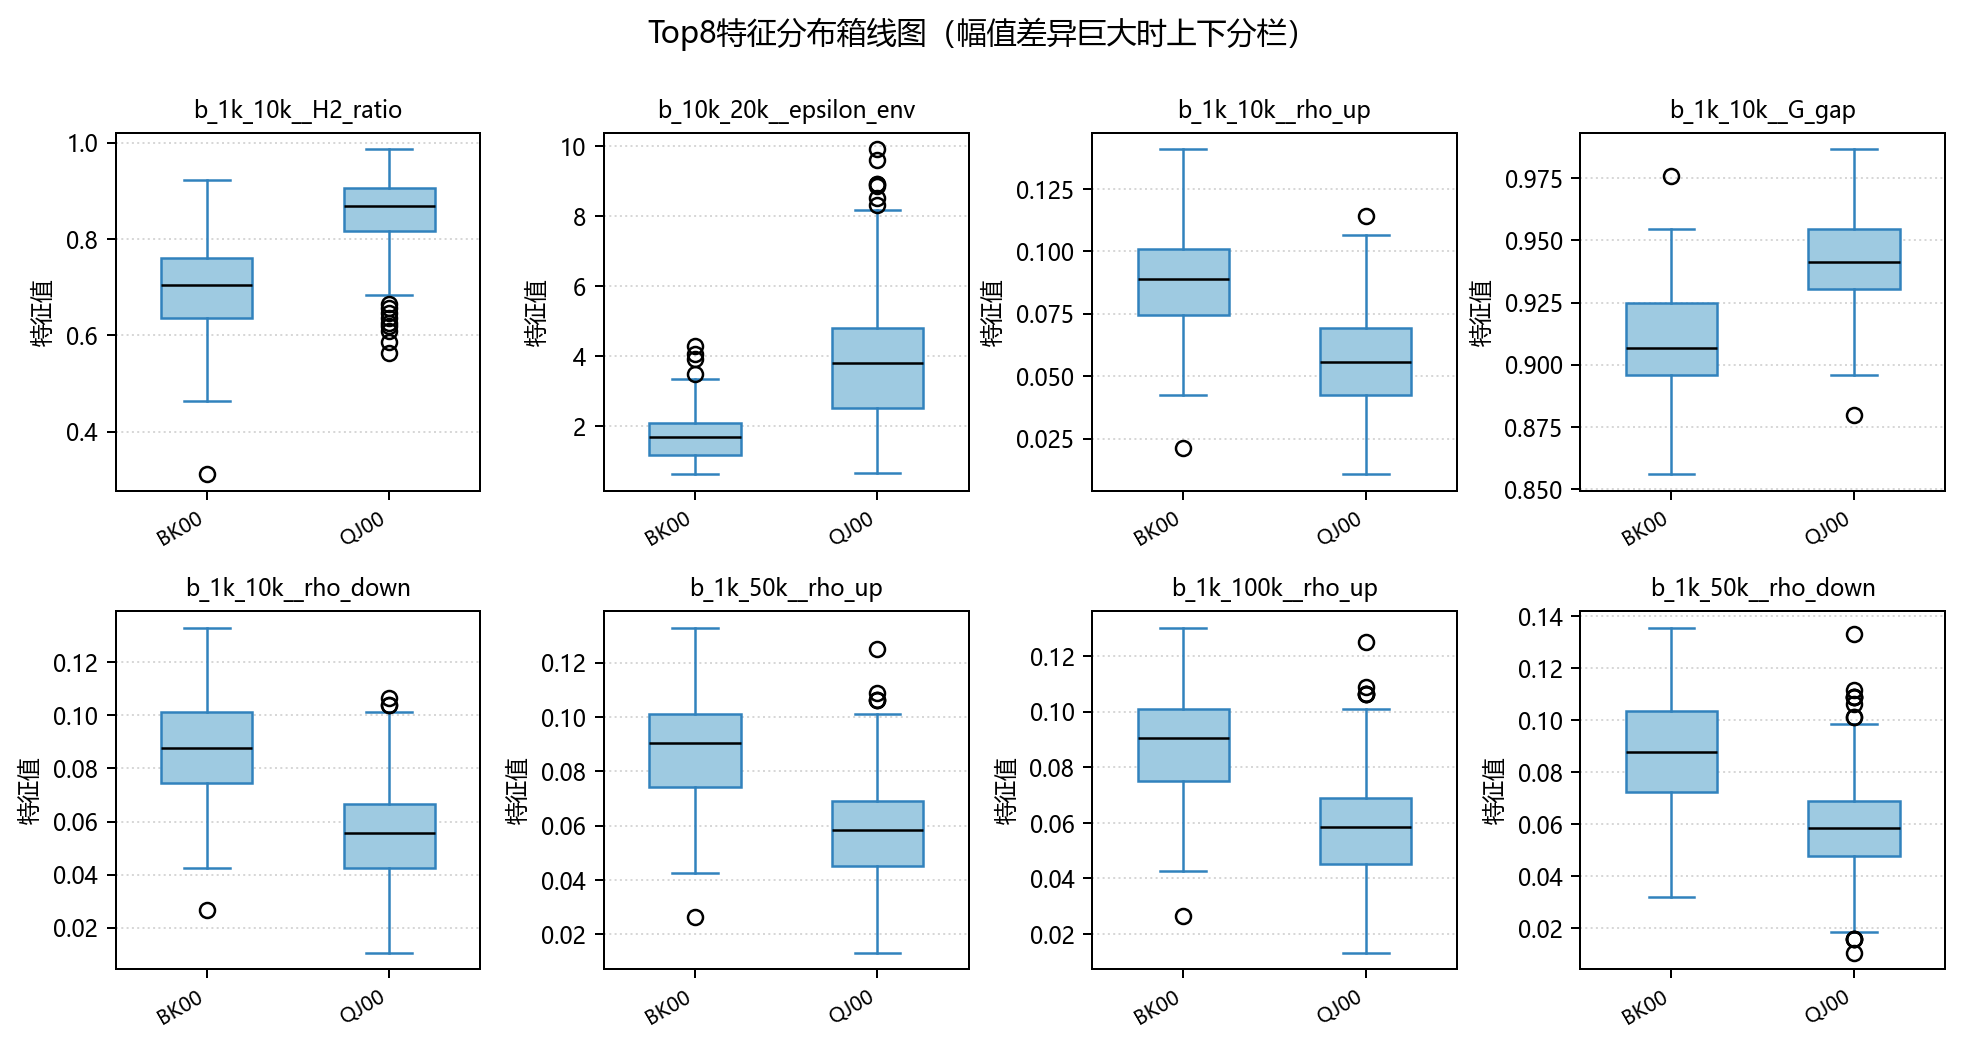

**图 8 2.3 BK00 vs QJ00 KDE分布图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图08_2.3_BK00_vs_QJ00_KDE分布图.png`</sub>

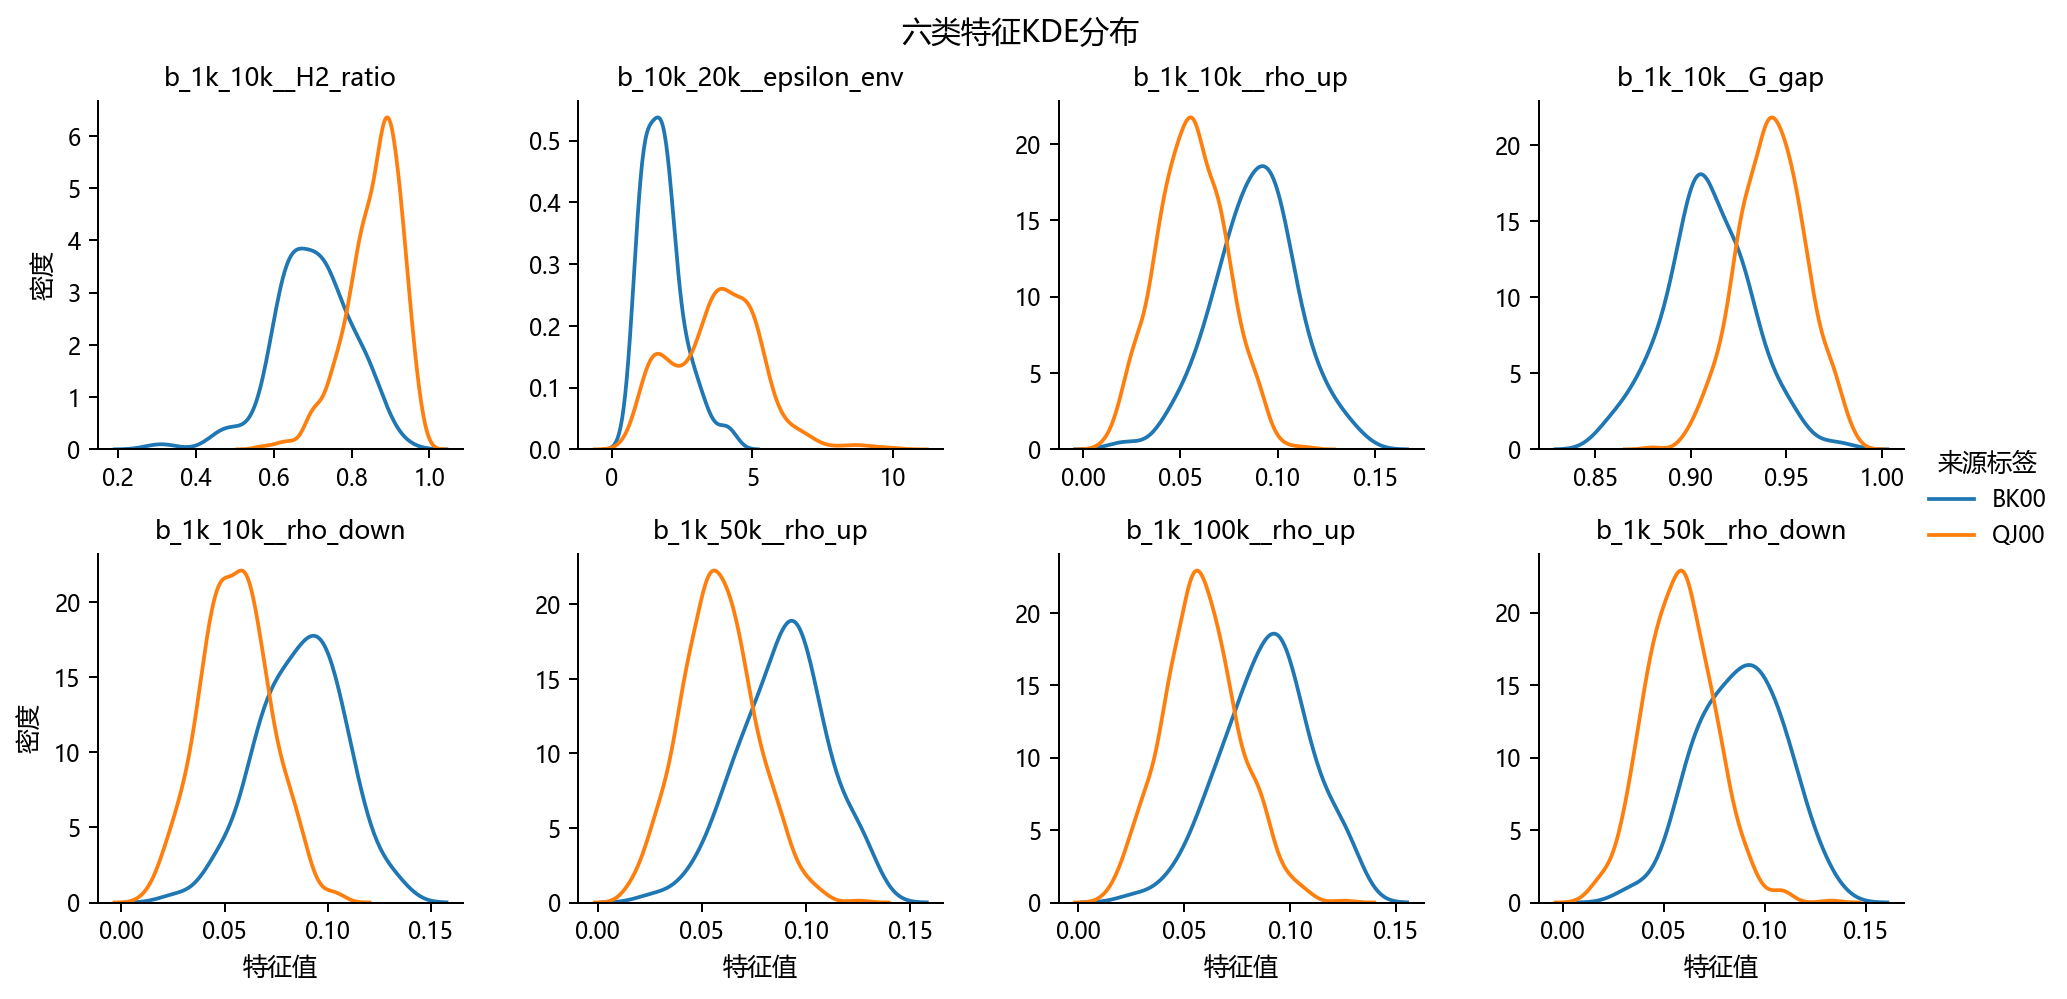

**图 9 2.3 BK00 vs QJ00 PCA投影图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图09_2.3_BK00_vs_QJ00_PCA投影图.png`</sub>

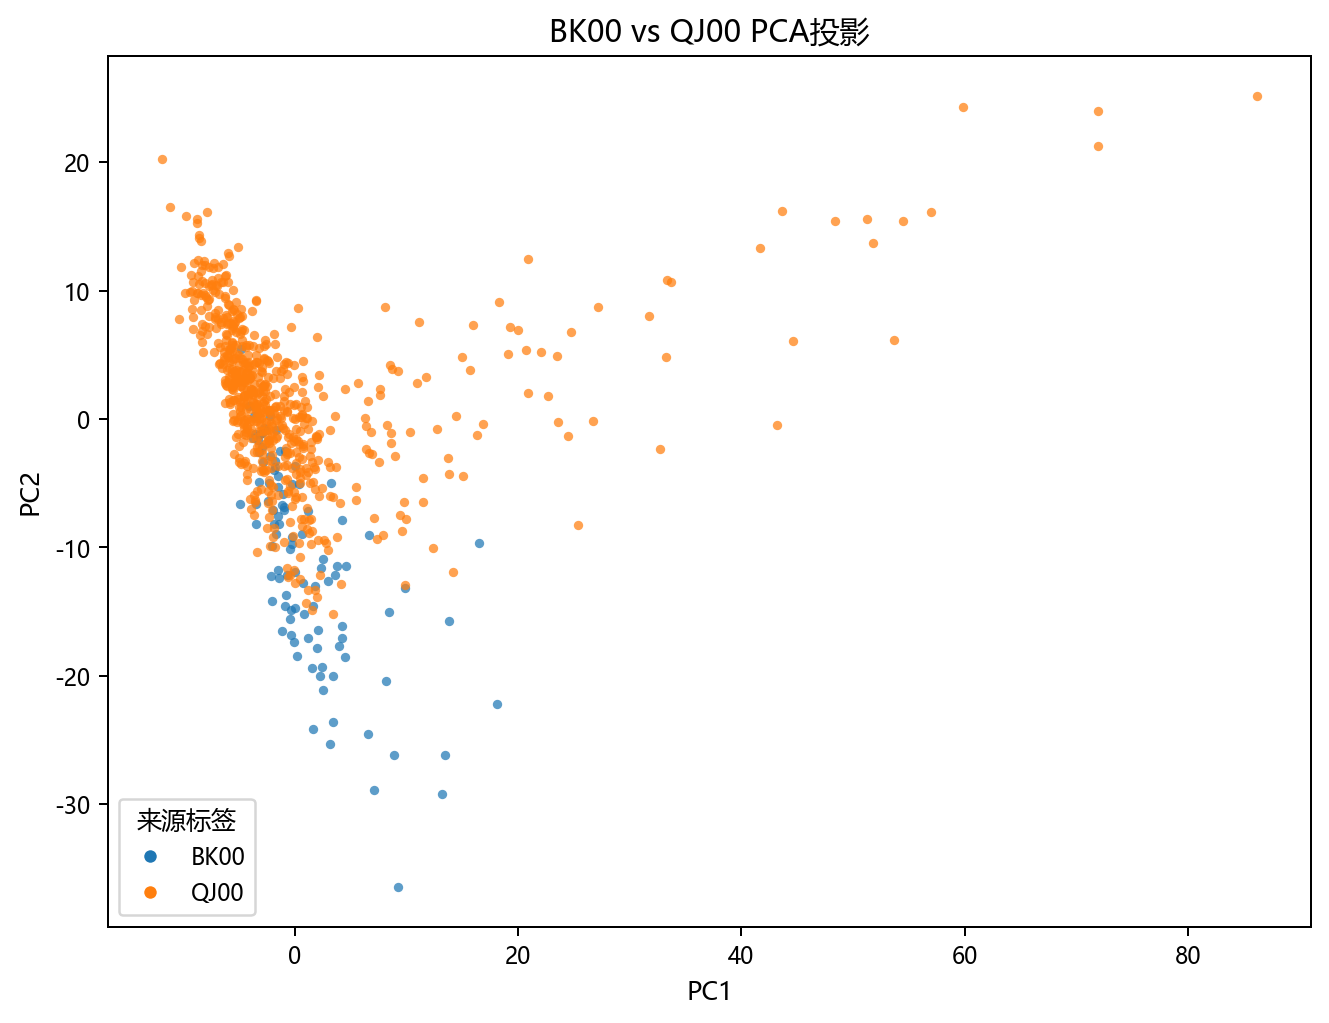

In [11]:
# 2.3 BK00 vs QJ00
df_bk00_qj00 = df[df['source_label'].isin(['BK00', 'QJ00'])].copy()

bk00_qj00_f_ratio = compute_two_class_f_ratio(df_bk00_qj00, feature_cols, class_a='BK00', class_b='QJ00')
bk00_qj00_distribution_metrics = attach_kde_metrics_to_ranking(df_bk00_qj00, bk00_qj00_f_ratio, 'source_label', top_n=8)
top_features_2_3 = bk00_qj00_distribution_metrics['feature'].tolist()

boxplot_path_2_3 = RUN_DIR / 'plots/bk00_vs_qj00_boxplots.png'
# ---- 内联箱线图：幅值差异巨大的特征改用断裂坐标轴（截断轴）；代码内联，便于调整 ----
import numpy as np
import matplotlib.pyplot as plt
from pccp_feature_mining.feature_schema import impute_with_median, numeric_feature_frame
from pccp_feature_mining.visualization import _configure_font

_configure_font()
_box_break_ratio = 50.0    # 最大/最小类中位数比值超过该值 => 幅值差异巨大，改用断裂坐标轴
_box_split_factor = 10.0   # 中位数高于几何均值的该倍数视为高幅值类（进入顶部小面板）
_box_fliers = True         # 底部主体面板是否显示离群点（四分位/须线/离群点默认全部可见）
_box_feats = top_features_2_3[:8]
_box_df = df_bk00_qj00
_box_label = 'source_label'
_box_ncols = 4
_box_path = boxplot_path_2_3

_box_x = impute_with_median(numeric_feature_frame(_box_df, _box_feats))
_box_p = pd.concat([_box_df[_box_label].reset_index(drop=True).to_frame(), _box_x.reset_index(drop=True)], axis=1)
_box_classes = sorted(str(_c) for _c in _box_p[_box_label].astype(str).unique())
_box_rows = -(-len(_box_feats) // _box_ncols)
_box_fig, _box_axes = plt.subplots(_box_rows, _box_ncols, figsize=(11.0, 2.9 * _box_rows), squeeze=False)
_box_fig.suptitle('Top8特征分布箱线图（幅值差异巨大时上下分栏）', y=0.995, fontsize=12)
_box_bp_kw = dict(widths=0.5, patch_artist=True,
                  medianprops=dict(color='black', lw=1.0),
                  boxprops=dict(facecolor='#9ecae1', edgecolor='#3182bd'),
                  whiskerprops=dict(color='#3182bd'), capprops=dict(color='#3182bd'))
_box_bk_kw = dict(marker=[(-1, -0.5), (1, 0.5)], markersize=12, linestyle='none', color='k', mec='k', mew=1, clip_on=False)

for _i, _feat in enumerate(_box_feats):
    _g = _box_axes[_i // _box_ncols][_i % _box_ncols]
    _cols_data = []
    _meds = []
    for _c in _box_classes:
        _v = np.asarray(_box_p.loc[_box_p[_box_label].astype(str) == _c, _feat].dropna(), dtype=float)
        if _v.size == 0:
            continue
        _cols_data.append((_c, _v))
        _meds.append(float(np.median(_v)))
    if not _cols_data:
        _g.axis('off')
        continue
    _med_abs = np.abs(np.array(_meds))
    _use_break = bool(_med_abs.size >= 2 and _med_abs.min() > 0 and _med_abs.max() / _med_abs.min() >= _box_break_ratio)
    _top = []
    _bot = []
    if _use_break:
        _gm = np.sqrt(_med_abs.max() * _med_abs.min())
        _top = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) > _box_split_factor * _gm]
        _bot = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) <= _box_split_factor * _gm]
        if not _top or not _bot:
            _use_break = False
    if not _use_break:
        _g.boxplot([_v for _, _v in _cols_data], positions=np.arange(len(_cols_data)), showfliers=_box_fliers, **_box_bp_kw)
        _g.set_title(_feat, fontsize=9)
        _g.set_xticks(np.arange(len(_cols_data)))
        _g.set_xticklabels([_c for _c, _ in _cols_data], rotation=30, ha='right', fontsize=8)
        _g.set_ylabel('特征值', fontsize=9)
        _g.grid(axis='y', ls=':', alpha=0.5)
        continue
    _gs = _g.get_subplotspec().subgridspec(2, 1, height_ratios=[1, 3], hspace=0.10)
    _g.axis('off')
    _a_top = _box_fig.add_subplot(_gs[0])
    _a_bot = _box_fig.add_subplot(_gs[1])
    _a_top.boxplot([_v for _, _v in _top], positions=np.arange(len(_top)), showfliers=False, **_box_bp_kw)
    _a_bot.boxplot([_v for _, _v in _bot], positions=np.arange(len(_bot)), showfliers=_box_fliers, **_box_bp_kw)
    _a_top.set_title(_feat, fontsize=9)
    _a_bot.set_ylabel('特征值', fontsize=9)
    _ymin_t = min(float(np.min(_v)) for _, _v in _top)
    _ymax_t = max(float(np.max(_v)) for _, _v in _top)
    _a_top.set_ylim(_ymin_t - 0.05 * (_ymax_t - _ymin_t + 1e-12), _ymax_t + 0.05 * (_ymax_t - _ymin_t + 1e-12))
    _ymin_b = min(float(np.min(_v)) for _, _v in _bot)
    _ymax_b = max(float(np.max(_v)) for _, _v in _bot)
    _a_bot.set_ylim(_ymin_b - 0.08 * (_ymax_b - _ymin_b + 1e-12), _ymax_b + 0.08 * (_ymax_b - _ymin_b + 1e-12))
    _a_top.set_xticks(np.arange(len(_top)))
    _a_top.set_xticklabels([_c for _c, _ in _top], fontsize=7)
    _a_bot.set_xticks(np.arange(len(_bot)))
    _a_bot.set_xticklabels([_c for _c, _ in _bot], rotation=30, ha='right', fontsize=8)
    for _sp in ('top', 'right'):
        _a_top.spines[_sp].set_visible(False)
        _a_bot.spines[_sp].set_visible(False)
    _a_top.plot([0, 1], [0, 0], transform=_a_top.transAxes, **_box_bk_kw)
    _a_bot.plot([0, 1], [0, 1], transform=_a_bot.transAxes, **_box_bk_kw)

_box_fig.tight_layout()
_box_fig.savefig(_box_path, dpi=180, bbox_inches='tight')
plt.close(_box_fig)

kde_path_2_3 = RUN_DIR / 'plots/bk00_vs_qj00_kde.png'
plot_feature_kde_by_label(df_bk00_qj00, top_features_2_3[:8], kde_path_2_3, col_wrap=4)

pca_projection_2_3, pca_explained_2_3 = run_pca_projection(df_bk00_qj00, feature_cols, max_rows=CONFIG.projection_max_rows, random_state=CONFIG.random_state)
pca_path_2_3 = RUN_DIR / 'plots/bk00_vs_qj00_pca.png'
plot_projection(pca_projection_2_3, 'PC1', 'PC2', pca_path_2_3, 'BK00 vs QJ00 PCA投影')

show_table('2.3 BK00 vs QJ00 F-ratio与KDE分布差异指标', bk00_qj00_distribution_metrics, rows=10)
show_image('2.3 BK00 vs QJ00 箱线图', boxplot_path_2_3)
show_image('2.3 BK00 vs QJ00 KDE分布图', kde_path_2_3)
show_image('2.3 BK00 vs QJ00 PCA投影图', pca_path_2_3)

### 2.4 BK05 vs QJ05

半流速下，断丝信号（BK05）与敲击信号（QJ05）的特征分布差异。

**表 10 2.4 BK05 vs QJ05 F-ratio与KDE分布差异指标**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表10_2.4_BK05_vs_QJ05_F-ratio与KDE分布差异指标.csv`</sub>

,feature,f_ratio,between_var,within_var,kde_pair_count,kde_overlap_mean,kde_overlap_min,kde_overlap_max,kde_separation_mean,kde_separation_max,特征中文含义
4,b_1k_100k__R_tkeo,0.623,124.861,200.323,1,0.395,0.395,0.395,0.605,0.605,1-100 kHz频带，原信号TKEO峰值比，TKEO输出峰值与均值的比值，描述冲击瞬态尖锐程度
1,b_10k_20k__epsilon_env,0.755,0.975,1.291,1,0.417,0.417,0.417,0.583,0.583,10-20 kHz频带，包络拟合残差，描述包络形状偏离基准模型的程度
2,b_10k_50k__K_res_max,0.704,1.058,1.503,1,0.419,0.419,0.419,0.581,0.581,10-50 kHz频带，残差局部峭度最大值，滑动窗内残差峭度的最大值，描述残差中最强的局部重尾冲击
0,b_10k_50k__R_hl_mean,0.799,0.034,0.043,1,0.425,0.425,0.425,0.575,0.575,10-50 kHz频带，高低频能量比均值，描述高频能量相对低频能量的平均占比
3,b_10k_20k__CF_res,0.633,2.881,4.553,1,0.456,0.456,0.456,0.544,0.544,10-20 kHz频带，残差峰值因子，残差峰值与RMS之比，描述残差冲击峰值相对能量水平的突出程度
5,b_10k_20k__Sk_env,0.588,1.448,2.464,1,0.480,0.480,0.480,0.520,0.520,10-20 kHz频带，包络偏度，描述包络幅值分布的不对称性
6,b_10k_50k__epsilon_env,0.509,0.546,1.072,1,0.494,0.494,0.494,0.506,0.506,10-50 kHz频带，包络拟合残差，描述包络形状偏离基准模型的程度
7,b_10k_20k__alpha_hat,0.497,481.782,968.408,1,0.550,0.550,0.550,0.450,0.450,10-20 kHz频带，估计阻尼系数，描述衰减速度


**图 10 2.4 BK05 vs QJ05 箱线图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图10_2.4_BK05_vs_QJ05_箱线图.png`</sub>

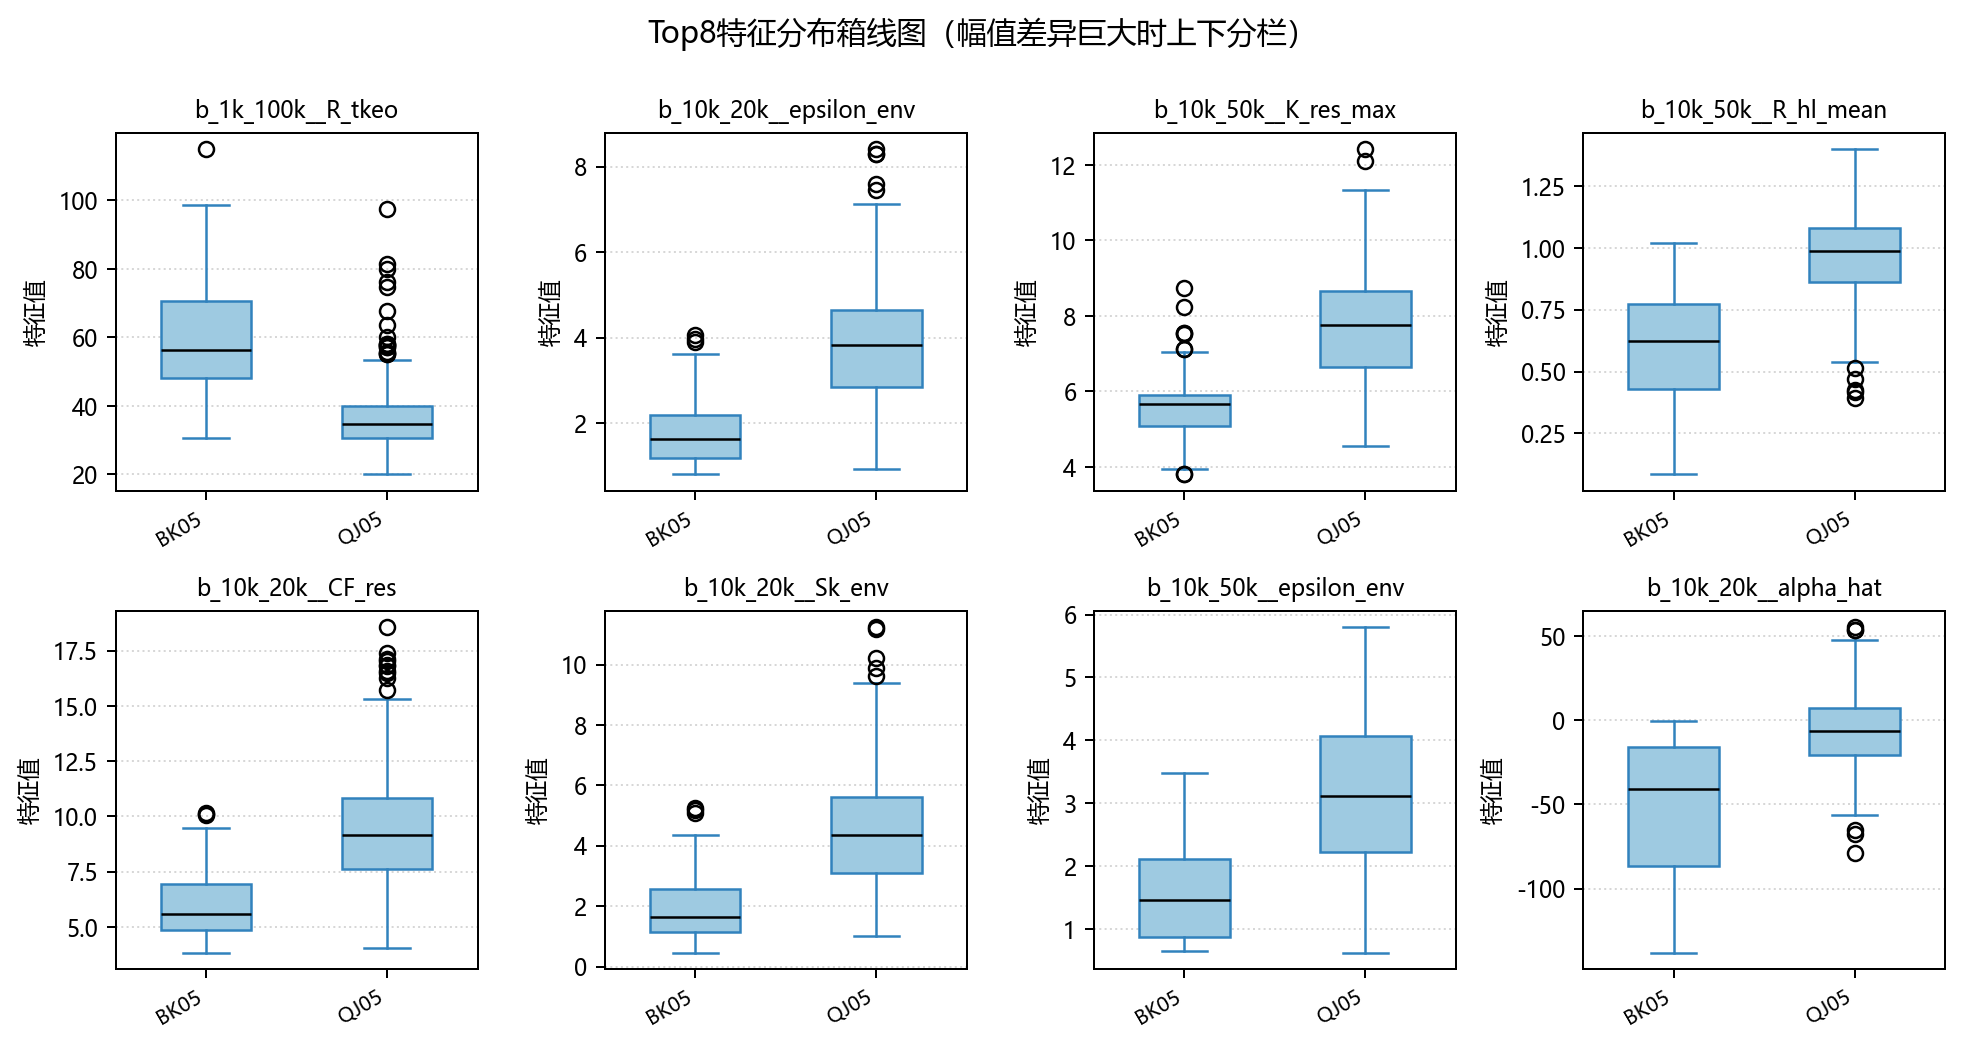

**图 11 2.4 BK05 vs QJ05 KDE分布图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图11_2.4_BK05_vs_QJ05_KDE分布图.png`</sub>

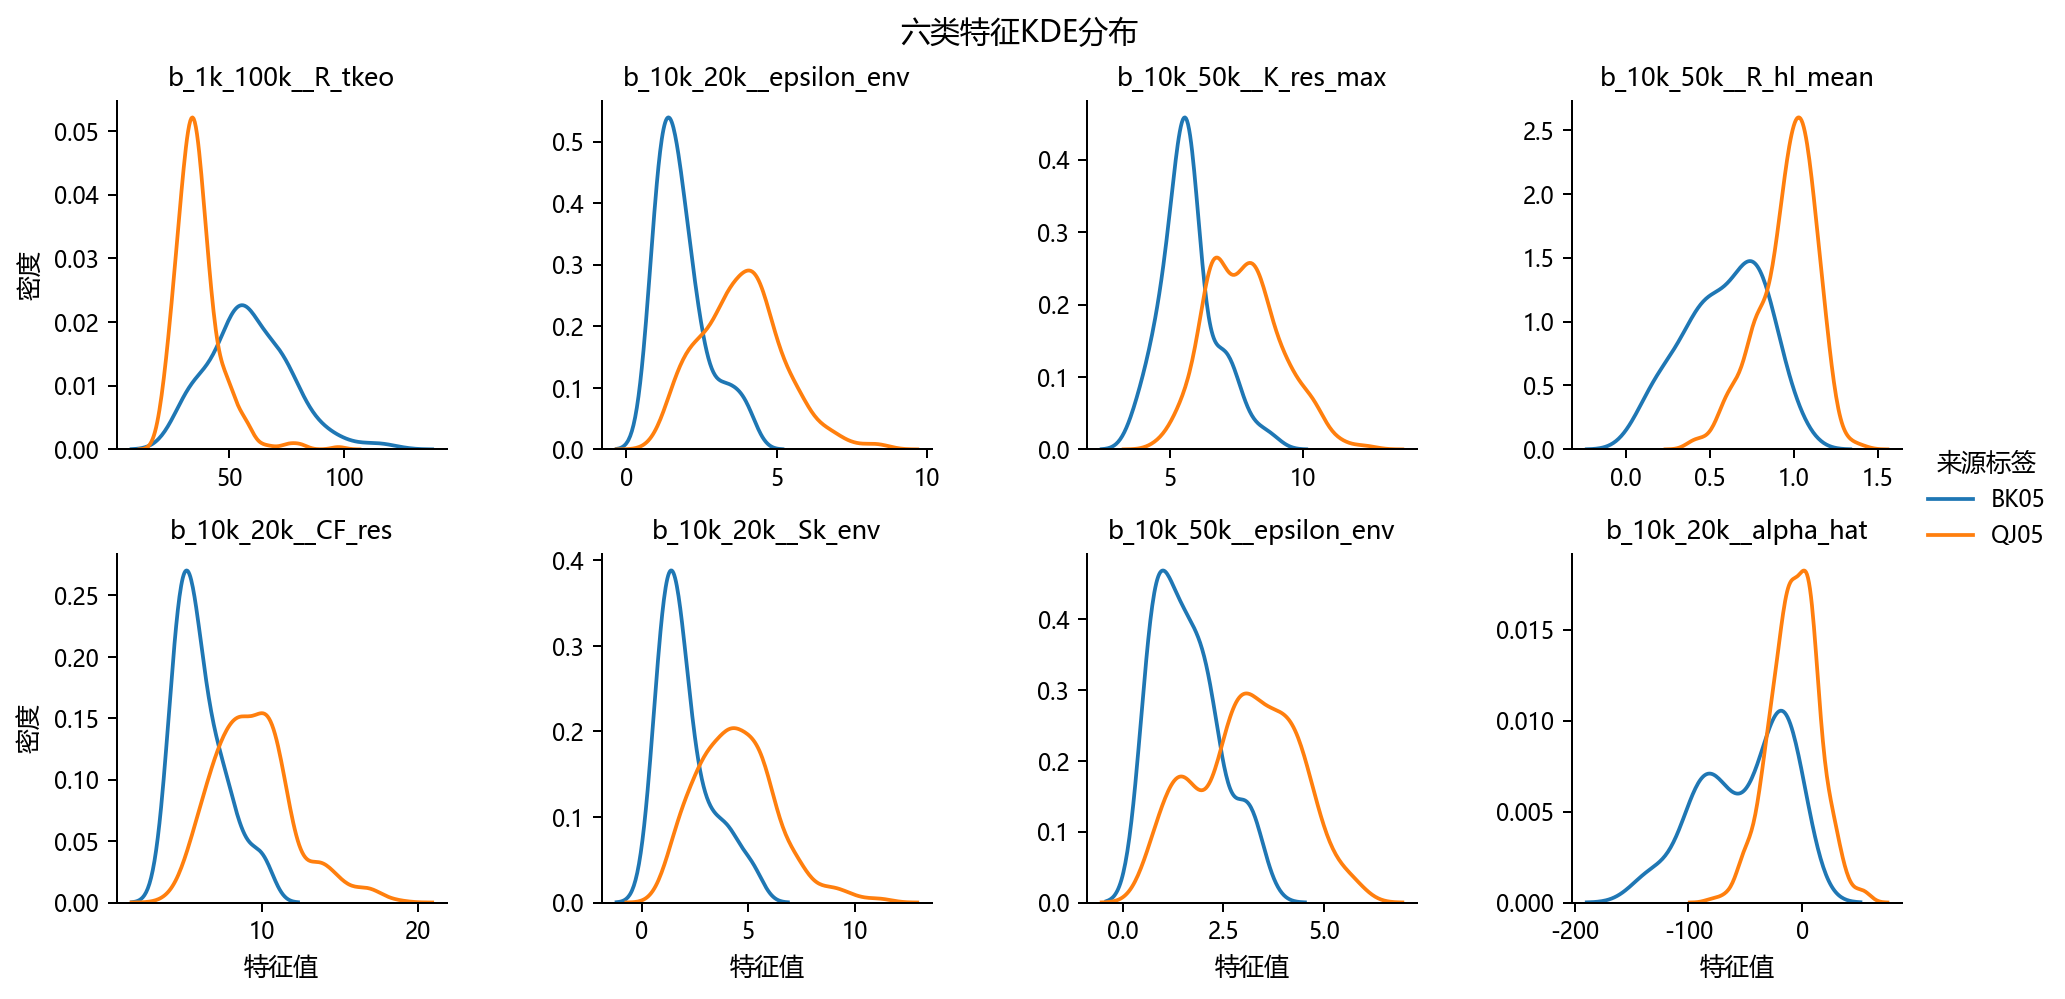

**图 12 2.4 BK05 vs QJ05 PCA投影图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图12_2.4_BK05_vs_QJ05_PCA投影图.png`</sub>

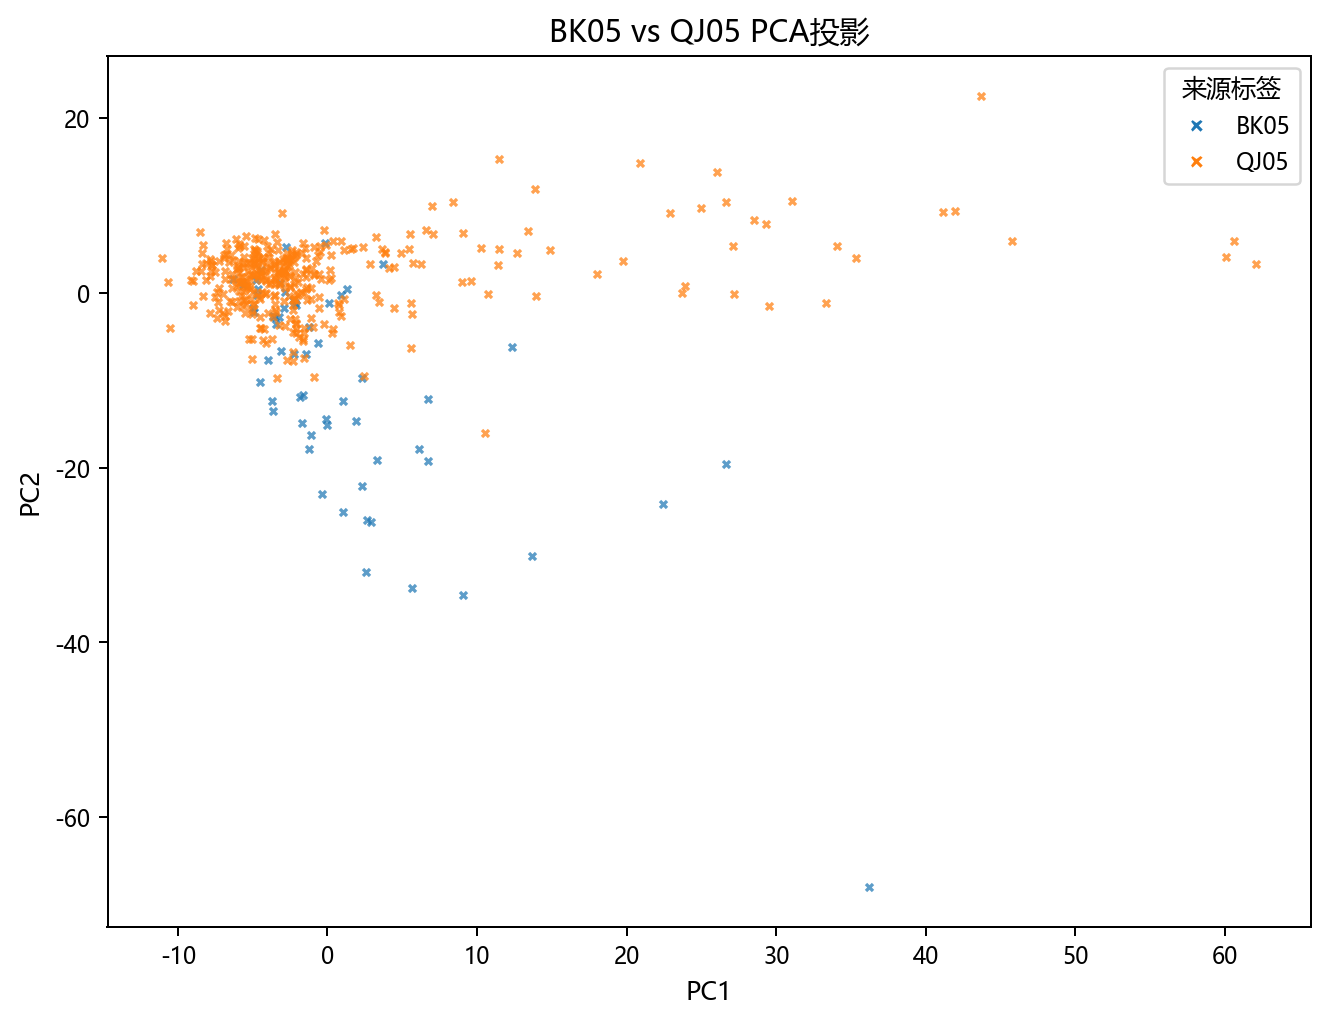

In [12]:
# 2.4 BK05 vs QJ05
df_bk05_qj05 = df[df['source_label'].isin(['BK05', 'QJ05'])].copy()

bk05_qj05_f_ratio = compute_two_class_f_ratio(df_bk05_qj05, feature_cols, class_a='BK05', class_b='QJ05')
bk05_qj05_distribution_metrics = attach_kde_metrics_to_ranking(df_bk05_qj05, bk05_qj05_f_ratio, 'source_label', top_n=8)
top_features_2_4 = bk05_qj05_distribution_metrics['feature'].tolist()

boxplot_path_2_4 = RUN_DIR / 'plots/bk05_vs_qj05_boxplots.png'
# ---- 内联箱线图：幅值差异巨大的特征改用断裂坐标轴（截断轴）；代码内联，便于调整 ----
import numpy as np
import matplotlib.pyplot as plt
from pccp_feature_mining.feature_schema import impute_with_median, numeric_feature_frame
from pccp_feature_mining.visualization import _configure_font

_configure_font()
_box_break_ratio = 50.0    # 最大/最小类中位数比值超过该值 => 幅值差异巨大，改用断裂坐标轴
_box_split_factor = 10.0   # 中位数高于几何均值的该倍数视为高幅值类（进入顶部小面板）
_box_fliers = True         # 底部主体面板是否显示离群点（四分位/须线/离群点默认全部可见）
_box_feats = top_features_2_4[:8]
_box_df = df_bk05_qj05
_box_label = 'source_label'
_box_ncols = 4
_box_path = boxplot_path_2_4

_box_x = impute_with_median(numeric_feature_frame(_box_df, _box_feats))
_box_p = pd.concat([_box_df[_box_label].reset_index(drop=True).to_frame(), _box_x.reset_index(drop=True)], axis=1)
_box_classes = sorted(str(_c) for _c in _box_p[_box_label].astype(str).unique())
_box_rows = -(-len(_box_feats) // _box_ncols)
_box_fig, _box_axes = plt.subplots(_box_rows, _box_ncols, figsize=(11.0, 2.9 * _box_rows), squeeze=False)
_box_fig.suptitle('Top8特征分布箱线图（幅值差异巨大时上下分栏）', y=0.995, fontsize=12)
_box_bp_kw = dict(widths=0.5, patch_artist=True,
                  medianprops=dict(color='black', lw=1.0),
                  boxprops=dict(facecolor='#9ecae1', edgecolor='#3182bd'),
                  whiskerprops=dict(color='#3182bd'), capprops=dict(color='#3182bd'))
_box_bk_kw = dict(marker=[(-1, -0.5), (1, 0.5)], markersize=12, linestyle='none', color='k', mec='k', mew=1, clip_on=False)

for _i, _feat in enumerate(_box_feats):
    _g = _box_axes[_i // _box_ncols][_i % _box_ncols]
    _cols_data = []
    _meds = []
    for _c in _box_classes:
        _v = np.asarray(_box_p.loc[_box_p[_box_label].astype(str) == _c, _feat].dropna(), dtype=float)
        if _v.size == 0:
            continue
        _cols_data.append((_c, _v))
        _meds.append(float(np.median(_v)))
    if not _cols_data:
        _g.axis('off')
        continue
    _med_abs = np.abs(np.array(_meds))
    _use_break = bool(_med_abs.size >= 2 and _med_abs.min() > 0 and _med_abs.max() / _med_abs.min() >= _box_break_ratio)
    _top = []
    _bot = []
    if _use_break:
        _gm = np.sqrt(_med_abs.max() * _med_abs.min())
        _top = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) > _box_split_factor * _gm]
        _bot = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) <= _box_split_factor * _gm]
        if not _top or not _bot:
            _use_break = False
    if not _use_break:
        _g.boxplot([_v for _, _v in _cols_data], positions=np.arange(len(_cols_data)), showfliers=_box_fliers, **_box_bp_kw)
        _g.set_title(_feat, fontsize=9)
        _g.set_xticks(np.arange(len(_cols_data)))
        _g.set_xticklabels([_c for _c, _ in _cols_data], rotation=30, ha='right', fontsize=8)
        _g.set_ylabel('特征值', fontsize=9)
        _g.grid(axis='y', ls=':', alpha=0.5)
        continue
    _gs = _g.get_subplotspec().subgridspec(2, 1, height_ratios=[1, 3], hspace=0.10)
    _g.axis('off')
    _a_top = _box_fig.add_subplot(_gs[0])
    _a_bot = _box_fig.add_subplot(_gs[1])
    _a_top.boxplot([_v for _, _v in _top], positions=np.arange(len(_top)), showfliers=False, **_box_bp_kw)
    _a_bot.boxplot([_v for _, _v in _bot], positions=np.arange(len(_bot)), showfliers=_box_fliers, **_box_bp_kw)
    _a_top.set_title(_feat, fontsize=9)
    _a_bot.set_ylabel('特征值', fontsize=9)
    _ymin_t = min(float(np.min(_v)) for _, _v in _top)
    _ymax_t = max(float(np.max(_v)) for _, _v in _top)
    _a_top.set_ylim(_ymin_t - 0.05 * (_ymax_t - _ymin_t + 1e-12), _ymax_t + 0.05 * (_ymax_t - _ymin_t + 1e-12))
    _ymin_b = min(float(np.min(_v)) for _, _v in _bot)
    _ymax_b = max(float(np.max(_v)) for _, _v in _bot)
    _a_bot.set_ylim(_ymin_b - 0.08 * (_ymax_b - _ymin_b + 1e-12), _ymax_b + 0.08 * (_ymax_b - _ymin_b + 1e-12))
    _a_top.set_xticks(np.arange(len(_top)))
    _a_top.set_xticklabels([_c for _c, _ in _top], fontsize=7)
    _a_bot.set_xticks(np.arange(len(_bot)))
    _a_bot.set_xticklabels([_c for _c, _ in _bot], rotation=30, ha='right', fontsize=8)
    for _sp in ('top', 'right'):
        _a_top.spines[_sp].set_visible(False)
        _a_bot.spines[_sp].set_visible(False)
    _a_top.plot([0, 1], [0, 0], transform=_a_top.transAxes, **_box_bk_kw)
    _a_bot.plot([0, 1], [0, 1], transform=_a_bot.transAxes, **_box_bk_kw)

_box_fig.tight_layout()
_box_fig.savefig(_box_path, dpi=180, bbox_inches='tight')
plt.close(_box_fig)

kde_path_2_4 = RUN_DIR / 'plots/bk05_vs_qj05_kde.png'
plot_feature_kde_by_label(df_bk05_qj05, top_features_2_4[:8], kde_path_2_4, col_wrap=4)

pca_projection_2_4, pca_explained_2_4 = run_pca_projection(df_bk05_qj05, feature_cols, max_rows=CONFIG.projection_max_rows, random_state=CONFIG.random_state)
pca_path_2_4 = RUN_DIR / 'plots/bk05_vs_qj05_pca.png'
plot_projection(pca_projection_2_4, 'PC1', 'PC2', pca_path_2_4, 'BK05 vs QJ05 PCA投影')

show_table('2.4 BK05 vs QJ05 F-ratio与KDE分布差异指标', bk05_qj05_distribution_metrics, rows=10)
show_image('2.4 BK05 vs QJ05 箱线图', boxplot_path_2_4)
show_image('2.4 BK05 vs QJ05 KDE分布图', kde_path_2_4)
show_image('2.4 BK05 vs QJ05 PCA投影图', pca_path_2_4)

### 2.5 (BK00+BK05) vs (QJ00+QJ05)

断丝信号集合（BK00+BK05）与敲击信号集合（QJ00+QJ05）的特征分布差异。

**表 11 2.5 (BK00+BK05) vs (QJ00+QJ05) F-ratio与KDE分布差异指标**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表11_2.5_(BK00+BK05)_vs_(QJ00+QJ05)_F-ratio与KDE分布差异指标.csv`</sub>

,feature,f_ratio,between_var,within_var,kde_pair_count,kde_overlap_mean,kde_overlap_min,kde_overlap_max,kde_separation_mean,kde_separation_max,特征中文含义
0,b_10k_20k__epsilon_env,0.662,0.942,1.423,1,0.402,0.402,0.402,0.598,0.598,10-20 kHz频带，包络拟合残差，描述包络形状偏离基准模型的程度
3,b_10k_50k__K_res_max,0.572,1.259,2.202,1,0.417,0.417,0.417,0.583,0.583,10-50 kHz频带，残差局部峭度最大值，滑动窗内残差峭度的最大值，描述残差中最强的局部重尾冲击
1,b_10k_20k__CF_res,0.600,3.301,5.505,1,0.427,0.427,0.427,0.573,0.573,10-20 kHz频带，残差峰值因子，残差峰值与RMS之比，描述残差冲击峰值相对能量水平的突出程度
5,b_10k_50k__epsilon_env,0.521,0.607,1.163,1,0.449,0.449,0.449,0.551,0.551,10-50 kHz频带，包络拟合残差，描述包络形状偏离基准模型的程度
4,b_10k_20k__Sk_env,0.541,1.363,2.521,1,0.452,0.452,0.452,0.548,0.548,10-20 kHz频带，包络偏度，描述包络幅值分布的不对称性
2,b_10k_50k__R_hl_mean,0.595,0.035,0.059,1,0.492,0.492,0.492,0.508,0.508,10-50 kHz频带，高低频能量比均值，描述高频能量相对低频能量的平均占比
6,b_10k_20k__alpha_hat,0.494,517.780,1048.513,1,0.542,0.542,0.542,0.458,0.458,10-20 kHz频带，估计阻尼系数，描述衰减速度
7,b_10k_50k__alpha_hat,0.465,443.215,953.131,1,0.553,0.553,0.553,0.447,0.447,10-50 kHz频带，估计阻尼系数，描述衰减速度


**图 13 2.5 (BK00+BK05) vs (QJ00+QJ05) 箱线图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图13_2.5_(BK00+BK05)_vs_(QJ00+QJ05)_箱线图.png`</sub>

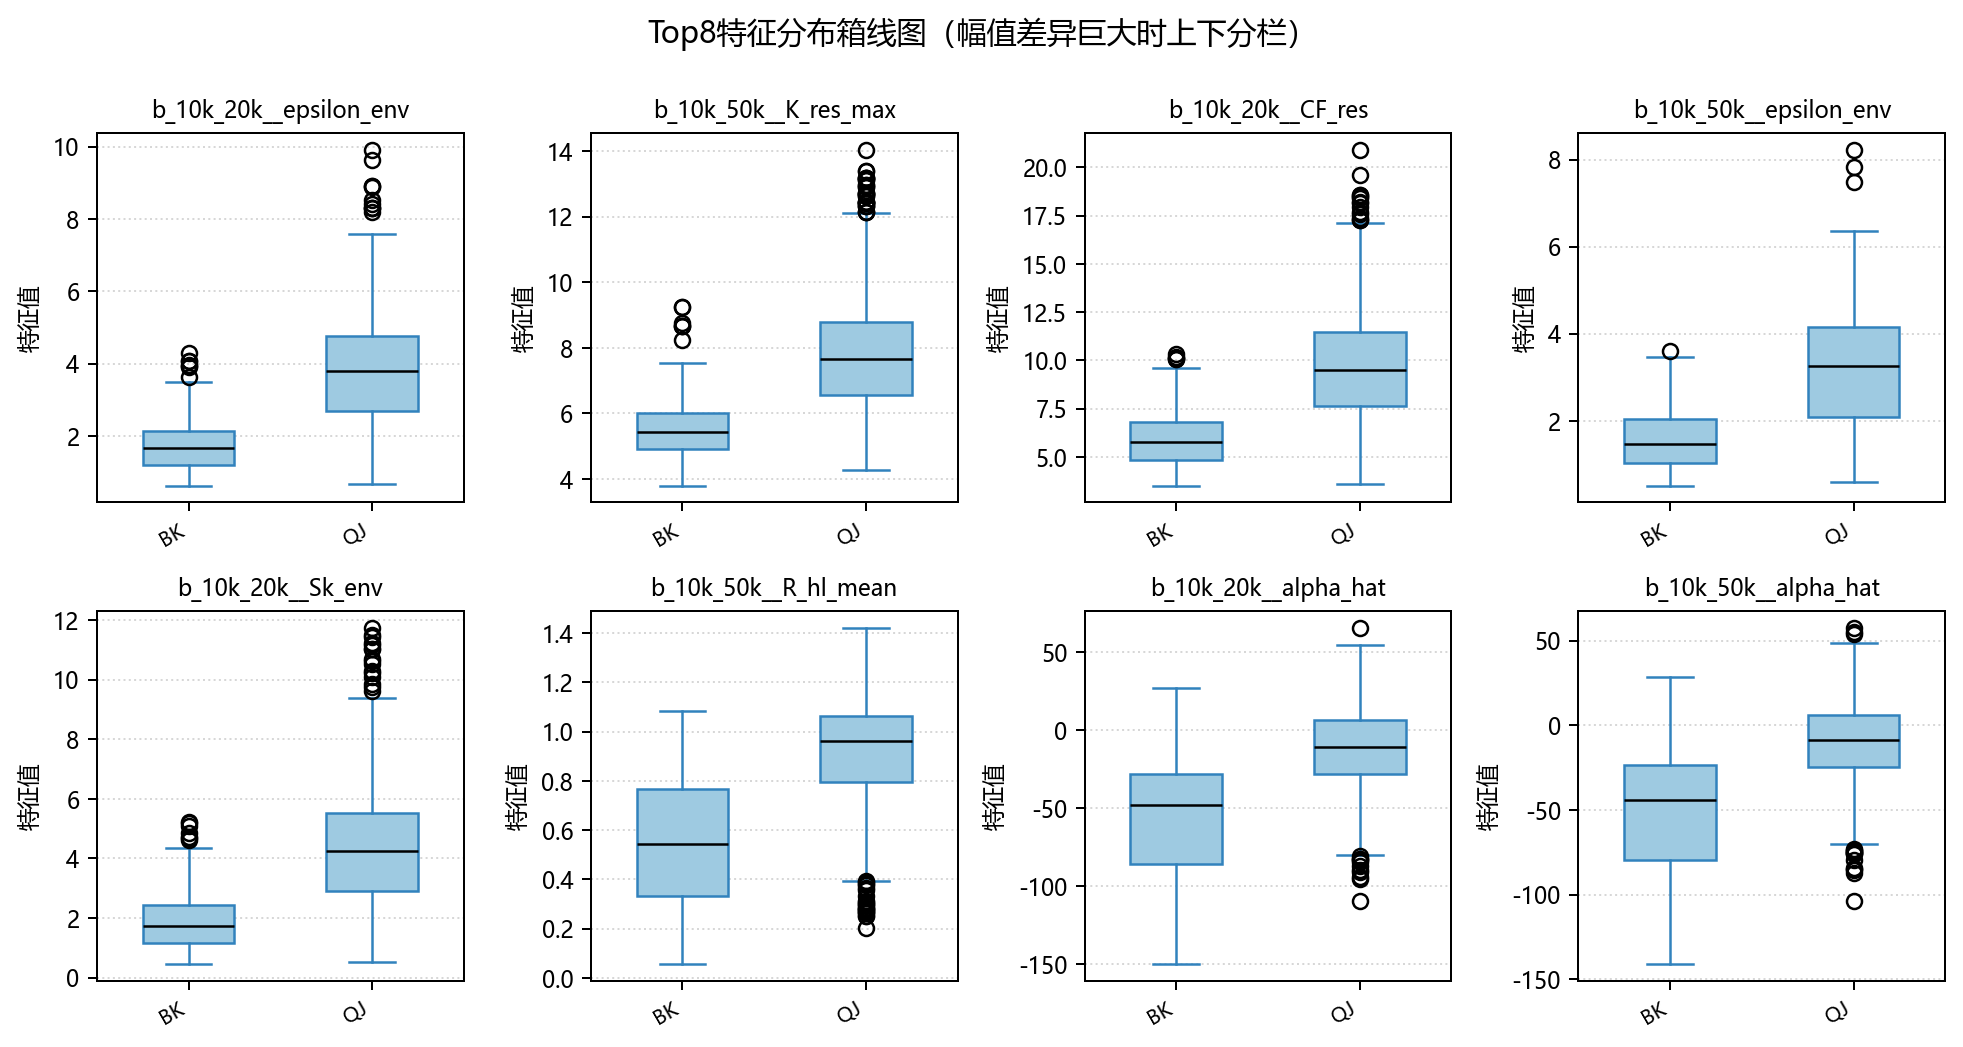

**图 14 2.5 (BK00+BK05) vs (QJ00+QJ05) KDE分布图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图14_2.5_(BK00+BK05)_vs_(QJ00+QJ05)_KDE分布图.png`</sub>

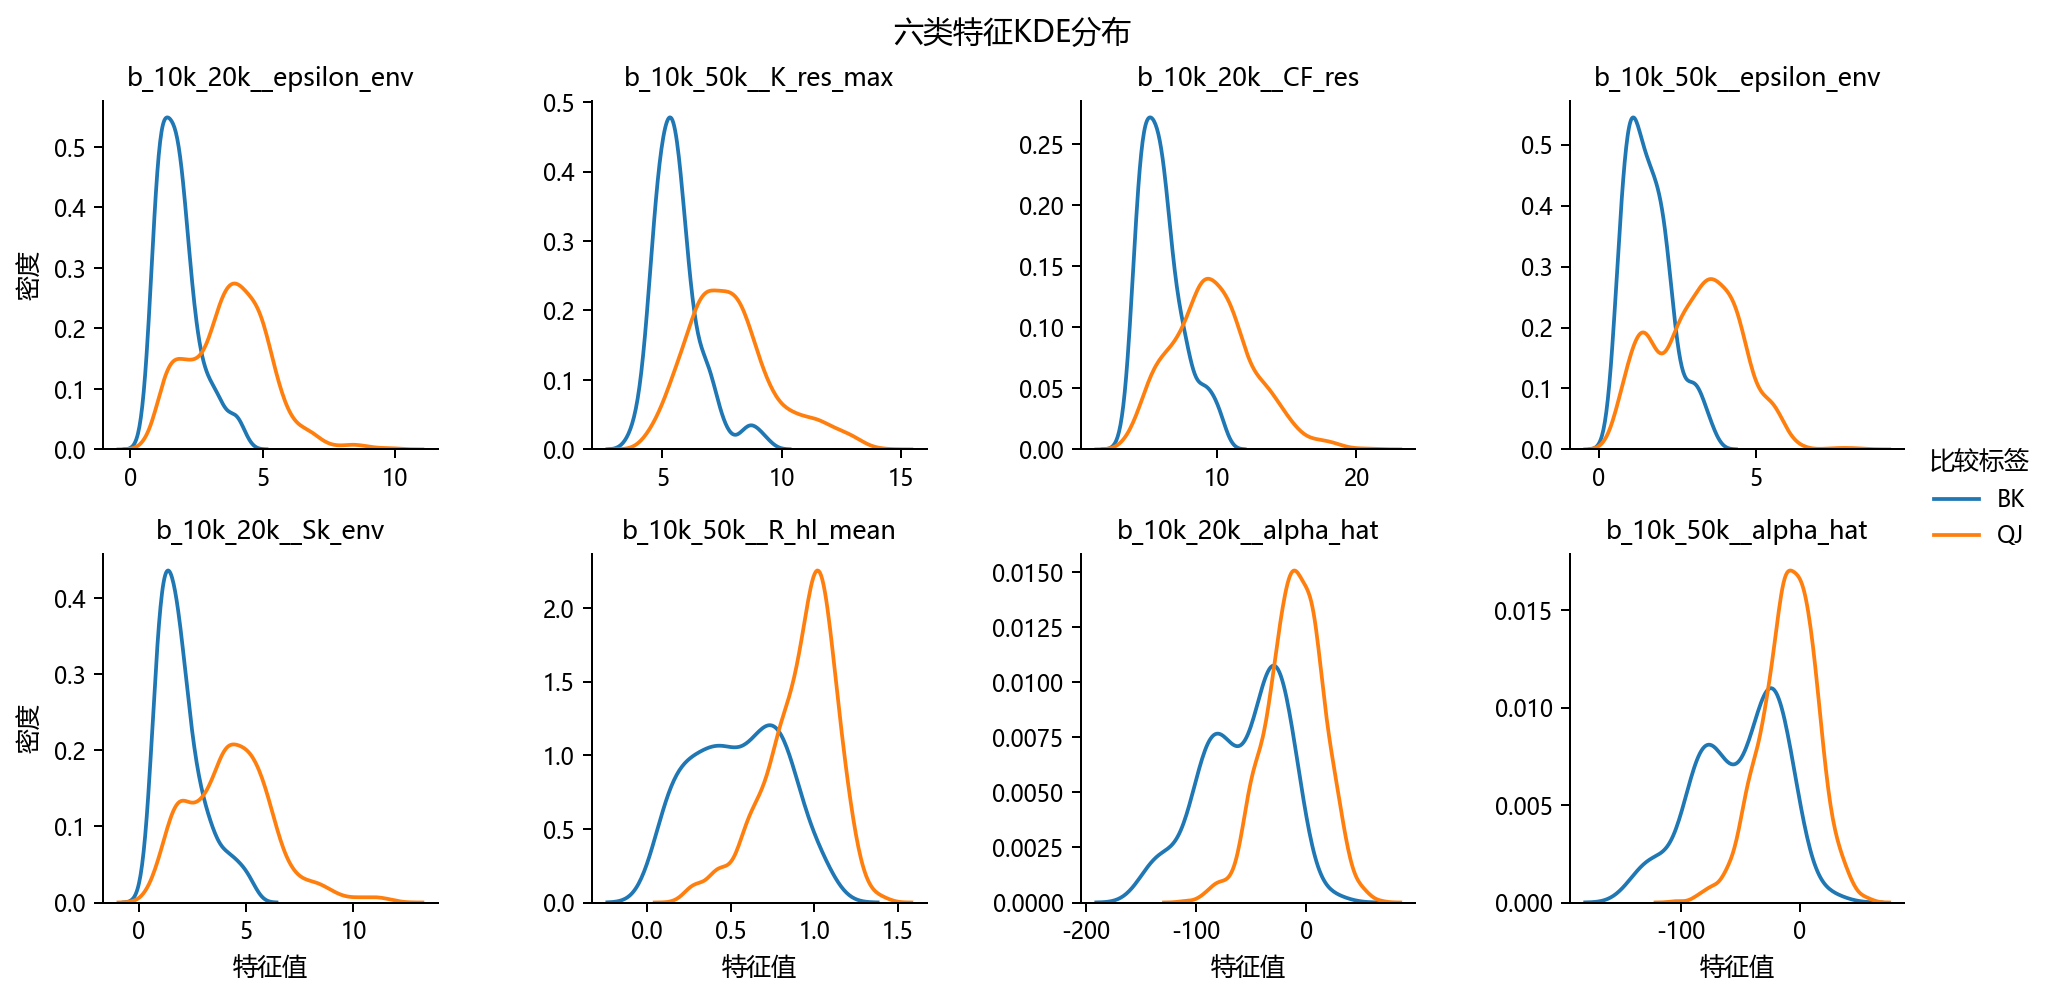

**图 15 2.5 (BK00+BK05) vs (QJ00+QJ05) PCA投影图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图15_2.5_(BK00+BK05)_vs_(QJ00+QJ05)_PCA投影图.png`</sub>

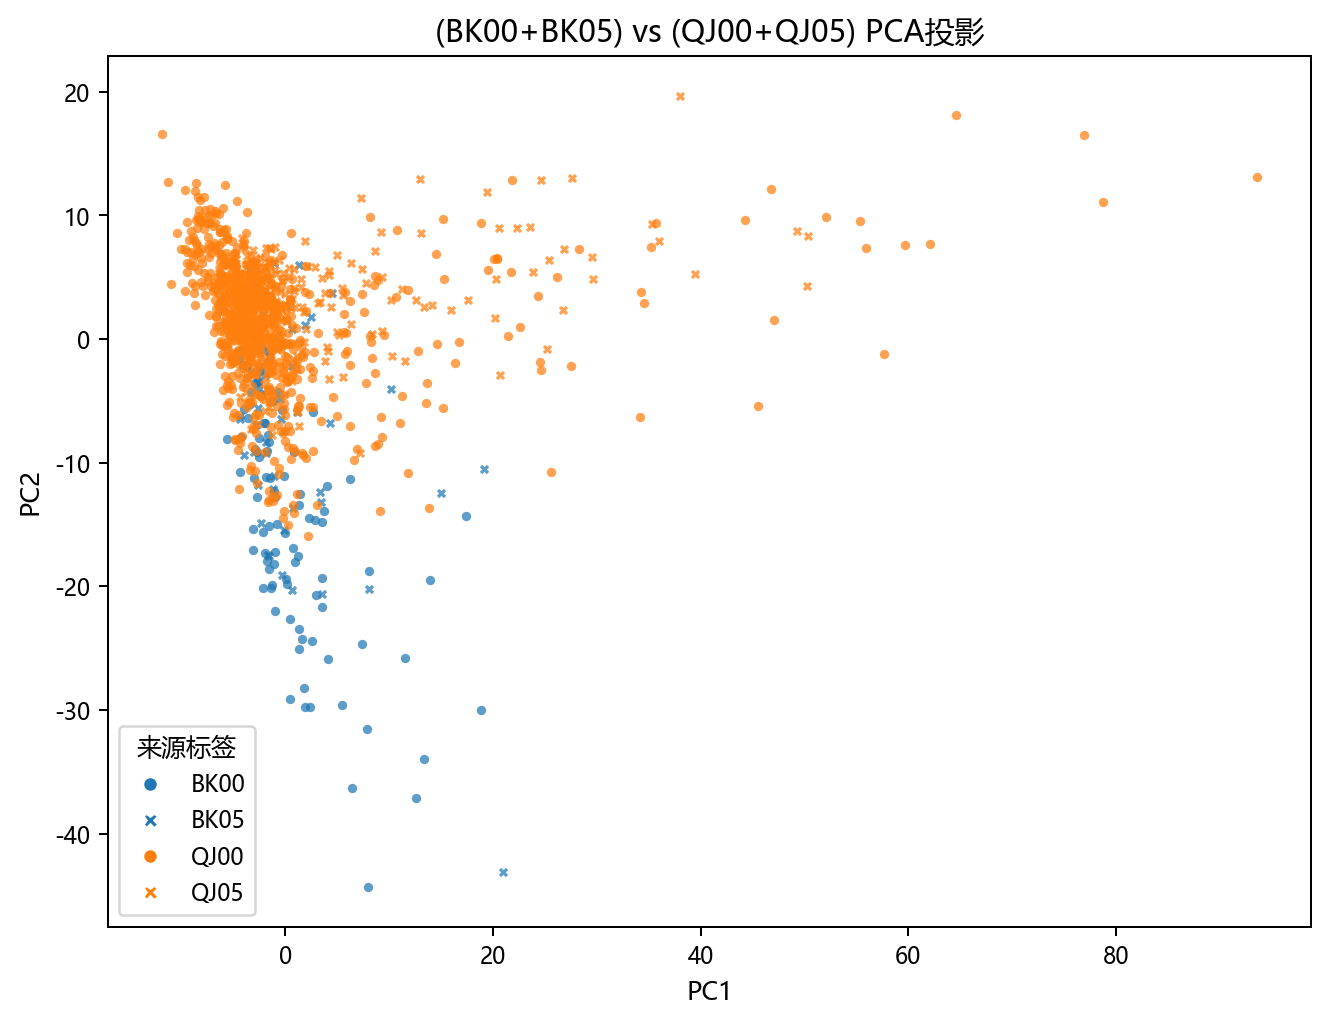

In [13]:
# 2.5 (BK00+BK05) vs (QJ00+QJ05)
df_bk_all = df[df['source_label'].isin(['BK00', 'BK05'])].copy()
df_bk_all['binary_label'] = 'BK'

df_qj_all = df[df['source_label'].isin(['QJ00', 'QJ05'])].copy()
df_qj_all['binary_label'] = 'QJ'

df_bk_qj = pd.concat([df_bk_all, df_qj_all], ignore_index=True)

bk_qj_f_ratio = compute_two_class_f_ratio(df_bk_qj, feature_cols, label_col='binary_label', class_a='BK', class_b='QJ')
bk_qj_distribution_metrics = attach_kde_metrics_to_ranking(df_bk_qj, bk_qj_f_ratio, 'binary_label', top_n=8)
top_features_2_5 = bk_qj_distribution_metrics['feature'].tolist()


boxplot_path_2_5 = RUN_DIR / 'plots/bk_all_vs_qj_all_boxplots.png'
# ---- 内联箱线图：幅值差异巨大的特征改用断裂坐标轴（截断轴）；代码内联，便于调整 ----
import numpy as np
import matplotlib.pyplot as plt
from pccp_feature_mining.feature_schema import impute_with_median, numeric_feature_frame
from pccp_feature_mining.visualization import _configure_font

_configure_font()
_box_break_ratio = 50.0    # 最大/最小类中位数比值超过该值 => 幅值差异巨大，改用断裂坐标轴
_box_split_factor = 10.0   # 中位数高于几何均值的该倍数视为高幅值类（进入顶部小面板）
_box_fliers = True         # 底部主体面板是否显示离群点（四分位/须线/离群点默认全部可见）
_box_feats = top_features_2_5[:8]
_box_df = df_bk_qj
_box_label = 'binary_label'
_box_ncols = 4
_box_path = boxplot_path_2_5

_box_x = impute_with_median(numeric_feature_frame(_box_df, _box_feats))
_box_p = pd.concat([_box_df[_box_label].reset_index(drop=True).to_frame(), _box_x.reset_index(drop=True)], axis=1)
_box_classes = sorted(str(_c) for _c in _box_p[_box_label].astype(str).unique())
_box_rows = -(-len(_box_feats) // _box_ncols)
_box_fig, _box_axes = plt.subplots(_box_rows, _box_ncols, figsize=(11.0, 2.9 * _box_rows), squeeze=False)
_box_fig.suptitle('Top8特征分布箱线图（幅值差异巨大时上下分栏）', y=0.995, fontsize=12)
_box_bp_kw = dict(widths=0.5, patch_artist=True,
                  medianprops=dict(color='black', lw=1.0),
                  boxprops=dict(facecolor='#9ecae1', edgecolor='#3182bd'),
                  whiskerprops=dict(color='#3182bd'), capprops=dict(color='#3182bd'))
_box_bk_kw = dict(marker=[(-1, -0.5), (1, 0.5)], markersize=12, linestyle='none', color='k', mec='k', mew=1, clip_on=False)

for _i, _feat in enumerate(_box_feats):
    _g = _box_axes[_i // _box_ncols][_i % _box_ncols]
    _cols_data = []
    _meds = []
    for _c in _box_classes:
        _v = np.asarray(_box_p.loc[_box_p[_box_label].astype(str) == _c, _feat].dropna(), dtype=float)
        if _v.size == 0:
            continue
        _cols_data.append((_c, _v))
        _meds.append(float(np.median(_v)))
    if not _cols_data:
        _g.axis('off')
        continue
    _med_abs = np.abs(np.array(_meds))
    _use_break = bool(_med_abs.size >= 2 and _med_abs.min() > 0 and _med_abs.max() / _med_abs.min() >= _box_break_ratio)
    _top = []
    _bot = []
    if _use_break:
        _gm = np.sqrt(_med_abs.max() * _med_abs.min())
        _top = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) > _box_split_factor * _gm]
        _bot = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) <= _box_split_factor * _gm]
        if not _top or not _bot:
            _use_break = False
    if not _use_break:
        _g.boxplot([_v for _, _v in _cols_data], positions=np.arange(len(_cols_data)), showfliers=_box_fliers, **_box_bp_kw)
        _g.set_title(_feat, fontsize=9)
        _g.set_xticks(np.arange(len(_cols_data)))
        _g.set_xticklabels([_c for _c, _ in _cols_data], rotation=30, ha='right', fontsize=8)
        _g.set_ylabel('特征值', fontsize=9)
        _g.grid(axis='y', ls=':', alpha=0.5)
        continue
    _gs = _g.get_subplotspec().subgridspec(2, 1, height_ratios=[1, 3], hspace=0.10)
    _g.axis('off')
    _a_top = _box_fig.add_subplot(_gs[0])
    _a_bot = _box_fig.add_subplot(_gs[1])
    _a_top.boxplot([_v for _, _v in _top], positions=np.arange(len(_top)), showfliers=False, **_box_bp_kw)
    _a_bot.boxplot([_v for _, _v in _bot], positions=np.arange(len(_bot)), showfliers=_box_fliers, **_box_bp_kw)
    _a_top.set_title(_feat, fontsize=9)
    _a_bot.set_ylabel('特征值', fontsize=9)
    _ymin_t = min(float(np.min(_v)) for _, _v in _top)
    _ymax_t = max(float(np.max(_v)) for _, _v in _top)
    _a_top.set_ylim(_ymin_t - 0.05 * (_ymax_t - _ymin_t + 1e-12), _ymax_t + 0.05 * (_ymax_t - _ymin_t + 1e-12))
    _ymin_b = min(float(np.min(_v)) for _, _v in _bot)
    _ymax_b = max(float(np.max(_v)) for _, _v in _bot)
    _a_bot.set_ylim(_ymin_b - 0.08 * (_ymax_b - _ymin_b + 1e-12), _ymax_b + 0.08 * (_ymax_b - _ymin_b + 1e-12))
    _a_top.set_xticks(np.arange(len(_top)))
    _a_top.set_xticklabels([_c for _c, _ in _top], fontsize=7)
    _a_bot.set_xticks(np.arange(len(_bot)))
    _a_bot.set_xticklabels([_c for _c, _ in _bot], rotation=30, ha='right', fontsize=8)
    for _sp in ('top', 'right'):
        _a_top.spines[_sp].set_visible(False)
        _a_bot.spines[_sp].set_visible(False)
    _a_top.plot([0, 1], [0, 0], transform=_a_top.transAxes, **_box_bk_kw)
    _a_bot.plot([0, 1], [0, 1], transform=_a_bot.transAxes, **_box_bk_kw)

_box_fig.tight_layout()
_box_fig.savefig(_box_path, dpi=180, bbox_inches='tight')
plt.close(_box_fig)

kde_path_2_5 = RUN_DIR / 'plots/bk_all_vs_qj_all_kde.png'
plot_feature_kde_by_label(df_bk_qj, top_features_2_5[:8], kde_path_2_5, col_wrap=4, label_col='binary_label')

pca_projection_2_5, pca_explained_2_5 = run_pca_projection(df_bk_qj, feature_cols, max_rows=CONFIG.projection_max_rows, random_state=CONFIG.random_state)
pca_path_2_5 = RUN_DIR / 'plots/bk_all_vs_qj_all_pca.png'
plot_projection(pca_projection_2_5, 'PC1', 'PC2', pca_path_2_5, '(BK00+BK05) vs (QJ00+QJ05) PCA投影')

show_table('2.5 (BK00+BK05) vs (QJ00+QJ05) F-ratio与KDE分布差异指标', bk_qj_distribution_metrics, rows=10)
show_image('2.5 (BK00+BK05) vs (QJ00+QJ05) 箱线图', boxplot_path_2_5)
show_image('2.5 (BK00+BK05) vs (QJ00+QJ05) KDE分布图', kde_path_2_5)
show_image('2.5 (BK00+BK05) vs (QJ00+QJ05) PCA投影图', pca_path_2_5)

### 2.6 (BK00+BK05) vs (QJ00+QJ05+FL00+FL05)

断丝信号集合（BK00+BK05）与全部非断丝信号集合（QJ00+QJ05+FL00+FL05）的特征分布差异。

**表 12 2.6 (BK00+BK05) vs (QJ00+QJ05+FL00+FL05) F-ratio与KDE分布差异指标**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表12_2.6_(BK00+BK05)_vs_(QJ00+QJ05+FL00+FL05)_F-ratio与KDE分布差异指标.csv`</sub>

,feature,f_ratio,between_var,within_var,kde_pair_count,kde_overlap_mean,kde_overlap_min,kde_overlap_max,kde_separation_mean,kde_separation_max,特征中文含义
3,b_40k_60k__SF,10.428,0.225,0.022,1,0.002,0.002,0.002,0.998,0.998,40-60 kHz频带，谱平坦度，描述频谱接近噪声或窄带结构的程度
4,b_30k_40k__SF,10.409,0.225,0.022,1,0.002,0.002,0.002,0.998,0.998,30-40 kHz频带，谱平坦度，描述频谱接近噪声或窄带结构的程度
2,b_40k_60k__epsilon_2x,10.431,0.892,0.086,1,0.002,0.002,0.002,0.998,0.998,40-60 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
6,b_30k_40k__C_h,10.405,983835303.728,94556582.470,1,0.004,0.004,0.004,0.996,0.996,30-40 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
5,b_30k_40k__epsilon_2x,10.408,0.905,0.087,1,0.019,0.019,0.019,0.981,0.981,30-40 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
1,b_20k_30k__C_h,10.473,451619518.748,43123044.236,1,0.030,0.030,0.030,0.970,0.970,20-30 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
7,b_30k_40k__H2_ratio,10.387,0.223,0.021,1,0.032,0.032,0.032,0.968,0.968,30-40 kHz频带，二倍频能量比，描述二倍频结构强度
0,b_20k_30k__epsilon_2x,10.481,0.860,0.082,1,0.037,0.037,0.037,0.963,0.963,20-30 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差


**图 16 2.6 (BK00+BK05) vs (QJ00+QJ05+FL00+FL05) 箱线图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图16_2.6_(BK00+BK05)_vs_(QJ00+QJ05+FL00+FL05)_箱线图.png`</sub>

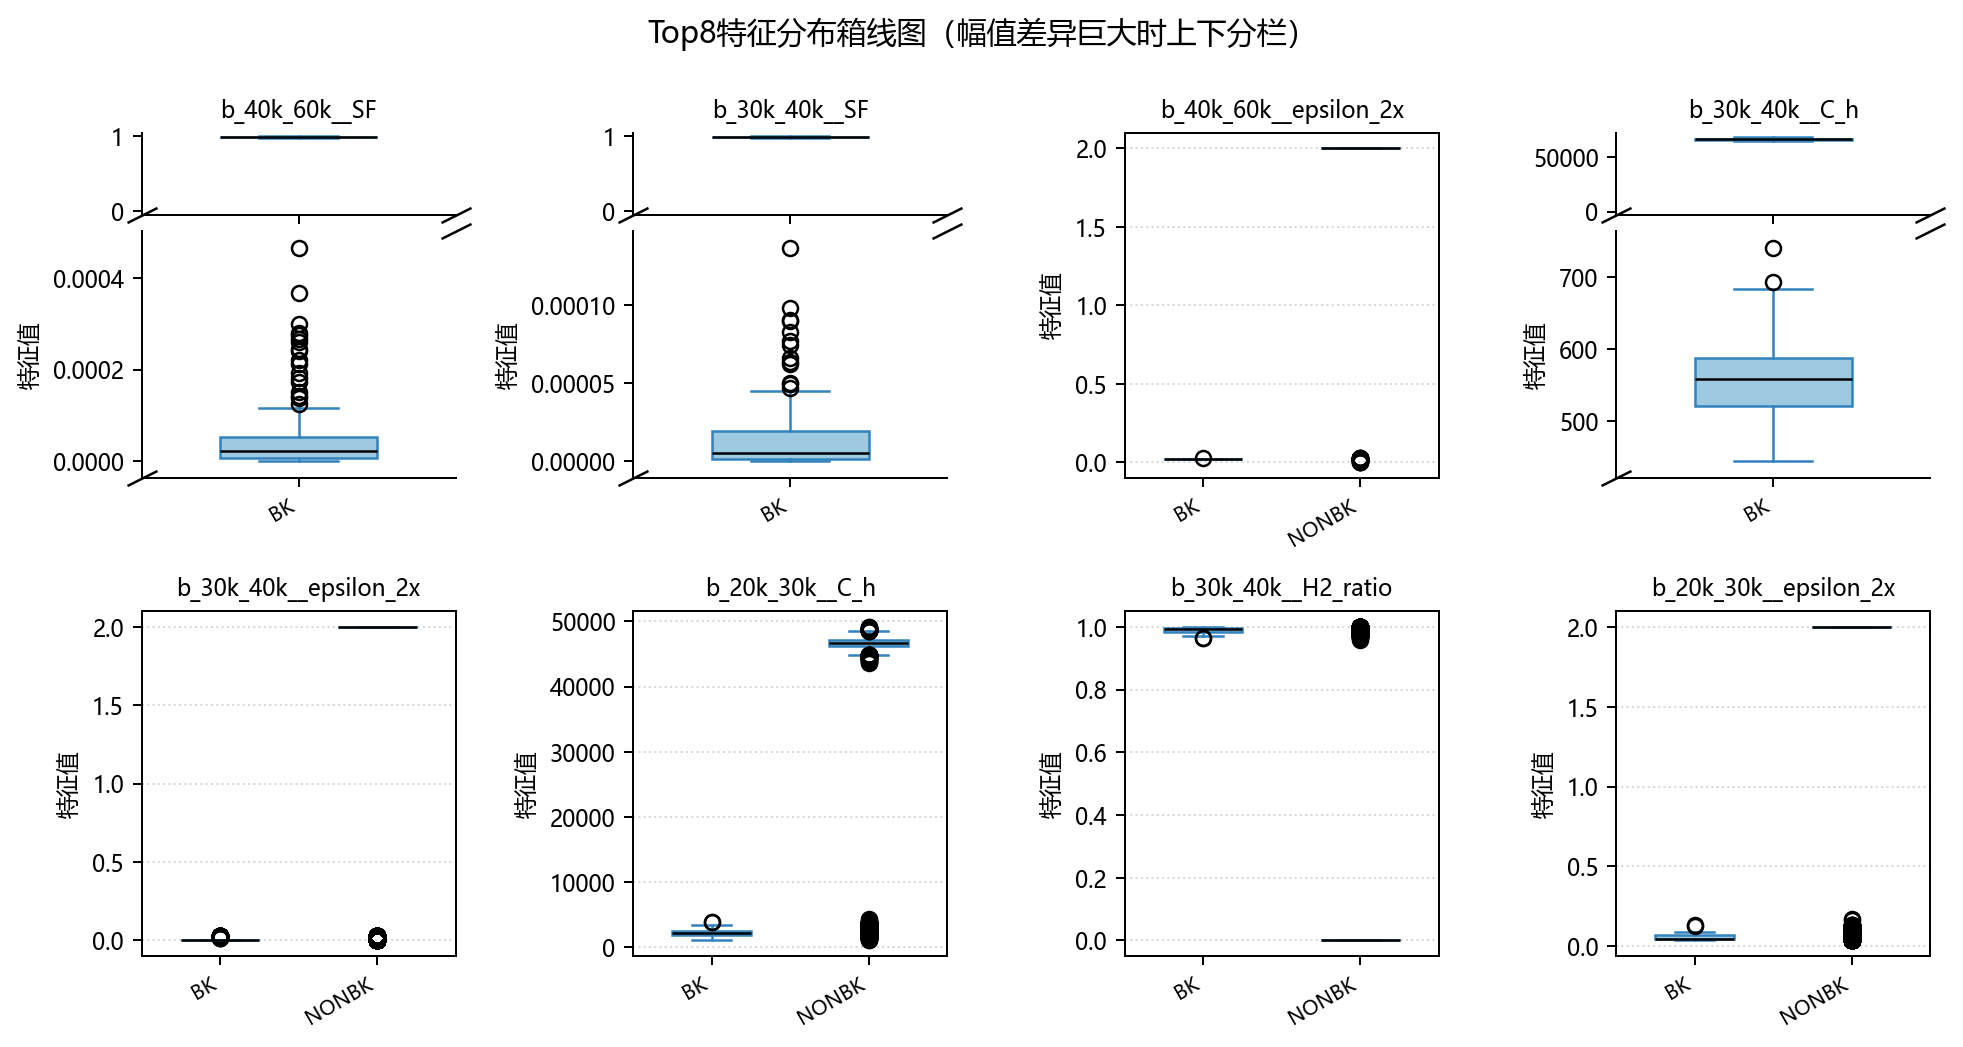

**图 17 2.6 (BK00+BK05) vs (QJ00+QJ05+FL00+FL05) KDE分布图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图17_2.6_(BK00+BK05)_vs_(QJ00+QJ05+FL00+FL05)_KDE分布图.png`</sub>

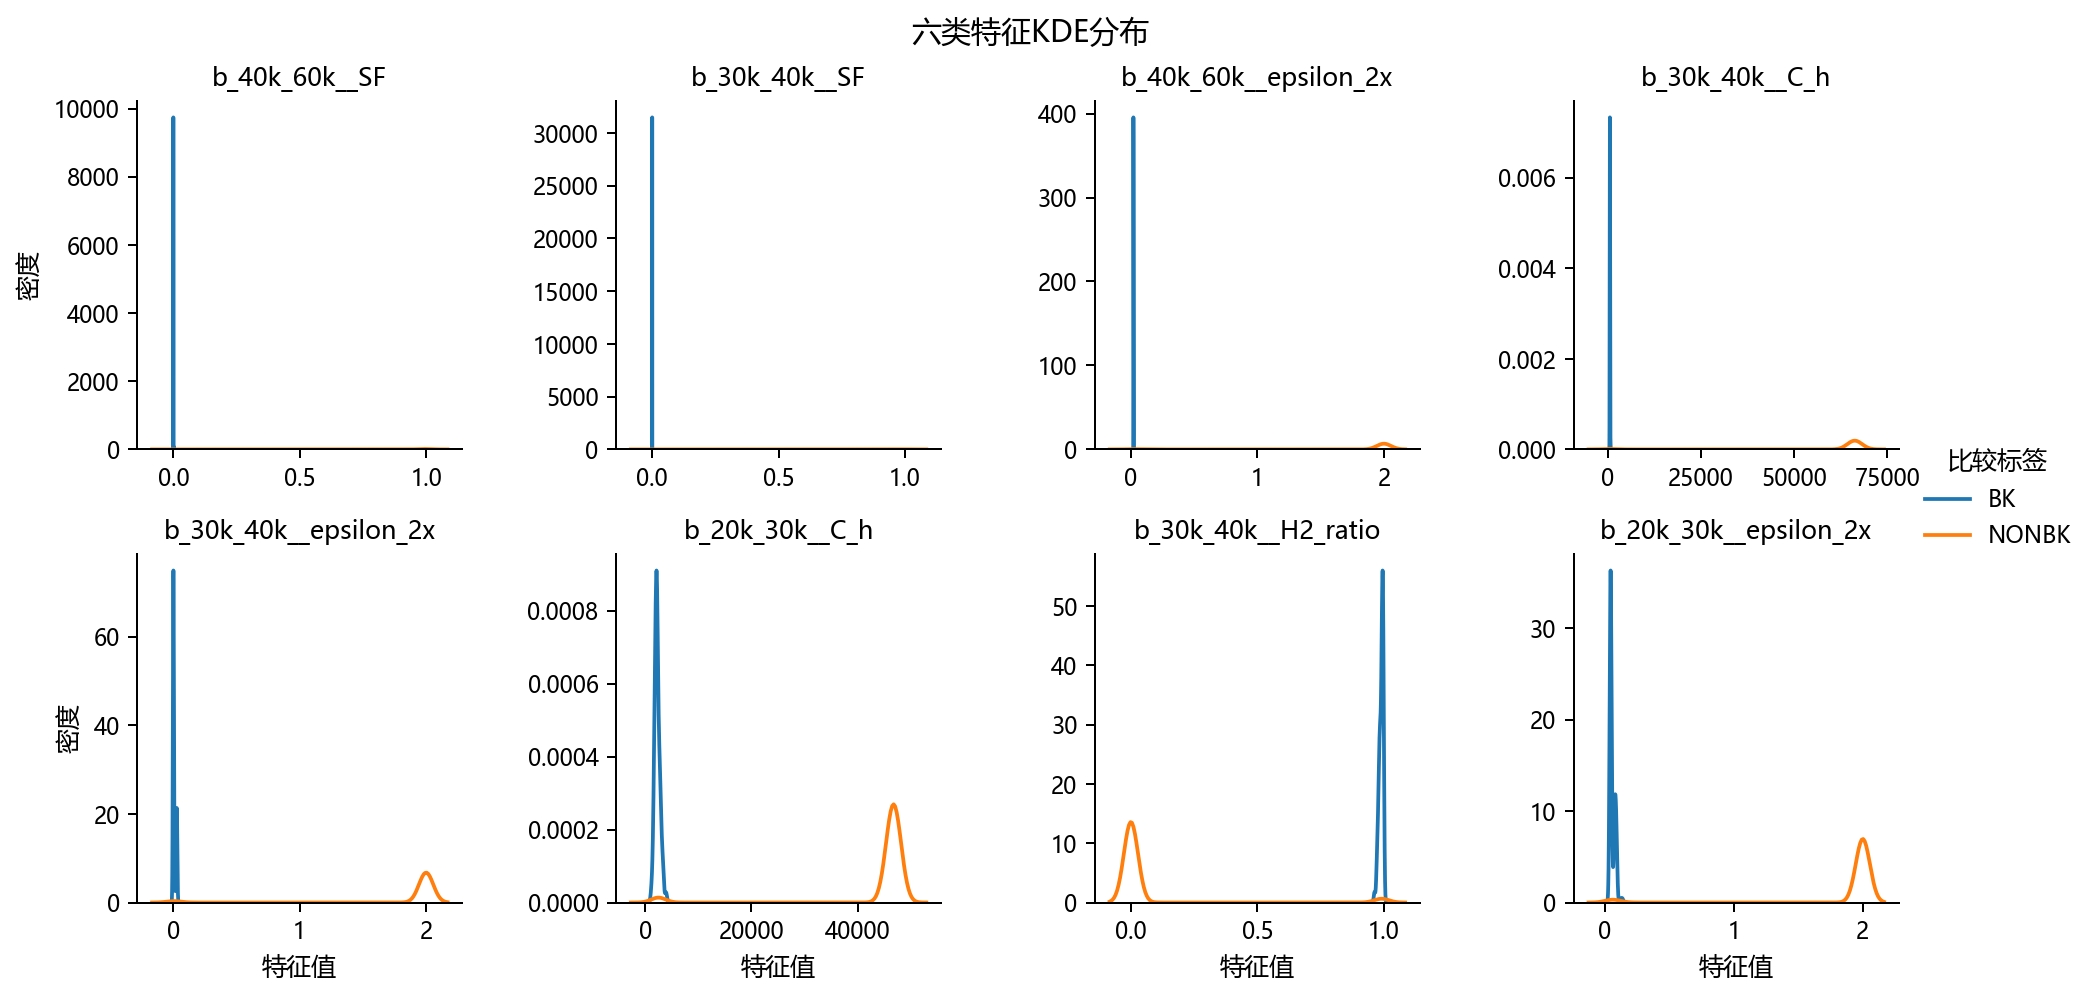

**图 18 2.6 (BK00+BK05) vs (QJ00+QJ05+FL00+FL05) PCA投影图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图18_2.6_(BK00+BK05)_vs_(QJ00+QJ05+FL00+FL05)_PCA投影图.png`</sub>

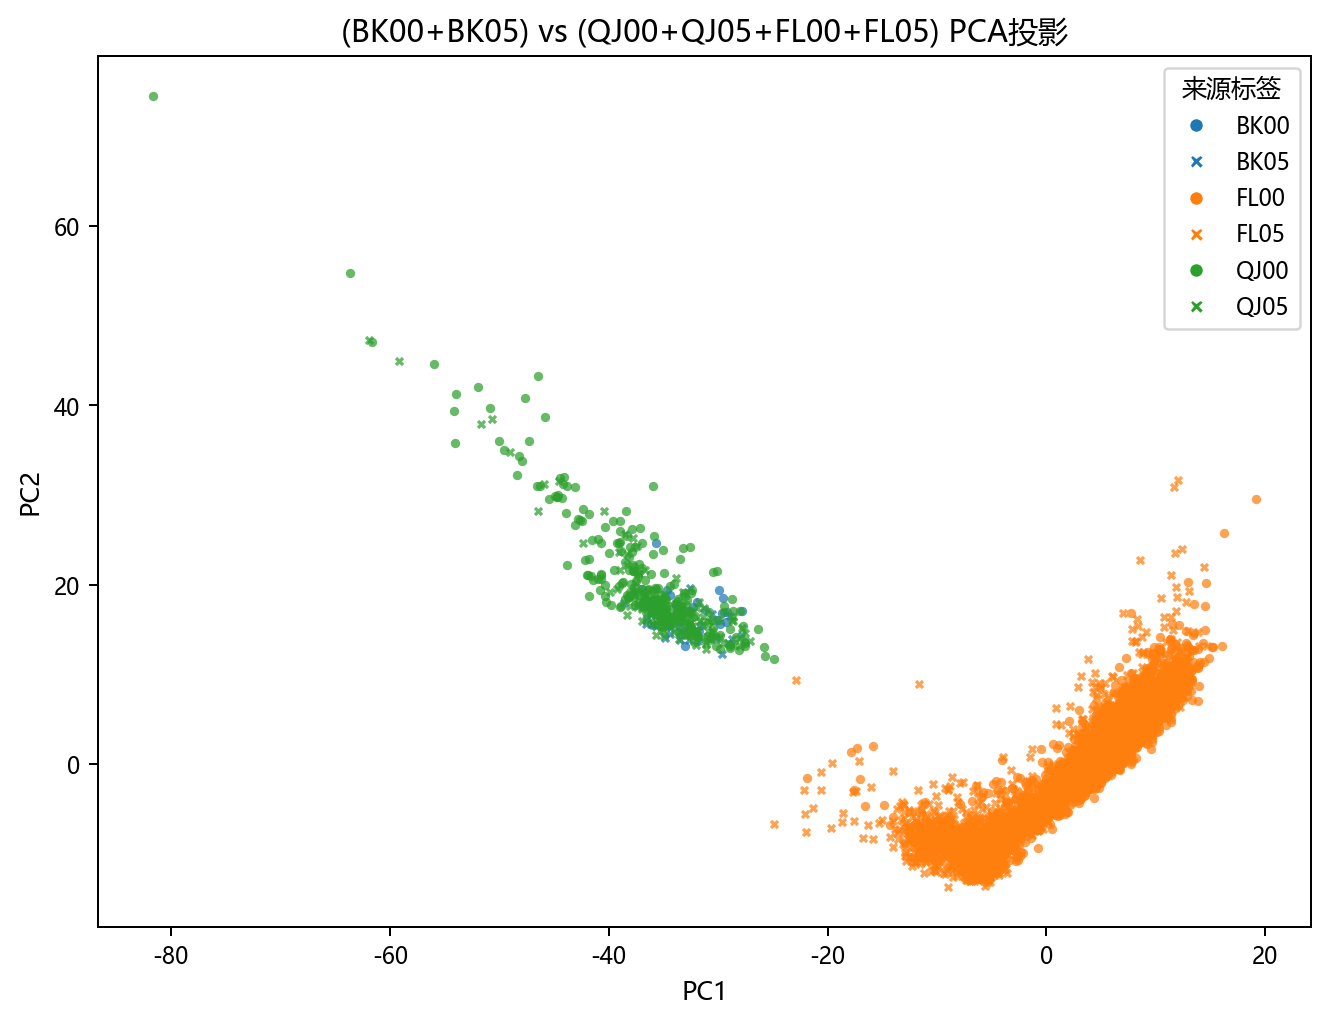

In [14]:
# 2.6 (BK00+BK05) vs (QJ00+QJ05+FL00+FL05)
df_bk_all = df[df['source_label'].isin(['BK00', 'BK05'])].copy()
df_bk_all['binary_label'] = 'BK'

df_non_bk = df[df['source_label'].isin(['QJ00', 'QJ05', 'FL00', 'FL05'])].copy()
df_non_bk['binary_label'] = 'NONBK'

df_bk_nonbk = pd.concat([df_bk_all, df_non_bk], ignore_index=True)

bk_nonbk_f_ratio = compute_two_class_f_ratio(df_bk_nonbk, feature_cols, label_col='binary_label', class_a='BK', class_b='NONBK')
bk_nonbk_distribution_metrics = attach_kde_metrics_to_ranking(df_bk_nonbk, bk_nonbk_f_ratio, 'binary_label', top_n=8)
top_features_2_6 = bk_nonbk_distribution_metrics['feature'].tolist()


boxplot_path_2_6 = RUN_DIR / 'plots/bk_all_vs_nonbk_all_boxplots.png'
# ---- 内联箱线图：幅值差异巨大的特征改用断裂坐标轴（截断轴）；代码内联，便于调整 ----
import numpy as np
import matplotlib.pyplot as plt
from pccp_feature_mining.feature_schema import impute_with_median, numeric_feature_frame
from pccp_feature_mining.visualization import _configure_font

_configure_font()
_box_break_ratio = 50.0    # 最大/最小类中位数比值超过该值 => 幅值差异巨大，改用断裂坐标轴
_box_split_factor = 10.0   # 中位数高于几何均值的该倍数视为高幅值类（进入顶部小面板）
_box_fliers = True         # 底部主体面板是否显示离群点（四分位/须线/离群点默认全部可见）
_box_feats = top_features_2_6[:8]
_box_df = df_bk_nonbk
_box_label = 'binary_label'
_box_ncols = 4
_box_path = boxplot_path_2_6

_box_x = impute_with_median(numeric_feature_frame(_box_df, _box_feats))
_box_p = pd.concat([_box_df[_box_label].reset_index(drop=True).to_frame(), _box_x.reset_index(drop=True)], axis=1)
_box_classes = sorted(str(_c) for _c in _box_p[_box_label].astype(str).unique())
_box_rows = -(-len(_box_feats) // _box_ncols)
_box_fig, _box_axes = plt.subplots(_box_rows, _box_ncols, figsize=(11.0, 2.9 * _box_rows), squeeze=False)
_box_fig.suptitle('Top8特征分布箱线图（幅值差异巨大时上下分栏）', y=0.995, fontsize=12)
_box_bp_kw = dict(widths=0.5, patch_artist=True,
                  medianprops=dict(color='black', lw=1.0),
                  boxprops=dict(facecolor='#9ecae1', edgecolor='#3182bd'),
                  whiskerprops=dict(color='#3182bd'), capprops=dict(color='#3182bd'))
_box_bk_kw = dict(marker=[(-1, -0.5), (1, 0.5)], markersize=12, linestyle='none', color='k', mec='k', mew=1, clip_on=False)

for _i, _feat in enumerate(_box_feats):
    _g = _box_axes[_i // _box_ncols][_i % _box_ncols]
    _cols_data = []
    _meds = []
    for _c in _box_classes:
        _v = np.asarray(_box_p.loc[_box_p[_box_label].astype(str) == _c, _feat].dropna(), dtype=float)
        if _v.size == 0:
            continue
        _cols_data.append((_c, _v))
        _meds.append(float(np.median(_v)))
    if not _cols_data:
        _g.axis('off')
        continue
    _med_abs = np.abs(np.array(_meds))
    _use_break = bool(_med_abs.size >= 2 and _med_abs.min() > 0 and _med_abs.max() / _med_abs.min() >= _box_break_ratio)
    _top = []
    _bot = []
    if _use_break:
        _gm = np.sqrt(_med_abs.max() * _med_abs.min())
        _top = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) > _box_split_factor * _gm]
        _bot = [(_c, _v) for (_c, _v), _m in zip(_cols_data, _meds) if abs(_m) <= _box_split_factor * _gm]
        if not _top or not _bot:
            _use_break = False
    if not _use_break:
        _g.boxplot([_v for _, _v in _cols_data], positions=np.arange(len(_cols_data)), showfliers=_box_fliers, **_box_bp_kw)
        _g.set_title(_feat, fontsize=9)
        _g.set_xticks(np.arange(len(_cols_data)))
        _g.set_xticklabels([_c for _c, _ in _cols_data], rotation=30, ha='right', fontsize=8)
        _g.set_ylabel('特征值', fontsize=9)
        _g.grid(axis='y', ls=':', alpha=0.5)
        continue
    _gs = _g.get_subplotspec().subgridspec(2, 1, height_ratios=[1, 3], hspace=0.10)
    _g.axis('off')
    _a_top = _box_fig.add_subplot(_gs[0])
    _a_bot = _box_fig.add_subplot(_gs[1])
    _a_top.boxplot([_v for _, _v in _top], positions=np.arange(len(_top)), showfliers=False, **_box_bp_kw)
    _a_bot.boxplot([_v for _, _v in _bot], positions=np.arange(len(_bot)), showfliers=_box_fliers, **_box_bp_kw)
    _a_top.set_title(_feat, fontsize=9)
    _a_bot.set_ylabel('特征值', fontsize=9)
    _ymin_t = min(float(np.min(_v)) for _, _v in _top)
    _ymax_t = max(float(np.max(_v)) for _, _v in _top)
    _a_top.set_ylim(_ymin_t - 0.05 * (_ymax_t - _ymin_t + 1e-12), _ymax_t + 0.05 * (_ymax_t - _ymin_t + 1e-12))
    _ymin_b = min(float(np.min(_v)) for _, _v in _bot)
    _ymax_b = max(float(np.max(_v)) for _, _v in _bot)
    _a_bot.set_ylim(_ymin_b - 0.08 * (_ymax_b - _ymin_b + 1e-12), _ymax_b + 0.08 * (_ymax_b - _ymin_b + 1e-12))
    _a_top.set_xticks(np.arange(len(_top)))
    _a_top.set_xticklabels([_c for _c, _ in _top], fontsize=7)
    _a_bot.set_xticks(np.arange(len(_bot)))
    _a_bot.set_xticklabels([_c for _c, _ in _bot], rotation=30, ha='right', fontsize=8)
    for _sp in ('top', 'right'):
        _a_top.spines[_sp].set_visible(False)
        _a_bot.spines[_sp].set_visible(False)
    _a_top.plot([0, 1], [0, 0], transform=_a_top.transAxes, **_box_bk_kw)
    _a_bot.plot([0, 1], [0, 1], transform=_a_bot.transAxes, **_box_bk_kw)

_box_fig.tight_layout()
_box_fig.savefig(_box_path, dpi=180, bbox_inches='tight')
plt.close(_box_fig)

kde_path_2_6 = RUN_DIR / 'plots/bk_all_vs_nonbk_all_kde.png'
plot_feature_kde_by_label(df_bk_nonbk, top_features_2_6[:8], kde_path_2_6, col_wrap=4, label_col='binary_label')

pca_projection_2_6, pca_explained_2_6 = run_pca_projection(df_bk_nonbk, feature_cols, max_rows=CONFIG.projection_max_rows, random_state=CONFIG.random_state)
pca_path_2_6 = RUN_DIR / 'plots/bk_all_vs_nonbk_all_pca.png'
plot_projection(pca_projection_2_6, 'PC1', 'PC2', pca_path_2_6, '(BK00+BK05) vs (QJ00+QJ05+FL00+FL05) PCA投影')

show_table('2.6 (BK00+BK05) vs (QJ00+QJ05+FL00+FL05) F-ratio与KDE分布差异指标', bk_nonbk_distribution_metrics, rows=10)
show_image('2.6 (BK00+BK05) vs (QJ00+QJ05+FL00+FL05) 箱线图', boxplot_path_2_6)
show_image('2.6 (BK00+BK05) vs (QJ00+QJ05+FL00+FL05) KDE分布图', kde_path_2_6)
show_image('2.6 (BK00+BK05) vs (QJ00+QJ05+FL00+FL05) PCA投影图', pca_path_2_6)

### 2.7 每个来源类别的特征均值何时趋于稳定

本小节回答一个样本量问题：对 `BK00/BK05/FL00/FL05/QJ00/QJ05` 每个来源类别，当前候选特征集合的均值统计量大约在多少样本后趋于稳定。这里不重新筛选特征，也不使用类别判别标签，而是把所有有效特征先全局标准化，再按来源类别分别估计均值向量的收敛曲线。

给出两种相互独立的估计口径：

1. **相邻样本量均值漂移法**：对样本量序列 $n_1<n_2<\dots<n_t$，每个 $n_i$ 重复无放回抽样并计算标准化特征均值向量 $\bar{x}_{n_i}$，再计算相邻样本量之间的相对 L2 变化：

$$
D_i=\frac{\lVert \bar{x}_{n_i}-\bar{x}_{n_{i-1}}\rVert_2}{\lVert \bar{x}_{n_{i-1}}\rVert_2+\epsilon}
$$

当 $D_i$ 连续低于 `sample_stability_adjacent_threshold` 时，认为继续增加样本对均值向量的增量影响已经较小。

2. **全量均值参照 Bootstrap 误差法**：对同一个来源类别，先用当前全部样本计算参照均值向量 $\bar{x}_{all}$，再对每个样本量 $n_i$ 重复抽样得到 $\bar{x}^{(b)}_{n_i}$，计算其相对全量均值误差：

$$
E_i^{(b)}=\frac{\lVert \bar{x}^{(b)}_{n_i}-\bar{x}_{all}\rVert_2}{\lVert \bar{x}_{all}\rVert_2+\epsilon}
$$

表中使用误差的均值和 P90；当 P90 连续低于 `sample_stability_reference_threshold` 时，认为在多数抽样情况下已经接近当前全量估计。最终建议样本量取两种方法给出的稳定样本量中较大的一个；如果只有一种方法达标，则标记为 `one_method_stable`，如果两种都未达标，则说明当前样本量范围内仍不能确认稳定。

In [ ]:
from pccp_feature_mining.distribution_analysis import (
    estimate_source_feature_stability,
    plot_source_feature_stability_curves,
)

sample_stability_curve, sample_stability_summary = estimate_source_feature_stability(
    df,
    feature_cols,
    repeats=CONFIG.sample_stability_repeats,
    min_samples=CONFIG.sample_stability_min_samples,
    adjacent_threshold=CONFIG.sample_stability_adjacent_threshold,
    reference_threshold=CONFIG.sample_stability_reference_threshold,
    consecutive_points=CONFIG.sample_stability_consecutive_points,
    random_state=CONFIG.random_state,
)

write_csv(sample_stability_curve, RUN_DIR / 'sample_stability_curve.csv')
write_csv(sample_stability_summary, RUN_DIR / 'sample_stability_summary.csv')

sample_stability_plot_path = RUN_DIR / 'plots/sample_stability_curves.png'
plot_source_feature_stability_curves(sample_stability_curve, sample_stability_plot_path)

sample_stability_parameter_table = pd.DataFrame([
    {'参数': 'sample_stability_repeats', '当前值': CONFIG.sample_stability_repeats, '含义': '每个样本量重复无放回抽样次数'},
    {'参数': 'sample_stability_min_samples', '当前值': CONFIG.sample_stability_min_samples, '含义': '自动样本量网格的最小起点'},
    {'参数': 'sample_stability_adjacent_threshold', '当前值': CONFIG.sample_stability_adjacent_threshold, '含义': '相邻均值漂移法稳定阈值'},
    {'参数': 'sample_stability_reference_threshold', '当前值': CONFIG.sample_stability_reference_threshold, '含义': '全量均值参照法P90误差稳定阈值'},
    {'参数': 'sample_stability_consecutive_points', '当前值': CONFIG.sample_stability_consecutive_points, '含义': '连续满足阈值的样本量点数'},
])

show_table('2.7 样本量稳定性估计参数', sample_stability_parameter_table)
show_table('2.7 各来源类别建议稳定样本量', sample_stability_summary)
show_table('2.7 样本量稳定性曲线明细', sample_stability_curve, rows=60)
show_image('2.7 各来源类别特征均值稳定性曲线', sample_stability_plot_path)

## 03 单特征判别能力分析

本节对每个单特征计算二分类判别能力，回答"该特征在多大程度上能单独区分断丝与非断丝"。由于不同类型样本数量不一致，本章默认采用重复平衡下采样：每个比较任务以少数类样本数为基准，每轮从多数类无放回随机抽取等量样本，重复 `discrimination_balance_repeats` 次后对指标取均值，并输出标准差列。这样可以降低多数类样本量过大对 Wasserstein、互信息和综合排序的影响，也便于观察指标是否依赖某一次随机抽样。

**核心指标与公式**（记正类样本集 $P$、负类样本集 $N$，特征取值 $x$）

- **AUC（ROC 曲线下面积）**：衡量特征值排序能把正类排在负类前面的概率：
  $$\mathrm{AUC}=\frac{1}{|N|}\sum_{j\in N}\frac{\#\{i\in P: x_i > x_j\}}{|P|}$$
  并派生两个无量纲量：
  $$\mathrm{auc\_abs}=\max(\mathrm{AUC},\,1-\mathrm{AUC}),\qquad \mathrm{auc\_lift}=\mathrm{auc\_abs}-0.5$$
  $0.5$ 表示随机，越接近 $1$ 分离越强；取无方向是为了"哪一类偏大"不预先假设。

- **Wasserstein 距离（推土机距离 EMD）**：衡量两类分布的整体位移，
  $$W_1(P,N)=\int_{-\infty}^{+\infty}\big\lvert F_P(u)-F_N(u)\big\rvert\,\mathrm{d}u$$
  即两个经验 CDF 之间围成的面积；归一化 `wasserstein_norm = W_1 / IQR`（IQR 为合并样本的四分位距），越大越分离。

- **Cliff's delta**：衡量"正类样本取值大于负类样本"的优势概率，
  $$\delta = \frac{2U}{|P||N|}-1=\frac{\#(x_p>x_n)-\#(x_p<x_n)}{|P||N|},\qquad \delta\in[-1,1]$$
  绝对值越大，两类两两比较的优势越明显。

- **互信息（Mutual Information）**：衡量非线性依赖，
  $$I(x;y)=\sum_{x,y}p(x,y)\log\frac{p(x,y)}{p(x)p(y)}$$
  用 `mutual_info_classif`（k近邻/直方图估计）计算，值越大依赖越强。

- **综合判别分**（`discrimination_score`，用于 mRMR、冗余组和最终排序）：
  $$\mathrm{discrimination\_score}=0.55\cdot2\cdot\max(\mathrm{auc\_lift},0)+0.30\cdot\min(|\delta|,1)+0.15\cdot\frac{I(x;y)}{1+I(x;y)}$$

**表格显示规则**：第 3 章每张排序表最多显示 10 行；完整结果仍保存到 CSV，供复核和后续筛选使用。

**本章任务划分**：按五个二级比较任务输出结果：
- 3.1 `BK00 vs NONBK00`（零流速断丝 vs 零流速背景+敲击）
- 3.2 `BK00 vs QJ00`（零流速断丝 vs 零流速敲击）
- 3.3 `BK05 vs QJ05`（半流速断丝 vs 半流速敲击）
- 3.4 `BK05 vs NONBK05`（半流速断丝 vs 半流速背景+敲击）
- 3.5 `BK vs NONBK`（两种流速全部断丝 vs 全部非断丝，最终排序主任务）

**参考文献**

[1] Fawcett T. An introduction to ROC analysis[J]. *Pattern Recognition Letters*, 2006, 27(8): 861-874.
[2] Cliff N. Dominance statistics: ordinal analyses to answer ordinal questions[J]. *Psychological Bulletin*, 1993, 114(3): 494-509.
[3] Efron B, Tibshirani R J. *An Introduction to the Bootstrap*[M]. New York: Chapman & Hall, 1993.

In [15]:
from pccp_feature_mining.feature_discrimination import evaluate_feature_discrimination

feature_discrimination = evaluate_feature_discrimination(
    df,
    feature_cols,
    random_state=CONFIG.random_state,
    balance_repeats=CONFIG.discrimination_balance_repeats,
)
write_csv(add_feature_meaning_columns(feature_discrimination), RUN_DIR / 'feature_discrimination.csv')

metric_explain = pd.DataFrame([
    {'列名': 'auc_abs', '含义': '无方向AUC，越接近1越好，0.5表示随机', '公式': 'max(AUC, 1-AUC)'},
    {'列名': 'auc_lift', '含义': 'AUC相对随机分类的提升，越大越好', '公式': 'auc_abs - 0.5'},
    {'列名': 'wasserstein_norm', '含义': '按IQR/标准差归一化的分布距离，越大越好', '公式': 'W(pos, neg) / scale'},
    {'列名': 'abs_cliff_delta', '含义': '两类两两比较优势强度，0到1，越大越好', '公式': '|P(pos>neg)-P(pos<neg)|'},
    {'列名': 'mutual_info', '含义': '特征与类别的信息量，越大越好', '公式': 'MI(feature, label)'},
    {'列名': 'auc_abs_std / wasserstein_norm_std / abs_cliff_delta_std / mutual_info_std', '含义': '重复平衡下采样后各指标的轮间标准差，越小越稳定', '公式': 'std(metric over repeats)'},
    {'列名': 'discrimination_score', '含义': '单特征综合判别分，越大越好', '公式': '0.55*2*auc_lift + 0.30*Cliff + 0.15*MI/(1+MI)'},
])
show_table('单特征判别指标含义', metric_explain)

**表 13 单特征判别指标含义**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表13_单特征判别指标含义.csv`</sub>

,列名,含义,公式
0,auc_abs,无方向AUC，越接近1越好，0.5表示随机,"max(AUC, 1-AUC)"
1,auc_lift,AUC相对随机分类的提升，越大越好,auc_abs - 0.5
2,wasserstein_norm,按IQR/标准差归一化的分布距离，越大越好,"W(pos, neg) / scale"
3,abs_cliff_delta,两类两两比较优势强度，0到1，越大越好,|P(pos>neg)-P(pos<neg)|
4,mutual_info,特征与类别的信息量，越大越好,"MI(feature, label)"
5,auc_abs_std / wasserstein_norm_std / abs_cliff...,重复平衡下采样后各指标的轮间标准差，越小越稳定,std(metric over repeats)
6,discrimination_score,单特征综合判别分，越大越好,0.55*2*auc_lift + 0.30*Cliff + 0.15*MI/(1+MI)


,列名,含义,公式
0,auc_abs,无方向AUC，越接近1越好，0.5表示随机,"max(AUC, 1-AUC)"
1,auc_lift,AUC相对随机分类的提升，越大越好,auc_abs - 0.5
2,wasserstein_norm,按IQR/标准差归一化的分布距离，越大越好,"W(pos, neg) / scale"
3,abs_cliff_delta,两类两两比较优势强度，0到1，越大越好,|P(pos>neg)-P(pos<neg)|
4,mutual_info,特征与类别的信息量，越大越好,"MI(feature, label)"
5,auc_abs_std / wasserstein_norm_std / abs_cliff...,重复平衡下采样后各指标的轮间标准差，越小越稳定,std(metric over repeats)
6,discrimination_score,单特征综合判别分，越大越好,0.55*2*auc_lift + 0.30*Cliff + 0.15*MI/(1+MI)


### 3.1 BK00 vs NONBK00

BK00 与同流速非断丝样本 `FL00+QJ00` 比较，回答零流速下断丝是否能从背景和敲击中分离。

In [16]:
cols = ['comparison', 'feature', 'n_positive_total', 'n_negative_total', 'n_positive', 'n_negative', 'balance_repeats', 'auc_abs', 'auc_abs_std', 'wasserstein_norm', 'wasserstein_norm_std', 'abs_cliff_delta', 'abs_cliff_delta_std', 'mutual_info', 'mutual_info_std', 'discrimination_score']
show_table('3.1 BK00 vs NONBK00 单特征排序', feature_discrimination[feature_discrimination['comparison'].eq('BK00_NONBK00')][cols], rows=10)

**表 14 3.1 BK00 vs NONBK00 单特征排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表14_3.1_BK00_vs_NONBK00_单特征排序.csv`</sub>

,comparison,feature,n_positive_total,n_negative_total,n_positive,n_negative,balance_repeats,auc_abs,auc_abs_std,wasserstein_norm,wasserstein_norm_std,abs_cliff_delta,abs_cliff_delta_std,mutual_info,mutual_info_std,discrimination_score,特征中文含义
487,BK00_NONBK00,b_10k_50k__R_hl_mean,102,11146,102,102,30,0.991,0.006,0.968,0.020,0.982,0.011,0.617,0.030,0.892,10-50 kHz频带，高低频能量比均值，描述高频能量相对低频能量的平均占比
182,BK00_NONBK00,b_10k_20k__H_stack,102,11146,102,102,30,0.990,0.007,0.944,0.019,0.979,0.014,0.611,0.030,0.889,10-20 kHz频带，谐波栈能量比，描述多阶谐波组织程度
514,BK00_NONBK00,b_10k_50k__N_abn,102,11146,102,102,30,0.989,0.006,0.955,0.016,0.979,0.012,0.596,0.029,0.888,10-50 kHz频带，异常帧数，残差能量占比超过阈值的帧数，描述残差爆发突变的时帧数量
261,BK00_NONBK00,b_20k_30k__H_stack,102,11146,102,102,30,0.988,0.007,0.987,0.022,0.977,0.013,0.608,0.028,0.887,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
485,BK00_NONBK00,b_10k_50k__SC_mean,102,11146,102,102,30,0.988,0.007,0.999,0.027,0.976,0.014,0.604,0.033,0.886,10-50 kHz频带，谱质心均值，描述频谱能量中心
193,BK00_NONBK00,b_10k_20k__E_harm,102,11146,102,102,30,0.986,0.009,3.749,0.409,0.971,0.019,0.632,0.030,0.884,10-20 kHz频带，谐波能量，描述谐波成分绝对强度
498,BK00_NONBK00,b_10k_50k__H_stack,102,11146,102,102,30,0.987,0.007,0.910,0.015,0.973,0.013,0.602,0.032,0.884,10-50 kHz频带，谐波栈能量比，描述多阶谐波组织程度
509,BK00_NONBK00,b_10k_50k__E_harm,102,11146,102,102,30,0.986,0.009,3.659,0.386,0.971,0.019,0.630,0.031,0.883,10-50 kHz频带，谐波能量，描述谐波成分绝对强度
194,BK00_NONBK00,b_10k_20k__E_res,102,11146,102,102,30,0.985,0.010,3.269,0.514,0.970,0.019,0.627,0.030,0.882,10-20 kHz频带，残差能量，描述模型未解释的剩余能量
130,BK00_NONBK00,b_1k_10k__R_res_hl_mean,102,11146,102,102,30,0.984,0.011,3.497,0.650,0.968,0.021,0.635,0.030,0.881,1-10 kHz频带，残差高低频能量比均值，描述残差中高频异常占比


,comparison,feature,n_positive_total,n_negative_total,n_positive,n_negative,balance_repeats,auc_abs,auc_abs_std,wasserstein_norm,wasserstein_norm_std,abs_cliff_delta,abs_cliff_delta_std,mutual_info,mutual_info_std,discrimination_score,特征中文含义
487,BK00_NONBK00,b_10k_50k__R_hl_mean,102,11146,102,102,30,0.991,0.006,0.968,0.020,0.982,0.011,0.617,0.030,0.892,10-50 kHz频带，高低频能量比均值，描述高频能量相对低频能量的平均占比
182,BK00_NONBK00,b_10k_20k__H_stack,102,11146,102,102,30,0.990,0.007,0.944,0.019,0.979,0.014,0.611,0.030,0.889,10-20 kHz频带，谐波栈能量比，描述多阶谐波组织程度
514,BK00_NONBK00,b_10k_50k__N_abn,102,11146,102,102,30,0.989,0.006,0.955,0.016,0.979,0.012,0.596,0.029,0.888,10-50 kHz频带，异常帧数，残差能量占比超过阈值的帧数，描述残差爆发突变的时帧数量
261,BK00_NONBK00,b_20k_30k__H_stack,102,11146,102,102,30,0.988,0.007,0.987,0.022,0.977,0.013,0.608,0.028,0.887,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
485,BK00_NONBK00,b_10k_50k__SC_mean,102,11146,102,102,30,0.988,0.007,0.999,0.027,0.976,0.014,0.604,0.033,0.886,10-50 kHz频带，谱质心均值，描述频谱能量中心
193,BK00_NONBK00,b_10k_20k__E_harm,102,11146,102,102,30,0.986,0.009,3.749,0.409,0.971,0.019,0.632,0.030,0.884,10-20 kHz频带，谐波能量，描述谐波成分绝对强度
498,BK00_NONBK00,b_10k_50k__H_stack,102,11146,102,102,30,0.987,0.007,0.910,0.015,0.973,0.013,0.602,0.032,0.884,10-50 kHz频带，谐波栈能量比，描述多阶谐波组织程度
509,BK00_NONBK00,b_10k_50k__E_harm,102,11146,102,102,30,0.986,0.009,3.659,0.386,0.971,0.019,0.630,0.031,0.883,10-50 kHz频带，谐波能量，描述谐波成分绝对强度
194,BK00_NONBK00,b_10k_20k__E_res,102,11146,102,102,30,0.985,0.010,3.269,0.514,0.970,0.019,0.627,0.030,0.882,10-20 kHz频带，残差能量，描述模型未解释的剩余能量
130,BK00_NONBK00,b_1k_10k__R_res_hl_mean,102,11146,102,102,30,0.984,0.011,3.497,0.650,0.968,0.021,0.635,0.030,0.881,1-10 kHz频带，残差高低频能量比均值，描述残差中高频异常占比


### 3.2 BK00 vs QJ00

只比较零流速断丝与零流速敲击，重点检查抗敲击干扰的断丝特异性。

In [17]:
cols = ['comparison', 'feature', 'n_positive_total', 'n_negative_total', 'n_positive', 'n_negative', 'balance_repeats', 'auc_abs', 'auc_abs_std', 'wasserstein_norm', 'wasserstein_norm_std', 'abs_cliff_delta', 'abs_cliff_delta_std', 'mutual_info', 'mutual_info_std', 'discrimination_score']
show_table('3.2 BK00 vs QJ00 单特征排序', feature_discrimination[feature_discrimination['comparison'].eq('BK00_QJ00')][cols], rows=10)

**表 15 3.2 BK00 vs QJ00 单特征排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表15_3.2_BK00_vs_QJ00_单特征排序.csv`</sub>

,comparison,feature,n_positive_total,n_negative_total,n_positive,n_negative,balance_repeats,auc_abs,auc_abs_std,wasserstein_norm,wasserstein_norm_std,abs_cliff_delta,abs_cliff_delta_std,mutual_info,mutual_info_std,discrimination_score,特征中文含义
733,BK00_QJ00,b_1k_10k__H2_ratio,102,648,102,102,30,0.903,0.013,0.897,0.032,0.807,0.027,0.334,0.035,0.723,1-10 kHz频带，二倍频能量比，描述二倍频结构强度
697,BK00_QJ00,b_1k_100k__R_wp_dada,102,648,102,102,30,0.899,0.013,1.690,0.082,0.798,0.026,0.368,0.030,0.719,1-100 kHz频带，小波包节点能量占比 dada，描述对应子带能量比例
670,BK00_QJ00,b_1k_100k__R_high_res,102,648,102,102,30,0.897,0.012,1.651,0.119,0.793,0.024,0.336,0.025,0.712,1-100 kHz频带，高频残差占比，描述高频未解释成分强度
698,BK00_QJ00,b_1k_100k__R_wp_dadd,102,648,102,102,30,0.896,0.012,1.679,0.079,0.792,0.025,0.328,0.025,0.710,1-100 kHz频带，小波包节点能量占比 dadd，描述对应子带能量比例
701,BK00_QJ00,b_1k_100k__R_wp_ddda,102,648,102,102,30,0.893,0.014,1.638,0.110,0.786,0.027,0.366,0.026,0.708,1-100 kHz频带，小波包节点能量占比 ddda，描述对应子带能量比例
688,BK00_QJ00,b_1k_100k__R_wp_aaad,102,648,102,102,30,0.893,0.012,1.531,0.057,0.786,0.024,0.350,0.030,0.707,1-100 kHz频带，小波包节点能量占比 aaad，描述对应子带能量比例
705,BK00_QJ00,b_1k_100k__D_WPT,102,648,102,102,30,0.893,0.013,1.663,0.112,0.786,0.027,0.331,0.029,0.705,1-100 kHz频带，高频-低频小波包能差，描述高频异常偏置
687,BK00_QJ00,b_1k_100k__R_wp_aaaa,102,648,102,102,30,0.891,0.013,1.549,0.120,0.781,0.026,0.339,0.027,0.702,1-100 kHz频带，小波包节点能量占比 aaaa，描述对应子带能量比例
1223,BK00_QJ00,b_1k_50k__R_high_res,102,648,102,102,30,0.891,0.013,1.408,0.085,0.782,0.026,0.329,0.031,0.702,1-50 kHz频带，高频残差占比，描述高频未解释成分强度
703,BK00_QJ00,b_1k_100k__H_wp,102,648,102,102,30,0.890,0.013,1.425,0.117,0.781,0.026,0.338,0.026,0.702,1-100 kHz频带，小波包能量熵，描述多分辨率能量分布复杂度


,comparison,feature,n_positive_total,n_negative_total,n_positive,n_negative,balance_repeats,auc_abs,auc_abs_std,wasserstein_norm,wasserstein_norm_std,abs_cliff_delta,abs_cliff_delta_std,mutual_info,mutual_info_std,discrimination_score,特征中文含义
733,BK00_QJ00,b_1k_10k__H2_ratio,102,648,102,102,30,0.903,0.013,0.897,0.032,0.807,0.027,0.334,0.035,0.723,1-10 kHz频带，二倍频能量比，描述二倍频结构强度
697,BK00_QJ00,b_1k_100k__R_wp_dada,102,648,102,102,30,0.899,0.013,1.690,0.082,0.798,0.026,0.368,0.030,0.719,1-100 kHz频带，小波包节点能量占比 dada，描述对应子带能量比例
670,BK00_QJ00,b_1k_100k__R_high_res,102,648,102,102,30,0.897,0.012,1.651,0.119,0.793,0.024,0.336,0.025,0.712,1-100 kHz频带，高频残差占比，描述高频未解释成分强度
698,BK00_QJ00,b_1k_100k__R_wp_dadd,102,648,102,102,30,0.896,0.012,1.679,0.079,0.792,0.025,0.328,0.025,0.710,1-100 kHz频带，小波包节点能量占比 dadd，描述对应子带能量比例
701,BK00_QJ00,b_1k_100k__R_wp_ddda,102,648,102,102,30,0.893,0.014,1.638,0.110,0.786,0.027,0.366,0.026,0.708,1-100 kHz频带，小波包节点能量占比 ddda，描述对应子带能量比例
688,BK00_QJ00,b_1k_100k__R_wp_aaad,102,648,102,102,30,0.893,0.012,1.531,0.057,0.786,0.024,0.350,0.030,0.707,1-100 kHz频带，小波包节点能量占比 aaad，描述对应子带能量比例
705,BK00_QJ00,b_1k_100k__D_WPT,102,648,102,102,30,0.893,0.013,1.663,0.112,0.786,0.027,0.331,0.029,0.705,1-100 kHz频带，高频-低频小波包能差，描述高频异常偏置
687,BK00_QJ00,b_1k_100k__R_wp_aaaa,102,648,102,102,30,0.891,0.013,1.549,0.120,0.781,0.026,0.339,0.027,0.702,1-100 kHz频带，小波包节点能量占比 aaaa，描述对应子带能量比例
1223,BK00_QJ00,b_1k_50k__R_high_res,102,648,102,102,30,0.891,0.013,1.408,0.085,0.782,0.026,0.329,0.031,0.702,1-50 kHz频带，高频残差占比，描述高频未解释成分强度
703,BK00_QJ00,b_1k_100k__H_wp,102,648,102,102,30,0.890,0.013,1.425,0.117,0.781,0.026,0.338,0.026,0.702,1-100 kHz频带，小波包能量熵，描述多分辨率能量分布复杂度


### 3.3 BK05 vs QJ05

只比较 v0.5 流速断丝与 v0.5 流速敲击，重点检查有流速背景下的抗敲击能力。

In [18]:
cols = ['comparison', 'feature', 'n_positive_total', 'n_negative_total', 'n_positive', 'n_negative', 'balance_repeats', 'auc_abs', 'auc_abs_std', 'wasserstein_norm', 'wasserstein_norm_std', 'abs_cliff_delta', 'abs_cliff_delta_std', 'mutual_info', 'mutual_info_std', 'discrimination_score']
show_table('3.3 BK05 vs QJ05 单特征排序', feature_discrimination[feature_discrimination['comparison'].eq('BK05_QJ05')][cols], rows=10)

**表 16 3.3 BK05 vs QJ05 单特征排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表16_3.3_BK05_vs_QJ05_单特征排序.csv`</sub>

,comparison,feature,n_positive_total,n_negative_total,n_positive,n_negative,balance_repeats,auc_abs,auc_abs_std,wasserstein_norm,wasserstein_norm_std,abs_cliff_delta,abs_cliff_delta_std,mutual_info,mutual_info_std,discrimination_score,特征中文含义
1329,BK05_QJ05,b_1k_100k__R_wp_dada,60,360,60,60,30,0.940,0.016,1.258,0.067,0.879,0.032,0.428,0.041,0.792,1-100 kHz频带，小波包节点能量占比 dada，描述对应子带能量比例
1330,BK05_QJ05,b_1k_100k__R_wp_dadd,60,360,60,60,30,0.940,0.016,1.257,0.037,0.879,0.033,0.415,0.035,0.791,1-100 kHz频带，小波包节点能量占比 dadd，描述对应子带能量比例
1302,BK05_QJ05,b_1k_100k__R_high_res,60,360,60,60,30,0.937,0.017,1.222,0.047,0.875,0.033,0.414,0.031,0.787,1-100 kHz频带，高频残差占比，描述高频未解释成分强度
1333,BK05_QJ05,b_1k_100k__R_wp_ddda,60,360,60,60,30,0.936,0.017,1.336,0.085,0.872,0.035,0.400,0.042,0.784,1-100 kHz频带，小波包节点能量占比 ddda，描述对应子带能量比例
1337,BK05_QJ05,b_1k_100k__D_WPT,60,360,60,60,30,0.934,0.018,1.228,0.034,0.868,0.035,0.416,0.036,0.782,1-100 kHz频带，高频-低频小波包能差，描述高频异常偏置
1326,BK05_QJ05,b_1k_100k__R_wp_addd,60,360,60,60,30,0.933,0.017,1.210,0.036,0.866,0.035,0.398,0.031,0.779,1-100 kHz频带，小波包节点能量占比 addd，描述对应子带能量比例
1328,BK05_QJ05,b_1k_100k__R_wp_daad,60,360,60,60,30,0.931,0.019,1.178,0.045,0.862,0.038,0.402,0.039,0.776,1-100 kHz频带，小波包节点能量占比 daad，描述对应子带能量比例
1322,BK05_QJ05,b_1k_100k__R_wp_aadd,60,360,60,60,30,0.929,0.019,1.186,0.061,0.857,0.038,0.415,0.038,0.773,1-100 kHz频带，小波包节点能量占比 aadd，描述对应子带能量比例
1320,BK05_QJ05,b_1k_100k__R_wp_aaad,60,360,60,60,30,0.928,0.019,1.315,0.046,0.857,0.038,0.398,0.046,0.771,1-100 kHz频带，小波包节点能量占比 aaad，描述对应子带能量比例
1335,BK05_QJ05,b_1k_100k__H_wp,60,360,60,60,30,0.926,0.020,1.154,0.050,0.851,0.040,0.401,0.045,0.766,1-100 kHz频带，小波包能量熵，描述多分辨率能量分布复杂度


,comparison,feature,n_positive_total,n_negative_total,n_positive,n_negative,balance_repeats,auc_abs,auc_abs_std,wasserstein_norm,wasserstein_norm_std,abs_cliff_delta,abs_cliff_delta_std,mutual_info,mutual_info_std,discrimination_score,特征中文含义
1329,BK05_QJ05,b_1k_100k__R_wp_dada,60,360,60,60,30,0.940,0.016,1.258,0.067,0.879,0.032,0.428,0.041,0.792,1-100 kHz频带，小波包节点能量占比 dada，描述对应子带能量比例
1330,BK05_QJ05,b_1k_100k__R_wp_dadd,60,360,60,60,30,0.940,0.016,1.257,0.037,0.879,0.033,0.415,0.035,0.791,1-100 kHz频带，小波包节点能量占比 dadd，描述对应子带能量比例
1302,BK05_QJ05,b_1k_100k__R_high_res,60,360,60,60,30,0.937,0.017,1.222,0.047,0.875,0.033,0.414,0.031,0.787,1-100 kHz频带，高频残差占比，描述高频未解释成分强度
1333,BK05_QJ05,b_1k_100k__R_wp_ddda,60,360,60,60,30,0.936,0.017,1.336,0.085,0.872,0.035,0.400,0.042,0.784,1-100 kHz频带，小波包节点能量占比 ddda，描述对应子带能量比例
1337,BK05_QJ05,b_1k_100k__D_WPT,60,360,60,60,30,0.934,0.018,1.228,0.034,0.868,0.035,0.416,0.036,0.782,1-100 kHz频带，高频-低频小波包能差，描述高频异常偏置
1326,BK05_QJ05,b_1k_100k__R_wp_addd,60,360,60,60,30,0.933,0.017,1.210,0.036,0.866,0.035,0.398,0.031,0.779,1-100 kHz频带，小波包节点能量占比 addd，描述对应子带能量比例
1328,BK05_QJ05,b_1k_100k__R_wp_daad,60,360,60,60,30,0.931,0.019,1.178,0.045,0.862,0.038,0.402,0.039,0.776,1-100 kHz频带，小波包节点能量占比 daad，描述对应子带能量比例
1322,BK05_QJ05,b_1k_100k__R_wp_aadd,60,360,60,60,30,0.929,0.019,1.186,0.061,0.857,0.038,0.415,0.038,0.773,1-100 kHz频带，小波包节点能量占比 aadd，描述对应子带能量比例
1320,BK05_QJ05,b_1k_100k__R_wp_aaad,60,360,60,60,30,0.928,0.019,1.315,0.046,0.857,0.038,0.398,0.046,0.771,1-100 kHz频带，小波包节点能量占比 aaad，描述对应子带能量比例
1335,BK05_QJ05,b_1k_100k__H_wp,60,360,60,60,30,0.926,0.020,1.154,0.050,0.851,0.040,0.401,0.045,0.766,1-100 kHz频带，小波包能量熵，描述多分辨率能量分布复杂度


### 3.4 BK05 vs NONBK05

BK05 与同流速非断丝样本 `FL05+QJ05` 比较，回答 v0.5 流速下断丝是否可分。

In [19]:
cols = ['comparison', 'feature', 'n_positive_total', 'n_negative_total', 'n_positive', 'n_negative', 'balance_repeats', 'auc_abs', 'auc_abs_std', 'wasserstein_norm', 'wasserstein_norm_std', 'abs_cliff_delta', 'abs_cliff_delta_std', 'mutual_info', 'mutual_info_std', 'discrimination_score']
show_table('3.4 BK05 vs NONBK05 单特征排序', feature_discrimination[feature_discrimination['comparison'].eq('BK05_NONBK05')][cols], rows=10)

**表 17 3.4 BK05 vs NONBK05 单特征排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表17_3.4_BK05_vs_NONBK05_单特征排序.csv`</sub>

,comparison,feature,n_positive_total,n_negative_total,n_positive,n_negative,balance_repeats,auc_abs,auc_abs_std,wasserstein_norm,wasserstein_norm_std,abs_cliff_delta,abs_cliff_delta_std,mutual_info,mutual_info_std,discrimination_score,特征中文含义
2184,BK05_NONBK05,b_20k_30k__R_res_hl_mean,60,10898,60,60,30,0.992,0.009,1.992,0.066,0.984,0.017,0.664,0.029,0.897,20-30 kHz频带，残差高低频能量比均值，描述残差中高频异常占比
2169,BK05_NONBK05,b_20k_30k__E_res,60,10898,60,60,30,0.991,0.009,2.186,0.072,0.983,0.018,0.661,0.029,0.895,20-30 kHz频带，残差能量，描述模型未解释的剩余能量
2406,BK05_NONBK05,b_10k_50k__E_res,60,10898,60,60,30,0.991,0.010,2.116,0.128,0.982,0.019,0.658,0.033,0.895,10-50 kHz频带，残差能量，描述模型未解释的剩余能量
2168,BK05_NONBK05,b_20k_30k__E_harm,60,10898,60,60,30,0.991,0.009,2.229,0.153,0.982,0.018,0.653,0.033,0.894,20-30 kHz频带，谐波能量，描述谐波成分绝对强度
2248,BK05_NONBK05,b_30k_40k__E_res,60,10898,60,60,30,0.991,0.010,2.725,0.152,0.982,0.020,0.655,0.033,0.894,30-40 kHz频带，残差能量，描述模型未解释的剩余能量
2247,BK05_NONBK05,b_30k_40k__E_harm,60,10898,60,60,30,0.991,0.010,2.537,0.130,0.981,0.020,0.655,0.035,0.894,30-40 kHz频带，谐波能量，描述谐波成分绝对强度
2327,BK05_NONBK05,b_40k_60k__E_res,60,10898,60,60,30,0.991,0.011,2.942,0.158,0.981,0.021,0.653,0.034,0.893,40-60 kHz频带，残差能量，描述模型未解释的剩余能量
2326,BK05_NONBK05,b_40k_60k__E_harm,60,10898,60,60,30,0.990,0.011,2.801,0.198,0.981,0.021,0.653,0.033,0.893,40-60 kHz频带，谐波能量，描述谐波成分绝对强度
2157,BK05_NONBK05,b_20k_30k__H_stack,60,10898,60,60,30,0.991,0.010,0.939,0.025,0.982,0.020,0.627,0.040,0.893,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
2332,BK05_NONBK05,b_40k_60k__F_peak,60,10898,60,60,30,0.990,0.011,2.878,0.233,0.980,0.022,0.646,0.035,0.892,40-60 kHz频带，残差或频谱峰值强度，描述局部峰值突出程度


,comparison,feature,n_positive_total,n_negative_total,n_positive,n_negative,balance_repeats,auc_abs,auc_abs_std,wasserstein_norm,wasserstein_norm_std,abs_cliff_delta,abs_cliff_delta_std,mutual_info,mutual_info_std,discrimination_score,特征中文含义
2184,BK05_NONBK05,b_20k_30k__R_res_hl_mean,60,10898,60,60,30,0.992,0.009,1.992,0.066,0.984,0.017,0.664,0.029,0.897,20-30 kHz频带，残差高低频能量比均值，描述残差中高频异常占比
2169,BK05_NONBK05,b_20k_30k__E_res,60,10898,60,60,30,0.991,0.009,2.186,0.072,0.983,0.018,0.661,0.029,0.895,20-30 kHz频带，残差能量，描述模型未解释的剩余能量
2406,BK05_NONBK05,b_10k_50k__E_res,60,10898,60,60,30,0.991,0.010,2.116,0.128,0.982,0.019,0.658,0.033,0.895,10-50 kHz频带，残差能量，描述模型未解释的剩余能量
2168,BK05_NONBK05,b_20k_30k__E_harm,60,10898,60,60,30,0.991,0.009,2.229,0.153,0.982,0.018,0.653,0.033,0.894,20-30 kHz频带，谐波能量，描述谐波成分绝对强度
2248,BK05_NONBK05,b_30k_40k__E_res,60,10898,60,60,30,0.991,0.010,2.725,0.152,0.982,0.020,0.655,0.033,0.894,30-40 kHz频带，残差能量，描述模型未解释的剩余能量
2247,BK05_NONBK05,b_30k_40k__E_harm,60,10898,60,60,30,0.991,0.010,2.537,0.130,0.981,0.020,0.655,0.035,0.894,30-40 kHz频带，谐波能量，描述谐波成分绝对强度
2327,BK05_NONBK05,b_40k_60k__E_res,60,10898,60,60,30,0.991,0.011,2.942,0.158,0.981,0.021,0.653,0.034,0.893,40-60 kHz频带，残差能量，描述模型未解释的剩余能量
2326,BK05_NONBK05,b_40k_60k__E_harm,60,10898,60,60,30,0.990,0.011,2.801,0.198,0.981,0.021,0.653,0.033,0.893,40-60 kHz频带，谐波能量，描述谐波成分绝对强度
2157,BK05_NONBK05,b_20k_30k__H_stack,60,10898,60,60,30,0.991,0.010,0.939,0.025,0.982,0.020,0.627,0.040,0.893,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
2332,BK05_NONBK05,b_40k_60k__F_peak,60,10898,60,60,30,0.990,0.011,2.878,0.233,0.980,0.022,0.646,0.035,0.892,40-60 kHz频带，残差或频谱峰值强度，描述局部峰值突出程度


### 3.5 BK vs NONBK

合并两种流速后比较全部断丝与全部非断丝，是最终特征排序的主任务。

In [20]:
cols = ['comparison', 'feature', 'n_positive_total', 'n_negative_total', 'n_positive', 'n_negative', 'balance_repeats', 'auc_abs', 'auc_abs_std', 'wasserstein_norm', 'wasserstein_norm_std', 'abs_cliff_delta', 'abs_cliff_delta_std', 'mutual_info', 'mutual_info_std', 'discrimination_score']
show_table('3.5 BK vs NONBK 单特征排序', feature_discrimination[feature_discrimination['comparison'].eq('BK_NONBK')][cols], rows=10)

**表 18 3.5 BK vs NONBK 单特征排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表18_3.5_BK_vs_NONBK_单特征排序.csv`</sub>

,comparison,feature,n_positive_total,n_negative_total,n_positive,n_negative,balance_repeats,auc_abs,auc_abs_std,wasserstein_norm,wasserstein_norm_std,abs_cliff_delta,abs_cliff_delta_std,mutual_info,mutual_info_std,discrimination_score,特征中文含义
2789,BK_NONBK,b_20k_30k__H_stack,162,22044,162,162,30,0.990,0.004,0.992,0.013,0.981,0.009,0.613,0.022,0.891,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
3038,BK_NONBK,b_10k_50k__E_res,162,22044,162,162,30,0.989,0.007,4.162,0.610,0.978,0.015,0.629,0.023,0.889,10-50 kHz频带，残差能量，描述模型未解释的剩余能量
2722,BK_NONBK,b_10k_20k__E_res,162,22044,162,162,30,0.989,0.008,4.297,0.750,0.978,0.015,0.633,0.026,0.889,10-20 kHz频带，残差能量，描述模型未解释的剩余能量
2816,BK_NONBK,b_20k_30k__R_res_hl_mean,162,22044,162,162,30,0.989,0.007,4.659,0.469,0.978,0.015,0.628,0.022,0.889,20-30 kHz频带，残差高低频能量比均值，描述残差中高频异常占比
2801,BK_NONBK,b_20k_30k__E_res,162,22044,162,162,30,0.988,0.008,5.049,0.654,0.977,0.015,0.628,0.022,0.888,20-30 kHz频带，残差能量，描述模型未解释的剩余能量
2800,BK_NONBK,b_20k_30k__E_harm,162,22044,162,162,30,0.988,0.008,4.422,0.794,0.977,0.015,0.623,0.024,0.888,20-30 kHz频带，谐波能量，描述谐波成分绝对强度
2737,BK_NONBK,b_10k_20k__R_res_hl_mean,162,22044,162,162,30,0.988,0.008,3.788,0.803,0.976,0.016,0.635,0.027,0.888,10-20 kHz频带，残差高低频能量比均值，描述残差中高频异常占比
2658,BK_NONBK,b_1k_10k__R_res_hl_mean,162,22044,162,162,30,0.987,0.008,5.731,1.046,0.975,0.015,0.627,0.023,0.886,1-10 kHz频带，残差高低频能量比均值，描述残差中高频异常占比
2879,BK_NONBK,b_30k_40k__E_harm,162,22044,162,162,30,0.988,0.008,8.374,0.867,0.975,0.015,0.618,0.021,0.886,30-40 kHz频带，谐波能量，描述谐波成分绝对强度
2880,BK_NONBK,b_30k_40k__E_res,162,22044,162,162,30,0.988,0.008,8.754,0.876,0.975,0.016,0.617,0.020,0.886,30-40 kHz频带，残差能量，描述模型未解释的剩余能量


,comparison,feature,n_positive_total,n_negative_total,n_positive,n_negative,balance_repeats,auc_abs,auc_abs_std,wasserstein_norm,wasserstein_norm_std,abs_cliff_delta,abs_cliff_delta_std,mutual_info,mutual_info_std,discrimination_score,特征中文含义
2789,BK_NONBK,b_20k_30k__H_stack,162,22044,162,162,30,0.990,0.004,0.992,0.013,0.981,0.009,0.613,0.022,0.891,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
3038,BK_NONBK,b_10k_50k__E_res,162,22044,162,162,30,0.989,0.007,4.162,0.610,0.978,0.015,0.629,0.023,0.889,10-50 kHz频带，残差能量，描述模型未解释的剩余能量
2722,BK_NONBK,b_10k_20k__E_res,162,22044,162,162,30,0.989,0.008,4.297,0.750,0.978,0.015,0.633,0.026,0.889,10-20 kHz频带，残差能量，描述模型未解释的剩余能量
2816,BK_NONBK,b_20k_30k__R_res_hl_mean,162,22044,162,162,30,0.989,0.007,4.659,0.469,0.978,0.015,0.628,0.022,0.889,20-30 kHz频带，残差高低频能量比均值，描述残差中高频异常占比
2801,BK_NONBK,b_20k_30k__E_res,162,22044,162,162,30,0.988,0.008,5.049,0.654,0.977,0.015,0.628,0.022,0.888,20-30 kHz频带，残差能量，描述模型未解释的剩余能量
2800,BK_NONBK,b_20k_30k__E_harm,162,22044,162,162,30,0.988,0.008,4.422,0.794,0.977,0.015,0.623,0.024,0.888,20-30 kHz频带，谐波能量，描述谐波成分绝对强度
2737,BK_NONBK,b_10k_20k__R_res_hl_mean,162,22044,162,162,30,0.988,0.008,3.788,0.803,0.976,0.016,0.635,0.027,0.888,10-20 kHz频带，残差高低频能量比均值，描述残差中高频异常占比
2658,BK_NONBK,b_1k_10k__R_res_hl_mean,162,22044,162,162,30,0.987,0.008,5.731,1.046,0.975,0.015,0.627,0.023,0.886,1-10 kHz频带，残差高低频能量比均值，描述残差中高频异常占比
2879,BK_NONBK,b_30k_40k__E_harm,162,22044,162,162,30,0.988,0.008,8.374,0.867,0.975,0.015,0.618,0.021,0.886,30-40 kHz频带，谐波能量，描述谐波成分绝对强度
2880,BK_NONBK,b_30k_40k__E_res,162,22044,162,162,30,0.988,0.008,8.754,0.876,0.975,0.016,0.617,0.020,0.886,30-40 kHz频带，残差能量，描述模型未解释的剩余能量


## 04 特征冗余分析

高相关特征携带的信息高度重复，直接一起进入模型会增加解释成本，也可能放大同一物理量的权重。本章分三部分：4.1 使用 Pearson 相关分析线性冗余；4.2 使用 Spearman 相关分析单调冗余；4.3 对比两种方法，形成“哪些2个或3个/更多特征极高相关、建议保留哪1个”的冗余推荐表。

阈值由 `CONFIG.correlation_threshold` 控制，当前为 0.92。若希望更严格去重可提高到 0.95 或 0.98；若希望更早发现潜在重复表达，可降到 0.85-0.90。

### 4.1 使用 Pearson 相关

Pearson 相关系数度量两个特征的**线性**相关程度：
$$r=\frac{\sum_{i}(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i}(x_i-\bar{x})^2}\sqrt{\sum_{i}(y_i-\bar{y})^2}},\qquad r\in[-1,1]$$

当 $|r|\ge\mathrm{correlation\_threshold}$（当前 0.92）时判定为高相关特征对。它只捕捉线性关系：两个特征只要满足近似比例/仿射关系，即使物理含义不同也会得到很高的 $|r|$，例如包络峰位比 $r_p$ 与包络不对称度 $A_{env}$ 满足 $A_{env}=1-2\,r_p$，理论相关系数恒为 $-1$。

**$|r|=1$ 特征对的甄别**（结合 `fea_cpt_gpu_v2/features.py` 公式）：

- `R_2_1` 与 `R_h`：实现中两者都为 $e_2/(e_1+\varepsilon)$，属于**实现层重复**（一个公式被两个特征名复用）；
- `Ridge_coh` 与 `R_harm`：`Ridge_coh = features["R_harm"]`，是**同一变量赋值两次**；
- `r_p` 与 `A_env`：$A_{env}=1-2r_p$ 是数学恒等，属于**理论上严格线性相反**，不是算错；
- 其余 $|r|=1$ 的对（如部分 `R_wp_*` 小波包节点对）需要结合该频带内信号是否带限、子带能量是否数值相等逐对核实。

In [21]:
from pccp_feature_mining.feature_selection import build_relevance_series, run_mrmr_ranking, build_final_ranking
from pccp_feature_mining.feature_redundancy import (
    build_correlation_clusters,
    build_redundancy_recommendations,
    compare_correlation_methods,
    compute_correlation_matrix,
    high_correlation_pairs,
)

relevance = build_relevance_series(feature_discrimination, comparison='BK_NONBK')
pearson_corr = compute_correlation_matrix(
    df,
    feature_cols,
    method='pearson',
    max_rows=CONFIG.max_correlation_rows,
    random_state=CONFIG.random_state,
)
pearson_corr.to_csv(RUN_DIR / 'pearson_correlation_matrix.csv', encoding='utf-8-sig')
pearson_high_pairs = high_correlation_pairs(pearson_corr, threshold=CONFIG.correlation_threshold)
write_csv(add_feature_meaning_columns(pearson_high_pairs), RUN_DIR / 'pearson_high_correlation_pairs.csv')
show_table('Pearson高相关特征对排序', pearson_high_pairs)

**表 19 Pearson高相关特征对排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表19_Pearson高相关特征对排序.csv`</sub>

,feature_a,feature_b,correlation,abs_correlation,feature_a中文含义,feature_b中文含义
0,b_1k_100k__r_p,b_1k_100k__A_env,-1.000,1.000,1-100 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,1-100 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2751,b_10k_50k__R_2_1,b_10k_50k__R_h,1.000,1.000,10-50 kHz频带，二倍频/基频比，描述谐波相对基频强度,10-50 kHz频带，谐波能量占比，描述谐波结构总体强度
1631,b_10k_20k__R_harm,b_10k_20k__Ridge_coh,1.000,1.000,10-20 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,10-20 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
2792,b_1k_50k__r_p,b_1k_50k__A_env,-1.000,1.000,1-50 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,1-50 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2601,b_40k_60k__r_p,b_40k_60k__A_env,-1.000,1.000,40-60 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,40-60 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2659,b_40k_60k__R_harm,b_40k_60k__Ridge_coh,1.000,1.000,40-60 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,40-60 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
1897,b_20k_30k__r_p,b_20k_30k__A_env,-1.000,1.000,20-30 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,20-30 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2754,b_10k_50k__R_harm,b_10k_50k__Ridge_coh,1.000,1.000,10-50 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,10-50 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
1969,b_20k_30k__R_2_1,b_20k_30k__R_h,1.000,1.000,20-30 kHz频带，二倍频/基频比，描述谐波相对基频强度,20-30 kHz频带，谐波能量占比，描述谐波结构总体强度
1498,b_10k_20k__r_p,b_10k_20k__A_env,-1.000,1.000,10-20 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,10-20 kHz频带，包络不对称度，描述包络上升与衰减形状差异


,feature_a,feature_b,correlation,abs_correlation,feature_a中文含义,feature_b中文含义
0,b_1k_100k__r_p,b_1k_100k__A_env,-1.000,1.000,1-100 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,1-100 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2751,b_10k_50k__R_2_1,b_10k_50k__R_h,1.000,1.000,10-50 kHz频带，二倍频/基频比，描述谐波相对基频强度,10-50 kHz频带，谐波能量占比，描述谐波结构总体强度
1631,b_10k_20k__R_harm,b_10k_20k__Ridge_coh,1.000,1.000,10-20 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,10-20 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
2792,b_1k_50k__r_p,b_1k_50k__A_env,-1.000,1.000,1-50 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,1-50 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2601,b_40k_60k__r_p,b_40k_60k__A_env,-1.000,1.000,40-60 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,40-60 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2659,b_40k_60k__R_harm,b_40k_60k__Ridge_coh,1.000,1.000,40-60 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,40-60 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
1897,b_20k_30k__r_p,b_20k_30k__A_env,-1.000,1.000,20-30 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,20-30 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2754,b_10k_50k__R_harm,b_10k_50k__Ridge_coh,1.000,1.000,10-50 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,10-50 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
1969,b_20k_30k__R_2_1,b_20k_30k__R_h,1.000,1.000,20-30 kHz频带，二倍频/基频比，描述谐波相对基频强度,20-30 kHz频带，谐波能量占比，描述谐波结构总体强度
1498,b_10k_20k__r_p,b_10k_20k__A_env,-1.000,1.000,10-20 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,10-20 kHz频带，包络不对称度，描述包络上升与衰减形状差异


### 4.2 使用 Spearman 相关

Spearman 相关系数先把特征值转换为秩（rank），再计算秩的 Pearson 相关：
$$\rho = 1-\frac{6\sum_{i}d_i^2}{n(n^2-1)},\qquad d_i=\mathrm{rank}(x_i)-\mathrm{rank}(y_i)$$

它只依赖大小顺序，对尺度拉伸和非线性单调变换更稳健，能发现 Pearson 看不出的**单调**冗余关系。本流程后续 mRMR 的冗余项与最终冗余惩罚均使用 Spearman 相关矩阵。

In [22]:
spearman_corr = compute_correlation_matrix(
    df,
    feature_cols,
    method='spearman',
    max_rows=CONFIG.max_correlation_rows,
    random_state=CONFIG.random_state,
)
spearman_corr.to_csv(RUN_DIR / 'spearman_correlation_matrix.csv', encoding='utf-8-sig')
spearman_high_pairs = high_correlation_pairs(spearman_corr, threshold=CONFIG.correlation_threshold)
corr = spearman_corr
high_pairs = spearman_high_pairs
correlation_cluster = build_correlation_clusters(spearman_corr, relevance, threshold=CONFIG.correlation_threshold)
write_csv(add_feature_meaning_columns(spearman_high_pairs), RUN_DIR / 'spearman_high_correlation_pairs.csv')
write_csv(add_feature_meaning_columns(high_pairs), RUN_DIR / 'high_correlation_pairs.csv')
write_csv(add_feature_meaning_columns(correlation_cluster), RUN_DIR / 'correlation_cluster.csv')
show_table('Spearman高相关特征对排序', spearman_high_pairs)
show_table('Spearman相关簇排序', correlation_cluster)

**表 20 Spearman高相关特征对排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表20_Spearman高相关特征对排序.csv`</sub>

,feature_a,feature_b,correlation,abs_correlation,feature_a中文含义,feature_b中文含义
2130,b_30k_40k__R_2_1,b_30k_40k__R_h,1.000,1.000,30-40 kHz频带，二倍频/基频比，描述谐波相对基频强度,30-40 kHz频带，谐波能量占比，描述谐波结构总体强度
2354,b_10k_50k__R_2_1,b_10k_50k__R_h,1.000,1.000,10-50 kHz频带，二倍频/基频比，描述谐波相对基频强度,10-50 kHz频带，谐波能量占比，描述谐波结构总体强度
1717,b_10k_20k__R_2_1,b_10k_20k__R_h,1.000,1.000,10-20 kHz频带，二倍频/基频比，描述谐波相对基频强度,10-20 kHz频带，谐波能量占比，描述谐波结构总体强度
1486,b_1k_10k__R_harm,b_1k_10k__Ridge_coh,1.000,1.000,1-10 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,1-10 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
1421,b_1k_10k__r_p,b_1k_10k__A_env,-1.000,1.000,1-10 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,1-10 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2111,b_30k_40k__r_p,b_30k_40k__A_env,-1.000,1.000,30-40 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,30-40 kHz频带，包络不对称度，描述包络上升与衰减形状差异
1921,b_20k_30k__r_p,b_20k_30k__A_env,-1.000,1.000,20-30 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,20-30 kHz频带，包络不对称度，描述包络上升与衰减形状差异
1693,b_10k_20k__r_p,b_10k_20k__A_env,-1.000,1.000,10-20 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,10-20 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2381,b_1k_50k__r_p,b_1k_50k__A_env,-1.000,1.000,1-50 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置,1-50 kHz频带，包络不对称度，描述包络上升与衰减形状差异
2358,b_10k_50k__R_harm,b_10k_50k__Ridge_coh,1.000,1.000,10-50 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,10-50 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度


**表 21 Spearman相关簇排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表21_Spearman相关簇排序.csv`</sub>

,feature,cluster_id,cluster_representative,is_representative,corr_to_representative,max_abs_corr_to_better_feature,redundancy_penalty,relevance_score,特征中文含义,代表特征中文含义
261,b_20k_30k__H_stack,1,b_20k_30k__H_stack,True,1.000,0.000,0.000,0.891,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
265,b_20k_30k__R_harm,1,b_20k_30k__H_stack,False,0.994,0.994,0.994,0.886,20-30 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
266,b_20k_30k__Ridge_coh,1,b_20k_30k__H_stack,False,0.994,0.994,0.994,0.886,20-30 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
182,b_10k_20k__H_stack,1,b_20k_30k__H_stack,False,0.951,0.956,0.956,0.886,10-20 kHz频带，谐波栈能量比，描述多阶谐波组织程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
498,b_10k_50k__H_stack,1,b_20k_30k__H_stack,False,0.958,0.993,0.993,0.885,10-50 kHz频带，谐波栈能量比，描述多阶谐波组织程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
340,b_30k_40k__H_stack,1,b_20k_30k__H_stack,False,0.986,0.986,0.986,0.883,30-40 kHz频带，谐波栈能量比，描述多阶谐波组织程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
502,b_10k_50k__R_harm,1,b_20k_30k__H_stack,False,0.952,0.993,0.993,0.881,10-50 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
503,b_10k_50k__Ridge_coh,1,b_20k_30k__H_stack,False,0.952,0.993,0.993,0.881,10-50 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
432,b_40k_60k__rho_res,1,b_20k_30k__H_stack,False,0.985,0.989,0.989,0.879,40-60 kHz频带，残差能量占比，残差能量与总能量的比值，描述未能被谐波模型解释的能量比例,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
344,b_30k_40k__R_harm,1,b_20k_30k__H_stack,False,0.990,0.994,0.994,0.876,30-40 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度


,feature,cluster_id,cluster_representative,is_representative,corr_to_representative,max_abs_corr_to_better_feature,redundancy_penalty,relevance_score,特征中文含义,代表特征中文含义
261,b_20k_30k__H_stack,1,b_20k_30k__H_stack,True,1.000,0.000,0.000,0.891,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
265,b_20k_30k__R_harm,1,b_20k_30k__H_stack,False,0.994,0.994,0.994,0.886,20-30 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
266,b_20k_30k__Ridge_coh,1,b_20k_30k__H_stack,False,0.994,0.994,0.994,0.886,20-30 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
182,b_10k_20k__H_stack,1,b_20k_30k__H_stack,False,0.951,0.956,0.956,0.886,10-20 kHz频带，谐波栈能量比，描述多阶谐波组织程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
498,b_10k_50k__H_stack,1,b_20k_30k__H_stack,False,0.958,0.993,0.993,0.885,10-50 kHz频带，谐波栈能量比，描述多阶谐波组织程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
340,b_30k_40k__H_stack,1,b_20k_30k__H_stack,False,0.986,0.986,0.986,0.883,30-40 kHz频带，谐波栈能量比，描述多阶谐波组织程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
502,b_10k_50k__R_harm,1,b_20k_30k__H_stack,False,0.952,0.993,0.993,0.881,10-50 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
503,b_10k_50k__Ridge_coh,1,b_20k_30k__H_stack,False,0.952,0.993,0.993,0.881,10-50 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
432,b_40k_60k__rho_res,1,b_20k_30k__H_stack,False,0.985,0.989,0.989,0.879,40-60 kHz频带，残差能量占比，残差能量与总能量的比值，描述未能被谐波模型解释的能量比例,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
344,b_30k_40k__R_harm,1,b_20k_30k__H_stack,False,0.990,0.994,0.994,0.876,30-40 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度


### 4.3 Pearson 与 Spearman 结果对比

本节把两种方法命中的高相关特征对（均满足 $|r|\ge0.92$）合并，再按**连通分量**构建冗余组：若特征 a 与 b 高相关、b 与 c 也高相关，则 a、b、c 归入同一组，代表它们共同表达同一类信息。

组内推荐保留 `BK vs NONBK` 判别分最高的 1 个特征作为代表，其余作为冗余删除候选：
$$\mathrm{keep}=\mathop{\arg\max}_{f\in G}\;D_{\mathrm{BK\_NONBK}}(f),\qquad \mathrm{drop}=G\setminus\{\mathrm{keep}\}$$

如果一个组包含 3 个或更多特征，说明同一信息被多个特征重复表达的风险更高，优先合并删除。

In [23]:
correlation_method_comparison = compare_correlation_methods(pearson_high_pairs, spearman_high_pairs)
redundancy_recommendations = build_redundancy_recommendations(
    pearson_corr,
    spearman_corr,
    relevance=relevance,
    threshold=CONFIG.correlation_threshold,
)
write_csv(add_feature_meaning_columns(correlation_method_comparison), RUN_DIR / 'correlation_method_comparison.csv')
write_csv(add_feature_meaning_columns(redundancy_recommendations), RUN_DIR / 'redundancy_recommendations.csv')
show_table('Pearson与Spearman高相关特征对对比', correlation_method_comparison)
show_table('高相关冗余组与保留建议', redundancy_recommendations)

redundancy_drop_rows = []
for _, row in redundancy_recommendations.iterrows():
    drops = [feat for feat in str(row.get('recommended_drop', '')).split(';') if feat]
    for drop_feature in drops:
        redundancy_drop_rows.append({
            'redundancy_group_id': row['redundancy_group_id'],
            '建议删除特征': drop_feature,
            '建议保留代表特征': row['recommended_keep'],
            '组内特征数': row['feature_count'],
            'max_abs_pearson': row['max_abs_pearson'],
            'max_abs_spearman': row['max_abs_spearman'],
            '删除原因': '与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征',
        })
redundancy_drop_advice = pd.DataFrame(redundancy_drop_rows)
write_csv(add_feature_meaning_columns(redundancy_drop_advice), RUN_DIR / 'redundancy_drop_advice.csv')
show_table('第4章建议删除的高相关冗余特征', redundancy_drop_advice, rows=10)


**表 22 Pearson与Spearman高相关特征对对比**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表22_Pearson与Spearman高相关特征对对比.csv`</sub>

,feature_a,feature_b,pearson_correlation,spearman_correlation,abs_pearson,abs_spearman,method_hit,feature_a中文含义,feature_b中文含义
3,b_10k_20k__A_env,b_10k_20k__r_p,-1.000,-1.000,1.000,1.000,Pearson+Spearman,10-20 kHz频带，包络不对称度，描述包络上升与衰减形状差异,10-20 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置
158,b_10k_20k__R_2_1,b_10k_20k__R_h,1.000,1.000,1.000,1.000,Pearson+Spearman,10-20 kHz频带，二倍频/基频比，描述谐波相对基频强度,10-20 kHz频带，谐波能量占比，描述谐波结构总体强度
162,b_10k_20k__R_harm,b_10k_20k__Ridge_coh,1.000,1.000,1.000,1.000,Pearson+Spearman,10-20 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,10-20 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
487,b_10k_50k__A_env,b_10k_50k__r_p,-1.000,-1.000,1.000,1.000,Pearson+Spearman,10-50 kHz频带，包络不对称度，描述包络上升与衰减形状差异,10-50 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置
546,b_10k_50k__R_2_1,b_10k_50k__R_h,1.000,1.000,1.000,1.000,Pearson+Spearman,10-50 kHz频带，二倍频/基频比，描述谐波相对基频强度,10-50 kHz频带，谐波能量占比，描述谐波结构总体强度
550,b_10k_50k__R_harm,b_10k_50k__Ridge_coh,1.000,1.000,1.000,1.000,Pearson+Spearman,10-50 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,10-50 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
1144,b_1k_100k__R_2_1,b_1k_100k__R_h,1.000,1.000,1.000,1.000,Pearson+Spearman,1-100 kHz频带，二倍频/基频比，描述谐波相对基频强度,1-100 kHz频带，谐波能量占比，描述谐波结构总体强度
1269,b_1k_100k__R_harm,b_1k_100k__Ridge_coh,1.000,1.000,1.000,1.000,Pearson+Spearman,1-100 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度,1-100 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
2224,b_1k_10k__A_env,b_1k_10k__r_p,-1.000,-1.000,1.000,1.000,Pearson+Spearman,1-10 kHz频带，包络不对称度，描述包络上升与衰减形状差异,1-10 kHz频带，包络峰位比，描述主峰在分析窗内出现的相对位置
2307,b_1k_10k__R_2_1,b_1k_10k__R_h,1.000,1.000,1.000,1.000,Pearson+Spearman,1-10 kHz频带，二倍频/基频比，描述谐波相对基频强度,1-10 kHz频带，谐波能量占比，描述谐波结构总体强度


**表 23 高相关冗余组与保留建议**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表23_高相关冗余组与保留建议.csv`</sub>

,redundancy_group_id,feature_count,features_in_group,recommended_keep,recommended_drop,max_abs_pearson,max_abs_spearman,pearson_high_pair_count,spearman_high_pair_count,recommendation_reason,建议保留特征中文含义,特征组中文含义,建议删除特征中文含义
6,7,140,b_20k_30k__H_stack;b_20k_30k__Ridge_coh;b_20k_...,b_20k_30k__H_stack,b_20k_30k__Ridge_coh;b_20k_30k__R_harm;b_10k_2...,1.000,1.000,2382,2072,保留组内BK_NONBK判别分最高的特征，其余视为高相关冗余候选,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...,b_20k_30k__Ridge_coh: 20-30 kHz频带，脊线相干度，与谐波能量占...
17,18,25,b_10k_50k__E_res;b_10k_20k__E_res;b_20k_30k__R...,b_10k_50k__E_res,b_10k_20k__E_res;b_20k_30k__R_res_hl_mean;b_20...,1.000,0.998,50,89,保留组内BK_NONBK判别分最高的特征，其余视为高相关冗余候选,10-50 kHz频带，残差能量，描述模型未解释的剩余能量,b_10k_50k__E_res: 10-50 kHz频带，残差能量，描述模型未解释的剩余能...,b_10k_20k__E_res: 10-20 kHz频带，残差能量，描述模型未解释的剩余能...
32,33,16,b_1k_10k__R_wp_daaa;b_1k_10k__R_wp_aada;b_1k_1...,b_1k_10k__R_wp_daaa,b_1k_10k__R_wp_aada;b_1k_10k__R_wp_ddda;b_1k_1...,1.000,1.000,105,112,保留组内BK_NONBK判别分最高的特征，其余视为高相关冗余候选,1-10 kHz频带，小波包节点能量占比 daaa，描述对应子带能量比例,b_1k_10k__R_wp_daaa: 1-10 kHz频带，小波包节点能量占比 daaa...,b_1k_10k__R_wp_aada: 1-10 kHz频带，小波包节点能量占比 aada...
56,57,16,b_20k_30k__R_wp_daaa;b_20k_30k__R_wp_aada;b_20...,b_20k_30k__R_wp_daaa,b_20k_30k__R_wp_aada;b_20k_30k__R_wp_aadd;b_20...,1.000,1.000,105,53,保留组内BK_NONBK判别分最高的特征，其余视为高相关冗余候选,20-30 kHz频带，小波包节点能量占比 daaa，描述对应子带能量比例,b_20k_30k__R_wp_daaa: 20-30 kHz频带，小波包节点能量占比 da...,b_20k_30k__R_wp_aada: 20-30 kHz频带，小波包节点能量占比 aa...
44,45,16,b_10k_20k__R_wp_daaa;b_10k_20k__R_wp_aada;b_10...,b_10k_20k__R_wp_daaa,b_10k_20k__R_wp_aada;b_10k_20k__R_wp_adaa;b_10...,1.000,1.000,92,92,保留组内BK_NONBK判别分最高的特征，其余视为高相关冗余候选,10-20 kHz频带，小波包节点能量占比 daaa，描述对应子带能量比例,b_10k_20k__R_wp_daaa: 10-20 kHz频带，小波包节点能量占比 da...,b_10k_20k__R_wp_aada: 10-20 kHz频带，小波包节点能量占比 aa...
63,64,11,b_30k_40k__R_wp_dddd;b_30k_40k__R_wp_ddda;b_30...,b_30k_40k__R_wp_dddd,b_30k_40k__R_wp_ddda;b_30k_40k__R_wp_ddaa;b_30...,1.000,1.000,44,31,保留组内BK_NONBK判别分最高的特征，其余视为高相关冗余候选,30-40 kHz频带，小波包节点能量占比 dddd，描述对应子带能量比例,b_30k_40k__R_wp_dddd: 30-40 kHz频带，小波包节点能量占比 dd...,b_30k_40k__R_wp_ddda: 30-40 kHz频带，小波包节点能量占比 dd...
38,39,11,b_10k_50k__R_wp_aadd;b_10k_50k__R_wp_adad;b_10...,b_10k_50k__R_wp_aadd,b_10k_50k__R_wp_adad;b_10k_50k__H_wp;b_10k_50k...,1.000,0.998,32,12,保留组内BK_NONBK判别分最高的特征，其余视为高相关冗余候选,10-50 kHz频带，小波包节点能量占比 aadd，描述对应子带能量比例,b_10k_50k__R_wp_aadd: 10-50 kHz频带，小波包节点能量占比 aa...,b_10k_50k__R_wp_adad: 10-50 kHz频带，小波包节点能量占比 ad...
0,1,10,b_1k_100k__A_env;b_1k_100k__r_p;b_1k_100k__eta...,b_1k_100k__A_env,b_1k_100k__r_p;b_1k_100k__eta_bw;b_1k_100k__R_...,1.000,1.000,12,37,保留组内BK_NONBK判别分最高的特征，其余视为高相关冗余候选,1-100 kHz频带，包络不对称度，描述包络上升与衰减形状差异,b_1k_100k__A_env: 1-100 kHz频带，包络不对称度，描述包络上升与衰减...,b_1k_100k__r_p: 1-100 kHz频带，包络峰位比，描述主峰在分析窗内出现的...
71,72,10,b_40k_60k__R_wp_aaaa;b_40k_60k__H_wp;b_40k_60k...,b_40k_60k__R_wp_aaaa,b_40k_60k__H_wp;b_40k_60k__R_wp_adaa;b_40k_60k...,0.999,0.986,35,15,保留组内BK_NONBK判别分最高的特征，其余视为高相关冗余候选,40-60 kHz频带，小波包节点能量占比 aaaa，描述对应子带能量比例,b_40k_60k__R_wp_aaaa: 40-60 kHz频带，小波包节点能量占比 aa...,b_40k_60k__H_wp: 40-60 kHz频带，小波包能量熵，描述多分辨率能量分布...
9,10,9,b_1k_10k__rho_up;b_1k_10k__rho_down;b_1k_100k_...,b_1k_10k__rho_up,b_1k_10k__rho_down;b_1k_100k__rho_up;b_1k_100k...,1.000,1.000,34,36,保留组内BK_NONBK判别分最高的特征，其余视为高相关冗余候选,1-10 kHz频带，脊线上升率，主脊线频率上升斜率超过阈值的帧占比，描述频率上扫的活跃程度,b_1k_10k__rho_up: 1-10 kHz频带，脊线上升率，主脊线频率上升斜率超过...,b_1k_10k__rho_down: 1-10 kHz频带，脊线下降率，主脊线频率下降斜率...


**表 24 第4章建议删除的高相关冗余特征**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表24_第4章建议删除的高相关冗余特征.csv`</sub>

,redundancy_group_id,建议删除特征,建议保留代表特征,组内特征数,max_abs_pearson,max_abs_spearman,删除原因
0,7,b_20k_30k__Ridge_coh,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
1,7,b_20k_30k__R_harm,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
2,7,b_10k_20k__H_stack,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
3,7,b_20k_30k__epsilon_rec,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
4,7,b_10k_50k__H_stack,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
5,7,b_30k_40k__H_stack,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
6,7,b_10k_50k__R_harm,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
7,7,b_10k_50k__Ridge_coh,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
8,7,b_10k_20k__SC_res_mean,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
9,7,b_10k_20k__Ridge_coh,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征


,redundancy_group_id,建议删除特征,建议保留代表特征,组内特征数,max_abs_pearson,max_abs_spearman,删除原因
0,7,b_20k_30k__Ridge_coh,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
1,7,b_20k_30k__R_harm,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
2,7,b_10k_20k__H_stack,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
3,7,b_20k_30k__epsilon_rec,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
4,7,b_10k_50k__H_stack,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
5,7,b_30k_40k__H_stack,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
6,7,b_10k_50k__R_harm,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
7,7,b_10k_50k__Ridge_coh,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
8,7,b_10k_20k__SC_res_mean,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征
9,7,b_10k_20k__Ridge_coh,b_20k_30k__H_stack,140,1.000,1.000,与组内代表特征高度相关，且BK_NONBK判别分不高于代表特征


## 05 多特征组合搜索

本章分成四个小节，用不同方法构造特征组合并对比。组合评价统一用 LDA 交叉验证：对训练折拟合标准化 + LDA，在验证折计算无方向 AUC 和 LDA 投影分离度。`cv_auc_abs` 越大越好；`lda_separation = |mean(score_pos)-mean(score_neg)| / pooled_std`，越大表示投影后两类分得越开。

### 5.0 特征选择算法原理对比

下表从原理角度比较本章使用的几类特征选择和组合搜索方法，便于判断它们各自适合解决的问题。


In [24]:
algorithm_principle_comparison = pd.DataFrame([
    {
        '算法': 'mRMR',
        '方法类型': '过滤式特征选择',
        '核心原理': '最大化特征与标签相关性，同时惩罚与已选特征的相关冗余',
        '优势': '速度快，能显式控制冗余，适合从大量特征中构造稳定候选池',
        '局限': '依赖相关性和单变量判别分，不能直接刻画复杂模型中的交互效应',
        '输入量': '单特征相关性/判别分；特征-特征相关矩阵；目标Top N',
        '输出量': '有序特征列表、relevance、redundancy和mRMR score',
        '效率': '中高；相关矩阵计算后贪心选择约为 O(N_features * TopN)',
    },
    {
        '算法': '近似ReliefF',
        '方法类型': '邻域过滤式特征加权',
        '核心原理': '比较样本与同类近邻、异类近邻的距离，奖励能拉开异类且压近同类的特征',
        '优势': '能感知局部结构和一定的非线性差异，与mRMR互补',
        '局限': '对距离尺度、噪声和近邻搜索样本量敏感；本实现是工程近似版',
        '输入量': '标准化后的特征矩阵；二分类标签；近邻搜索参数',
        '输出量': 'relief_score排序特征列表',
        '效率': '中；近邻搜索成本随样本数和特征数上升，通常需抽样控制规模',
    },
    {
        '算法': 'SFS',
        '方法类型': '包装式前向搜索',
        '核心原理': '从空集合开始，每轮加入一个使交叉验证AUC提升最大的特征',
        '优势': '直接围绕模型效果优化，能发现组合层面的增益',
        '局限': '贪心搜索可能错过全局最优；计算成本明显高于过滤式方法',
        '输入量': '候选特征池；分类模型/LDA评估器；交叉验证划分',
        '输出量': '逐步加入路径、每步特征组合、cv_auc_abs和lda_separation',
        '效率': '低到中；约为 O(MaxSelected * Candidates * CV训练成本)',
    },
    {
        '算法': 'mRMR前缀组合评估',
        '方法类型': '排序前缀验证',
        '核心原理': '取mRMR排序前K个特征，直接用交叉验证评估不同K值的组合效果',
        '优势': '实现简单、稳定、便于比较特征数量与性能的折中',
        '局限': '只能评估排序前缀，不能跳过中间冗余或弱贡献特征',
        '输入量': 'mRMR排序；K值列表；LDA交叉验证配置',
        '输出量': '每个K值的selected_features、cv_auc_abs、lda_separation',
        '效率': '中高；只需评估少量K值组合',
    },
])
write_csv(add_feature_meaning_columns(algorithm_principle_comparison), RUN_DIR / 'algorithm_principle_comparison.csv')
show_table('第五节特征选择算法原理对比', algorithm_principle_comparison, rows=10)


**表 25 第五节特征选择算法原理对比**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表25_第五节特征选择算法原理对比.csv`</sub>

,算法,方法类型,核心原理,优势,局限,输入量,输出量,效率
0,mRMR,过滤式特征选择,最大化特征与标签相关性，同时惩罚与已选特征的相关冗余,速度快，能显式控制冗余，适合从大量特征中构造稳定候选池,依赖相关性和单变量判别分，不能直接刻画复杂模型中的交互效应,单特征相关性/判别分；特征-特征相关矩阵；目标Top N,有序特征列表、relevance、redundancy和mRMR score,中高；相关矩阵计算后贪心选择约为 O(N_features * TopN)
1,近似ReliefF,邻域过滤式特征加权,比较样本与同类近邻、异类近邻的距离，奖励能拉开异类且压近同类的特征,能感知局部结构和一定的非线性差异，与mRMR互补,对距离尺度、噪声和近邻搜索样本量敏感；本实现是工程近似版,标准化后的特征矩阵；二分类标签；近邻搜索参数,relief_score排序特征列表,中；近邻搜索成本随样本数和特征数上升，通常需抽样控制规模
2,SFS,包装式前向搜索,从空集合开始，每轮加入一个使交叉验证AUC提升最大的特征,直接围绕模型效果优化，能发现组合层面的增益,贪心搜索可能错过全局最优；计算成本明显高于过滤式方法,候选特征池；分类模型/LDA评估器；交叉验证划分,逐步加入路径、每步特征组合、cv_auc_abs和lda_separation,低到中；约为 O(MaxSelected * Candidates * CV训练成本)
3,mRMR前缀组合评估,排序前缀验证,取mRMR排序前K个特征，直接用交叉验证评估不同K值的组合效果,实现简单、稳定、便于比较特征数量与性能的折中,只能评估排序前缀，不能跳过中间冗余或弱贡献特征,mRMR排序；K值列表；LDA交叉验证配置,每个K值的selected_features、cv_auc_abs、lda_separation,中高；只需评估少量K值组合


,算法,方法类型,核心原理,优势,局限,输入量,输出量,效率
0,mRMR,过滤式特征选择,最大化特征与标签相关性，同时惩罚与已选特征的相关冗余,速度快，能显式控制冗余，适合从大量特征中构造稳定候选池,依赖相关性和单变量判别分，不能直接刻画复杂模型中的交互效应,单特征相关性/判别分；特征-特征相关矩阵；目标Top N,有序特征列表、relevance、redundancy和mRMR score,中高；相关矩阵计算后贪心选择约为 O(N_features * TopN)
1,近似ReliefF,邻域过滤式特征加权,比较样本与同类近邻、异类近邻的距离，奖励能拉开异类且压近同类的特征,能感知局部结构和一定的非线性差异，与mRMR互补,对距离尺度、噪声和近邻搜索样本量敏感；本实现是工程近似版,标准化后的特征矩阵；二分类标签；近邻搜索参数,relief_score排序特征列表,中；近邻搜索成本随样本数和特征数上升，通常需抽样控制规模
2,SFS,包装式前向搜索,从空集合开始，每轮加入一个使交叉验证AUC提升最大的特征,直接围绕模型效果优化，能发现组合层面的增益,贪心搜索可能错过全局最优；计算成本明显高于过滤式方法,候选特征池；分类模型/LDA评估器；交叉验证划分,逐步加入路径、每步特征组合、cv_auc_abs和lda_separation,低到中；约为 O(MaxSelected * Candidates * CV训练成本)
3,mRMR前缀组合评估,排序前缀验证,取mRMR排序前K个特征，直接用交叉验证评估不同K值的组合效果,实现简单、稳定、便于比较特征数量与性能的折中,只能评估排序前缀，不能跳过中间冗余或弱贡献特征,mRMR排序；K值列表；LDA交叉验证配置,每个K值的selected_features、cv_auc_abs、lda_separation,中高；只需评估少量K值组合


### 5.1 mRMR前缀组合

mRMR（Minimum Redundancy Maximum Relevance）是一种贪心特征选择算法，其核心思想是同时最大化特征与标签的**相关性**（relevance），并最小化已选特征之间的**冗余**（redundancy）[Peng et al., 2005]。

**核心公式**

每一步从未选特征 $f$ 中选择以下目标函数最大的特征加入已选集合 $S$：

$$
\mathrm{score}(f) \;=\; D(f) \;-\; \lambda \cdot R(f \mid S)
$$

- $D(f)$：特征 $f$ 与标签的**相关性**分数（单变量判别分）。本程序用 BK vs Non-BK 的 AUC 实现，取 $\max(\mathrm{AUC},\,1-\mathrm{AUC})$，范围 $[0.5, 1]$。
- $R(f\mid S) = \frac{1}{|S|}\sum_{g\in S}\vert\rho(f,g)\vert$：特征 $f$ 与已选集合 $S$ 中各特征的**平均绝对 Spearman 相关系数**，衡量冗余度。
- $\lambda$：冗余惩罚权重，默认 $0.5$（`mrmr_redundancy_weight`）。

**算法流程**

1. 初始化 $S=\emptyset$，候选集为全部特征。
2. 第一轮：所有特征的冗余项为 0，直接选 $D(f)$ 最大的特征加入 $S$。
3. 后续轮次：对每个候选特征 $f$ 计算 $\mathrm{score}(f)$，选取得分最高的 $f^*$ 加入 $S$。
4. 重复直至达到 `mrmr_top_n`（默认 80）个特征后停止。

**后缀组合评估**

对 mRMR 排序结果，取前 $K \in \{5,10,20,30,50\}$ 个特征组成候选子集，用 5 折分层 LDA 交叉验证评估 `cv_auc_abs`（无方向 AUC，越大越好）和 `lda_separation`（LDA 投影后两类分离度 $= \vert\bar{y}_{+} - \bar{y}_{-}\vert / \sigma_{\text{pooled}}$，越大越好）。

**参考文献**

[1] Peng H, Long F, Ding C. Feature selection based on mutual information: criteria of max-dependency, max-relevance, and min-redundancy. *IEEE Trans. PAMI*, 2005, 27(8): 1226-1238.
[2] Ding C, Peng H. Minimum redundancy feature selection from microarray gene expression data. *J. Bioinformatics & Computational Biology*, 2005, 3(2): 185-205.

In [25]:
from pccp_feature_mining.combination_search import evaluate_mrmr_prefixes, relief_like_ranking, sequential_forward_search

mrmr_rank = run_mrmr_ranking(
    relevance=relevance,
    corr=corr,
    top_n=CONFIG.mrmr_top_n,
    redundancy_weight=CONFIG.mrmr_redundancy_weight,
)
mrmr_prefix = evaluate_mrmr_prefixes(
    df,
    mrmr_rank,
    feature_cols,
    counts=CONFIG.combination_feature_counts,
    random_state=CONFIG.random_state,
)
write_csv(add_feature_meaning_columns(mrmr_rank), RUN_DIR / 'mrmr_rank.csv')
write_csv(add_feature_meaning_columns(mrmr_prefix), RUN_DIR / 'feature_combination_mrmr_prefix.csv')
show_table('mRMR特征排序', mrmr_rank)
show_table('mRMR前缀组合评价', mrmr_prefix)

**表 26 mRMR特征排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表26_mRMR特征排序.csv`</sub>

,mrmr_rank,feature,relevance_score,mean_abs_corr_to_selected,mrmr_score,特征中文含义
0,1,b_20k_30k__H_stack,0.891,0.000,0.891,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
1,2,b_10k_20k__E_res,0.889,0.001,0.889,10-20 kHz频带，残差能量，描述模型未解释的剩余能量
2,3,b_10k_20k__SC_res_mean,0.880,0.119,0.821,10-20 kHz频带，残差谱质心均值，残差频谱能量的平均中心频率，描述残差能量集中频段
3,4,b_20k_30k__C_h,0.879,0.131,0.814,20-30 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
4,5,b_10k_50k__k_sc,0.845,0.070,0.810,10-50 kHz频带，谱质心变化斜率，描述频谱中心随时间迁移趋势
5,6,b_40k_60k__SK_max,0.876,0.135,0.808,40-60 kHz频带，谱峭度最大值，短窗频谱四阶矩归一化的最大值，描述站退化频带的瞬态强度
6,7,b_30k_40k__R_2_1,0.872,0.131,0.806,30-40 kHz频带，二倍频/基频比，描述谐波相对基频强度
7,8,b_40k_60k__R_2_1,0.868,0.132,0.802,40-60 kHz频带，二倍频/基频比，描述谐波相对基频强度
8,9,b_10k_20k__C_h,0.877,0.157,0.798,10-20 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
9,10,b_10k_20k__N_abn,0.879,0.165,0.797,10-20 kHz频带，异常帧数，残差能量占比超过阈值的帧数，描述残差爆发突变的时帧数量


**表 27 mRMR前缀组合评价**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表27_mRMR前缀组合评价.csv`</sub>

,method,comparison,feature_count,cv_auc_abs,lda_separation,selected_features,所选特征中文含义
0,mRMR_prefix,BK_NONBK,5,0.992,4.957,b_20k_30k__H_stack;b_10k_20k__E_res;b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
1,mRMR_prefix,BK_NONBK,10,0.992,4.729,b_20k_30k__H_stack;b_10k_20k__E_res;b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
2,mRMR_prefix,BK_NONBK,20,0.992,3.538,b_20k_30k__H_stack;b_10k_20k__E_res;b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
3,mRMR_prefix,BK_NONBK,30,0.992,3.526,b_20k_30k__H_stack;b_10k_20k__E_res;b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
4,mRMR_prefix,BK_NONBK,50,0.987,2.757,b_20k_30k__H_stack;b_10k_20k__E_res;b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...


,method,comparison,feature_count,cv_auc_abs,lda_separation,selected_features,所选特征中文含义
0,mRMR_prefix,BK_NONBK,5,0.992,4.957,b_20k_30k__H_stack;b_10k_20k__E_res;b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
1,mRMR_prefix,BK_NONBK,10,0.992,4.729,b_20k_30k__H_stack;b_10k_20k__E_res;b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
2,mRMR_prefix,BK_NONBK,20,0.992,3.538,b_20k_30k__H_stack;b_10k_20k__E_res;b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
3,mRMR_prefix,BK_NONBK,30,0.992,3.526,b_20k_30k__H_stack;b_10k_20k__E_res;b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
4,mRMR_prefix,BK_NONBK,50,0.987,2.757,b_20k_30k__H_stack;b_10k_20k__E_res;b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...


### 5.2 近似 ReliefF 排序

ReliefF 是一种基于**最近邻**的过滤式特征加权算法：对每个样本，考察与其最近的同类别样本（near-hit）和最近的不同类别样本（near-miss）；若某特征能使同类更近、异类更远，则该特征得分上升。

**核心公式**

本实现为工程近似版：先对特征矩阵做 Z-score 标准化（消除量纲影响），再对每个类别 $c\in\{0,1\}$ 的两类贡献累加：
$$W(f)=\sum_{c\in\{0,1\}}\Big[\underbrace{\frac{1}{|\mathcal{X}_c|}\sum_{x_i\in\mathcal{X}_c}\big\lvert x_i^{(f)}-x_{\mathrm{miss}}^{(f)}\big\rvert}_{\text{异类（miss）贡献}}-\underbrace{\frac{1}{|\mathcal{X}_c|}\sum_{x_i\in\mathcal{X}_c}\big\lvert x_i^{(f)}-x_{\mathrm{hit}}^{(f)}\big\rvert}_{\text{同类（hit）贡献}}\Big]$$

其中 $x_i^{(f)}$ 表示样本 $x_i$ 在特征 $f$ 上的取值；$x_{\mathrm{miss}}$ 为与 $x_i$ 最近的异类样本（第 1 近邻），$x_{\mathrm{hit}}$ 为与 $x_i$ 最近的同类样本（取第 2 近邻，排除自身）。

**流程**

1. 构造 BK vs Non-BK 二分类矩阵（`build_binary_frame`，可选抽样至 4000 行）。
2. 用 `StandardScaler` 标准化全部特征。
3. 对每一类样本，用 `NearestNeighbors` 找出 near-hit / near-miss，按上式累加各特征权重。
4. 按 $W(f)$ 降序输出 `relief_score` 作为候选排序。

**与标准 ReliefF 的区别**：标准 ReliefF 随机抽样本并按距离做指数软加权；本实现用全部样本、最近邻硬距离，方向含义一致但数值尺度不同，仅作为与 mRMR 互补的排序视角。

**参考文献**

[1] Kira K, Rendell L A. A practical approach to feature selection[C]. *Proc. 9th Intl. Conf. on Machine Learning (ICML)*, 1992: 249-256.
[2] Robnik-Sikonja M, Kononenko I. Theoretical and empirical analysis of ReliefF and RReliefF[J]. *Machine Learning*, 2003, 55(1): 23-69.

In [26]:
relieff_rank = relief_like_ranking(df, feature_cols, random_state=CONFIG.random_state)
write_csv(add_feature_meaning_columns(relieff_rank), RUN_DIR / 'relieff_rank.csv')
show_table('近似ReliefF特征排序', relieff_rank)

**表 28 近似ReliefF特征排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表28_近似ReliefF特征排序.csv`</sub>

,feature,relief_score,特征中文含义
196,b_10k_20k__R_high_res,4.826,10-20 kHz频带，高频残差占比，描述高频未解释成分强度
195,b_10k_20k__rho_res,4.723,10-20 kHz频带，残差能量占比，残差能量与总能量的比值，描述未能被谐波模型解释的能量比例
511,b_10k_50k__rho_res,4.171,10-50 kHz频带，残差能量占比，残差能量与总能量的比值，描述未能被谐波模型解释的能量比例
512,b_10k_50k__R_high_res,4.093,10-50 kHz频带，高频残差占比，描述高频未解释成分强度
274,b_20k_30k__rho_res,3.622,20-30 kHz频带，残差能量占比，残差能量与总能量的比值，描述未能被谐波模型解释的能量比例
259,b_20k_30k__H2_ratio,3.621,20-30 kHz频带，二倍频能量比，描述二倍频结构强度
434,b_40k_60k__epsilon_rec,3.544,40-60 kHz频带，整体重构归一化误差，原始信号与谐波重构信号之差的能量占原始能量的比例
275,b_20k_30k__R_high_res,3.519,20-30 kHz频带，高频残差占比，描述高频未解释成分强度
354,b_30k_40k__R_high_res,3.475,30-40 kHz频带，高频残差占比，描述高频未解释成分强度
266,b_20k_30k__Ridge_coh,3.475,20-30 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度


,feature,relief_score,特征中文含义
196,b_10k_20k__R_high_res,4.826,10-20 kHz频带，高频残差占比，描述高频未解释成分强度
195,b_10k_20k__rho_res,4.723,10-20 kHz频带，残差能量占比，残差能量与总能量的比值，描述未能被谐波模型解释的能量比例
511,b_10k_50k__rho_res,4.171,10-50 kHz频带，残差能量占比，残差能量与总能量的比值，描述未能被谐波模型解释的能量比例
512,b_10k_50k__R_high_res,4.093,10-50 kHz频带，高频残差占比，描述高频未解释成分强度
274,b_20k_30k__rho_res,3.622,20-30 kHz频带，残差能量占比，残差能量与总能量的比值，描述未能被谐波模型解释的能量比例
259,b_20k_30k__H2_ratio,3.621,20-30 kHz频带，二倍频能量比，描述二倍频结构强度
434,b_40k_60k__epsilon_rec,3.544,40-60 kHz频带，整体重构归一化误差，原始信号与谐波重构信号之差的能量占原始能量的比例
275,b_20k_30k__R_high_res,3.519,20-30 kHz频带，高频残差占比，描述高频未解释成分强度
354,b_30k_40k__R_high_res,3.475,30-40 kHz频带，高频残差占比，描述高频未解释成分强度
266,b_20k_30k__Ridge_coh,3.475,20-30 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度


### 5.3 顺序前向选择 SFS

SFS（Sequential Forward Selection）是经典的**包装式**（wrapper）搜索：从空集出发，每轮把"加入后组合判别效果最好"的一个候选特征加入集合，逐步扩张特征子集，直到达到上限或候选耗尽。

**核心公式**

设当前已选集合为 $S_t$、剩余候选为 $C_t$，第 $t$ 轮选择：
$$f^*_t=\mathop{\arg\max}_{f\in C_t}\;\mathrm{score}_{\mathrm{LDA}}\big(S_t\cup\{f\}\big)$$

其中 $\mathrm{score}_{\mathrm{LDA}}(\cdot)$ 为对候选组合做 5 折分层 LDA 交叉验证的无方向 AUC：
$$\mathrm{AUC}_{\mathrm{abs}}=\frac{1}{5}\sum_{v=1}^{5}\max\big(\mathrm{AUC}_v,\;1-\mathrm{AUC}_v\big)$$

**流程**

1. 候选集 = mRMR 前 `sfs_candidate_count`（30）与 ReliefF 前 30 个特征去重后的并集。
2. 初始化 $S=\emptyset$，`best_auc=0.5`。
3. 每轮遍历每个候选 $f$，用 LDA 交叉验证评估 $S\cup\{f\}$，选使 AUC 最大的 $f^*$。
4. 更新 $S\gets S\cup\{f^*\}$、删除该候选，记录 `step / added_feature / cv_auc_abs / best_auc_so_far / lda_separation`。
5. 终止条件：$|S|=\mathrm{sfs\_max\_selected}$（默认 15）或候选为空。

**关键指标**

- `cv_auc_abs`：当前组合交叉验证无方向 AUC，越大越好；
- `lda_separation`：`|mean(score_pos)-mean(score_neg)|/pooled_std`，越大两类投影越分开；
- `best_auc_so_far`：到当前步为止的历史最优 AUC，用于观察是否已收敛。

**参考文献**

[1] Kohavi R, John G H. Wrappers for feature subset selection[J]. *Artificial Intelligence*, 1997, 97(1-2): 273-324.
[2] Pudil P, Novovicova J, Kittler J. Floating search methods in feature selection[J]. *Pattern Recognition Letters*, 1994, 15(11): 1119-1125.

In [27]:
sfs_candidates = list(dict.fromkeys(mrmr_rank['feature'].head(CONFIG.sfs_candidate_count).tolist() + relieff_rank['feature'].head(CONFIG.sfs_candidate_count).tolist()))
sfs_selection_path = sequential_forward_search(
    df,
    sfs_candidates,
    feature_cols,
    max_selected=CONFIG.sfs_max_selected,
    random_state=CONFIG.random_state,
)
write_csv(add_feature_meaning_columns(sfs_selection_path), RUN_DIR / 'sfs_selection_path.csv')
show_table('SFS逐步选择路径', sfs_selection_path)

**表 29 SFS逐步选择路径**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表29_SFS逐步选择路径.csv`</sub>

,method,comparison,step,added_feature,feature_count,cv_auc_abs,best_auc_so_far,lda_separation,selected_features,新增特征中文含义,所选特征中文含义
0,SFS_LDA,BK_NONBK,1,b_20k_30k__H_stack,1,0.989,0.989,5.959,b_20k_30k__H_stack,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
1,SFS_LDA,BK_NONBK,2,b_10k_50k__R_hl_mean,2,0.994,0.994,5.758,b_20k_30k__H_stack;b_10k_50k__R_hl_mean,10-50 kHz频带，高低频能量比均值，描述高频能量相对低频能量的平均占比,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
2,SFS_LDA,BK_NONBK,3,b_10k_20k__epsilon_2x,3,0.994,0.994,5.217,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,10-20 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
3,SFS_LDA,BK_NONBK,4,b_40k_60k__SK_max,4,0.994,0.994,5.278,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,40-60 kHz频带，谱峭度最大值，短窗频谱四阶矩归一化的最大值，描述站退化频带的瞬态强度,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
4,SFS_LDA,BK_NONBK,5,b_10k_20k__R_res_hl_mean,5,0.995,0.995,5.325,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,10-20 kHz频带，残差高低频能量比均值，描述残差中高频异常占比,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
5,SFS_LDA,BK_NONBK,6,b_10k_50k__k_sc,6,0.995,0.995,4.936,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,10-50 kHz频带，谱质心变化斜率，描述频谱中心随时间迁移趋势,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
6,SFS_LDA,BK_NONBK,7,b_20k_30k__R_h,7,0.995,0.995,4.952,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,20-30 kHz频带，谐波能量占比，描述谐波结构总体强度,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
7,SFS_LDA,BK_NONBK,8,b_10k_20k__N_abn,8,0.995,0.995,4.897,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,10-20 kHz频带，异常帧数，残差能量占比超过阈值的帧数，描述残差爆发突变的时帧数量,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
8,SFS_LDA,BK_NONBK,9,b_20k_30k__SK_max,9,0.995,0.995,4.915,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,20-30 kHz频带，谱峭度最大值，短窗频谱四阶矩归一化的最大值，描述站退化频带的瞬态强度,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
9,SFS_LDA,BK_NONBK,10,b_10k_20k__C_h,10,0.995,0.995,4.919,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,10-20 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...


,method,comparison,step,added_feature,feature_count,cv_auc_abs,best_auc_so_far,lda_separation,selected_features,新增特征中文含义,所选特征中文含义
0,SFS_LDA,BK_NONBK,1,b_20k_30k__H_stack,1,0.989,0.989,5.959,b_20k_30k__H_stack,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
1,SFS_LDA,BK_NONBK,2,b_10k_50k__R_hl_mean,2,0.994,0.994,5.758,b_20k_30k__H_stack;b_10k_50k__R_hl_mean,10-50 kHz频带，高低频能量比均值，描述高频能量相对低频能量的平均占比,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
2,SFS_LDA,BK_NONBK,3,b_10k_20k__epsilon_2x,3,0.994,0.994,5.217,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,10-20 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
3,SFS_LDA,BK_NONBK,4,b_40k_60k__SK_max,4,0.994,0.994,5.278,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,40-60 kHz频带，谱峭度最大值，短窗频谱四阶矩归一化的最大值，描述站退化频带的瞬态强度,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
4,SFS_LDA,BK_NONBK,5,b_10k_20k__R_res_hl_mean,5,0.995,0.995,5.325,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,10-20 kHz频带，残差高低频能量比均值，描述残差中高频异常占比,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
5,SFS_LDA,BK_NONBK,6,b_10k_50k__k_sc,6,0.995,0.995,4.936,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,10-50 kHz频带，谱质心变化斜率，描述频谱中心随时间迁移趋势,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
6,SFS_LDA,BK_NONBK,7,b_20k_30k__R_h,7,0.995,0.995,4.952,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,20-30 kHz频带，谐波能量占比，描述谐波结构总体强度,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
7,SFS_LDA,BK_NONBK,8,b_10k_20k__N_abn,8,0.995,0.995,4.897,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,10-20 kHz频带，异常帧数，残差能量占比超过阈值的帧数，描述残差爆发突变的时帧数量,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
8,SFS_LDA,BK_NONBK,9,b_20k_30k__SK_max,9,0.995,0.995,4.915,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,20-30 kHz频带，谱峭度最大值，短窗频谱四阶矩归一化的最大值，描述站退化频带的瞬态强度,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
9,SFS_LDA,BK_NONBK,10,b_10k_20k__C_h,10,0.995,0.995,4.919,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,10-20 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...


### 5.4 多方法结果对比

本节把 mRMR 前缀组合与 SFS 路径合并成统一对比表。优先关注 `cv_auc_abs` 高、`lda_separation` 高且特征数量较少的组合。

In [28]:
if sfs_selection_path.empty:
    feature_combination_search = mrmr_prefix.copy()
else:
    feature_combination_search = pd.concat([
        mrmr_prefix,
        sfs_selection_path.rename(columns={'step': 'sfs_step'})[['method', 'comparison', 'feature_count', 'cv_auc_abs', 'lda_separation', 'selected_features']]
    ], ignore_index=True, sort=False)

write_csv(add_feature_meaning_columns(feature_combination_search), RUN_DIR / 'feature_combination_search.csv')
show_table('多特征组合搜索方法对比', feature_combination_search.sort_values('cv_auc_abs', ascending=False))

**表 30 多特征组合搜索方法对比**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表30_多特征组合搜索方法对比.csv`</sub>

,method,comparison,feature_count,cv_auc_abs,lda_separation,selected_features,所选特征中文含义
19,SFS_LDA,BK_NONBK,15,0.995,4.907,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
18,SFS_LDA,BK_NONBK,14,0.995,4.907,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
17,SFS_LDA,BK_NONBK,13,0.995,4.907,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
16,SFS_LDA,BK_NONBK,12,0.995,4.913,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
15,SFS_LDA,BK_NONBK,11,0.995,4.930,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
14,SFS_LDA,BK_NONBK,10,0.995,4.919,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
13,SFS_LDA,BK_NONBK,9,0.995,4.915,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
12,SFS_LDA,BK_NONBK,8,0.995,4.897,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
11,SFS_LDA,BK_NONBK,7,0.995,4.952,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
10,SFS_LDA,BK_NONBK,6,0.995,4.936,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...


,method,comparison,feature_count,cv_auc_abs,lda_separation,selected_features,所选特征中文含义
19,SFS_LDA,BK_NONBK,15,0.995,4.907,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
18,SFS_LDA,BK_NONBK,14,0.995,4.907,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
17,SFS_LDA,BK_NONBK,13,0.995,4.907,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
16,SFS_LDA,BK_NONBK,12,0.995,4.913,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
15,SFS_LDA,BK_NONBK,11,0.995,4.930,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
14,SFS_LDA,BK_NONBK,10,0.995,4.919,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
13,SFS_LDA,BK_NONBK,9,0.995,4.915,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
12,SFS_LDA,BK_NONBK,8,0.995,4.897,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
11,SFS_LDA,BK_NONBK,7,0.995,4.952,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...
10,SFS_LDA,BK_NONBK,6,0.995,4.936,b_20k_30k__H_stack;b_10k_50k__R_hl_mean;b_10k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...


## 06 特征稳定性分析

本节实现 **Bootstrap 稳定性分析**：重复构造多个"全量 BK + 等量 Other"的平衡子样本，在每个子样本上重新计算全部特征的单特征 AUC 排名。若某特征在多轮抽样中都进入 Top-K，说明其判别力不是由某次抽样偶然产生。

**核心公式**

设共 $B$ 轮（`bootstrap_rounds`，默认 200），特征总数 $m$。

- **第 $b$ 轮样本构成**（平衡抽样）：
  $$S^{(b)}=S_{\mathrm{BK}}\;\cup\;S_{\mathrm{Other}}^{(b)},\qquad \big|S_{\mathrm{Other}}^{(b)}\big|=\big|S_{\mathrm{BK}}\big|$$
  $S_{\mathrm{BK}}$ 为全部断丝样本；$S_{\mathrm{Other}}^{(b)}$ 从非断丝样本中按 `sampling_group_id` 分组抽取等量样本：QJ 事件保持整组完整，FL 窗口按独立窗口处理。

- **第 $b$ 轮特征分数**（无方向 AUC lift）：
  $$\mathrm{lift}_b(f)=\max\big(\mathrm{AUC}_b(f),\;1-\mathrm{AUC}_b(f)\big)-0.5,\qquad f=1,\dots,m$$
  再按 $\mathrm{lift}_b(f)$ 降序得到本轮名次 $\mathrm{rank}_b(f)\in[1,m]$。

- **汇总统计**（$B$ 轮平均）：
  $$\overline{\mathrm{rank}}(f)=\frac{1}{B}\sum_{b=1}^{B}\mathrm{rank}_b(f),\qquad
  \hat\sigma_{\mathrm{rank}}(f)=\sqrt{\frac{1}{B}\sum_{b=1}^{B}\Big(\mathrm{rank}_b(f)-\overline{\mathrm{rank}}(f)\Big)^2}
  $$
  $$\mathrm{freq}_K(f)=\frac{1}{B}\sum_{b=1}^{B}\mathbb{1}\big[\mathrm{rank}_b(f)\le K\big],\qquad K\in\{10,20,30\}$$

**关键指标含义**

| 指标 | 公式 | 含义 |
|---|---|---|
| `mean_rank` | $\overline{\mathrm{rank}}(f)$ | 平均名次，越小越靠前 |
| `rank_std` | $\hat\sigma_{\mathrm{rank}}(f)$ | 名次标准差，越小越稳定 |
| `topK_frequency` | $\mathrm{freq}_K(f)$ | 进入 Top-K 的轮次占比，越高越稳定 |
| `mean_auc_lift` | $\frac{1}{B}\sum_b\mathrm{lift}_b(f)$ | 平均判别力 |
| `rank_stability_score` | $1-\frac{\overline{\mathrm{rank}}(f)-1}{m}$ | 归一化稳定性分，用于最终排序加权 |

结果按 `top20_frequency`、`mean_auc_lift`、`mean_rank` 排序输出。

**参数建议**：快速调试可把 `bootstrap_rounds` 设为 20-50，正式报告建议 200-1000；BK 样本增加后 Other 仍建议与 BK 等量抽样；保守场景可把 `top_ks` 扩展为 `(10, 20, 30, 50)`。

**参考文献**

[1] Efron B. Bootstrap methods: another look at the jackknife[J]. *The Annals of Statistics*, 1979, 7(1): 1-26.
[2] Efron B, Tibshirani R J. An Introduction to the Bootstrap[M]. New York: Chapman & Hall, 1993.

In [29]:
from pccp_feature_mining.bootstrap_stability import run_bootstrap_stability

bootstrap_parameter_table = pd.DataFrame([
    {'参数': 'rounds', '当前值': CONFIG.bootstrap_rounds, '计算/含义': '重复抽样轮数'},
    {'参数': 'BK rows per round', '当前值': int(df['target_label'].eq('BK').sum()), '计算/含义': '每轮保留全部BK样本'},
    {'参数': 'Other rows per round', '当前值': int(df['target_label'].eq('BK').sum()), '计算/含义': '每轮从Other抽取与BK等量的样本'},
    {'参数': 'top_ks', '当前值': str(CONFIG.bootstrap_top_ks), '计算/含义': '统计进入Top-K集合的频率'},
    {'参数': 'random_state', '当前值': CONFIG.random_state, '计算/含义': '随机数种子，保证结果可复现'},
])
show_table('Bootstrap稳定性分析参数', bootstrap_parameter_table)

feature_stability = run_bootstrap_stability(
    df,
    feature_cols,
    rounds=CONFIG.bootstrap_rounds,
    top_ks=CONFIG.bootstrap_top_ks,
    random_state=CONFIG.random_state,
)
write_csv(add_feature_meaning_columns(feature_stability), RUN_DIR / 'feature_stability.csv')
show_table('Bootstrap稳定特征', feature_stability)

**表 31 Bootstrap稳定性分析参数**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表31_Bootstrap稳定性分析参数.csv`</sub>

,参数,当前值,计算/含义
0,rounds,200,重复抽样轮数
1,BK rows per round,162,每轮保留全部BK样本
2,Other rows per round,162,每轮从Other抽取与BK等量的样本
3,top_ks,"(10, 20, 30)",统计进入Top-K集合的频率
4,random_state,42,随机数种子，保证结果可复现


**表 32 Bootstrap稳定特征**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表32_Bootstrap稳定特征.csv`</sub>

,feature,mean_rank,rank_std,mean_auc_lift,top10_frequency,top20_frequency,top30_frequency,rank_stability_score,特征中文含义
261,b_20k_30k__H_stack,22.495,24.149,0.489,0.500,0.625,0.705,0.966,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
510,b_10k_50k__E_res,28.445,23.501,0.488,0.200,0.545,0.685,0.957,10-50 kHz频带，残差能量，描述模型未解释的剩余能量
265,b_20k_30k__R_harm,29.925,29.663,0.487,0.400,0.530,0.605,0.954,20-30 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度
266,b_20k_30k__Ridge_coh,30.335,30.122,0.487,0.415,0.520,0.615,0.954,20-30 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
288,b_20k_30k__R_res_hl_mean,31.580,30.211,0.488,0.250,0.505,0.700,0.952,20-30 kHz频带，残差高低频能量比均值，描述残差中高频异常占比
273,b_20k_30k__E_res,27.545,22.640,0.488,0.155,0.505,0.740,0.958,20-30 kHz频带，残差能量，描述模型未解释的剩余能量
276,b_20k_30k__epsilon_rec,36.320,34.820,0.486,0.390,0.455,0.530,0.944,20-30 kHz频带，整体重构归一化误差，原始信号与谐波重构信号之差的能量占原始能量的比例
272,b_20k_30k__E_harm,36.695,32.380,0.487,0.160,0.450,0.620,0.944,20-30 kHz频带，谐波能量，描述谐波成分绝对强度
351,b_30k_40k__E_harm,31.725,23.466,0.487,0.085,0.430,0.675,0.951,30-40 kHz频带，谐波能量，描述谐波成分绝对强度
352,b_30k_40k__E_res,31.010,22.036,0.487,0.090,0.425,0.675,0.953,30-40 kHz频带，残差能量，描述模型未解释的剩余能量


,feature,mean_rank,rank_std,mean_auc_lift,top10_frequency,top20_frequency,top30_frequency,rank_stability_score,特征中文含义
261,b_20k_30k__H_stack,22.495,24.149,0.489,0.500,0.625,0.705,0.966,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
510,b_10k_50k__E_res,28.445,23.501,0.488,0.200,0.545,0.685,0.957,10-50 kHz频带，残差能量，描述模型未解释的剩余能量
265,b_20k_30k__R_harm,29.925,29.663,0.487,0.400,0.530,0.605,0.954,20-30 kHz频带，谐波能量占比，谐波分量能量与总能量的比值，描述谐波结构总体强度
266,b_20k_30k__Ridge_coh,30.335,30.122,0.487,0.415,0.520,0.615,0.954,20-30 kHz频带，脊线相干度，与谐波能量占比相同，描述脊线能量集中程度
288,b_20k_30k__R_res_hl_mean,31.580,30.211,0.488,0.250,0.505,0.700,0.952,20-30 kHz频带，残差高低频能量比均值，描述残差中高频异常占比
273,b_20k_30k__E_res,27.545,22.640,0.488,0.155,0.505,0.740,0.958,20-30 kHz频带，残差能量，描述模型未解释的剩余能量
276,b_20k_30k__epsilon_rec,36.320,34.820,0.486,0.390,0.455,0.530,0.944,20-30 kHz频带，整体重构归一化误差，原始信号与谐波重构信号之差的能量占原始能量的比例
272,b_20k_30k__E_harm,36.695,32.380,0.487,0.160,0.450,0.620,0.944,20-30 kHz频带，谐波能量，描述谐波成分绝对强度
351,b_30k_40k__E_harm,31.725,23.466,0.487,0.085,0.430,0.675,0.951,30-40 kHz频带，谐波能量，描述谐波成分绝对强度
352,b_30k_40k__E_res,31.010,22.036,0.487,0.090,0.425,0.675,0.953,30-40 kHz频带，残差能量，描述模型未解释的剩余能量


## 07 跨流速一致性分析

本节比较 `BK00 vs FL00` 和 `BK05 vs FL05`，寻找在 v0 与 v0.5 流速下都能稳定区分断丝与流噪背景的特征。表中列举的是按 `cross_flow_score` 排序后的前若干特征，因为这些特征同时满足“两个流速下都有判别力、判别方向一致、受流速本身影响较小”。

主要公式：`auc_lift = max(AUC, 1-AUC) - 0.5`；`cross_condition_consistency = min(lift00, lift05) / max(lift00, lift05)`；`median_shift_norm = |median(a)-median(b)| / scale`，其中 `scale` 优先用两组数据合并后的 IQR；`cross_flow_score = direction_same * (0.55*(lift00+lift05)+0.45*consistency) / (1+0.5*bk_shift+0.25*fl_shift)`。

In [30]:
from pccp_feature_mining.cross_flow_analysis import evaluate_cross_flow_features

cross_flow_metric_explain = pd.DataFrame([
    {'列名': 'auc_BK00_vs_FL00', '含义': 'v0流速下BK相对FL的原始AUC', '方向': '偏离0.5越大越好', '计算方式': 'roc_auc_score(BK00=1, FL00=0)'},
    {'列名': 'auc_BK05_vs_FL05', '含义': 'v0.5流速下BK相对FL的原始AUC', '方向': '偏离0.5越大越好', '计算方式': 'roc_auc_score(BK05=1, FL05=0)'},
    {'列名': 'auc_lift_BK00_vs_FL00', '含义': 'v0无方向AUC提升', '方向': '越大越好', '计算方式': 'max(AUC, 1-AUC)-0.5'},
    {'列名': 'auc_lift_BK05_vs_FL05', '含义': 'v0.5无方向AUC提升', '方向': '越大越好', '计算方式': 'max(AUC, 1-AUC)-0.5'},
    {'列名': 'direction_same', '含义': '两个流速下BK方向是否一致', '方向': '1优于0', '计算方式': '(auc00>=0.5)==(auc05>=0.5)'},
    {'列名': 'cross_condition_consistency', '含义': '两个流速下判别强度是否接近', '方向': '越大越好', '计算方式': 'min(lift00,lift05)/max(lift00,lift05)'},
    {'列名': 'bk00_bk05_median_shift_norm', '含义': 'BK特征值受流速变化影响的归一化中位数位移', '方向': '越小越好', '计算方式': '|median(BK00)-median(BK05)|/scale'},
    {'列名': 'fl00_fl05_median_shift_norm', '含义': 'FL背景特征值受流速变化影响的归一化中位数位移', '方向': '越小越好', '计算方式': '|median(FL00)-median(FL05)|/scale'},
    {'列名': 'flow_sensitivity_penalty', '含义': '流速敏感性惩罚项', '方向': '越小越好', '计算方式': 'bk_shift + 0.5*fl_shift'},
    {'列名': 'cross_flow_score', '含义': '跨流速稳定断丝判别综合分', '方向': '越大越好', '计算方式': '方向一致性、双流速AUC提升、一致性和流速惩罚的综合'},
])
show_table('跨流速一致性指标含义与公式', cross_flow_metric_explain)

cross_flow_feature = evaluate_cross_flow_features(df, feature_cols)
write_csv(add_feature_meaning_columns(cross_flow_feature), RUN_DIR / 'cross_flow_feature.csv')
show_table('跨流速一致性特征', cross_flow_feature)

**表 33 跨流速一致性指标含义与公式**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表33_跨流速一致性指标含义与公式.csv`</sub>

,列名,含义,方向,计算方式
0,auc_BK00_vs_FL00,v0流速下BK相对FL的原始AUC,偏离0.5越大越好,"roc_auc_score(BK00=1, FL00=0)"
1,auc_BK05_vs_FL05,v0.5流速下BK相对FL的原始AUC,偏离0.5越大越好,"roc_auc_score(BK05=1, FL05=0)"
2,auc_lift_BK00_vs_FL00,v0无方向AUC提升,越大越好,"max(AUC, 1-AUC)-0.5"
3,auc_lift_BK05_vs_FL05,v0.5无方向AUC提升,越大越好,"max(AUC, 1-AUC)-0.5"
4,direction_same,两个流速下BK方向是否一致,1优于0,(auc00>=0.5)==(auc05>=0.5)
5,cross_condition_consistency,两个流速下判别强度是否接近,越大越好,"min(lift00,lift05)/max(lift00,lift05)"
6,bk00_bk05_median_shift_norm,BK特征值受流速变化影响的归一化中位数位移,越小越好,|median(BK00)-median(BK05)|/scale
7,fl00_fl05_median_shift_norm,FL背景特征值受流速变化影响的归一化中位数位移,越小越好,|median(FL00)-median(FL05)|/scale
8,flow_sensitivity_penalty,流速敏感性惩罚项,越小越好,bk_shift + 0.5*fl_shift
9,cross_flow_score,跨流速稳定断丝判别综合分,越大越好,方向一致性、双流速AUC提升、一致性和流速惩罚的综合


**表 34 跨流速一致性特征**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表34_跨流速一致性特征.csv`</sub>

,feature,auc_BK00_vs_FL00,auc_BK05_vs_FL05,auc_lift_BK00_vs_FL00,auc_lift_BK05_vs_FL05,direction_same,cross_condition_consistency,bk00_bk05_median_shift_norm,fl00_fl05_median_shift_norm,flow_sensitivity_penalty,cross_flow_score,特征中文含义
338,b_30k_40k__H2_ratio,1.000,1.000,0.500,0.500,1,1.000,0.000,0.000,0.000,1.000,30-40 kHz频带，二倍频能量比，描述二倍频结构强度
263,b_20k_30k__epsilon_2x,0.000,0.000,0.500,0.500,1,1.000,0.000,0.000,0.000,1.000,20-30 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
342,b_30k_40k__epsilon_2x,0.000,0.000,0.500,0.500,1,1.000,0.000,0.000,0.000,1.000,30-40 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
184,b_10k_20k__epsilon_2x,0.000,0.000,0.500,0.500,1,1.000,0.000,0.000,0.000,1.000,10-20 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
343,b_30k_40k__C_h,0.000,0.000,0.500,0.500,1,1.000,0.019,0.053,0.046,0.978,30-40 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
417,b_40k_60k__H2_ratio,1.000,1.000,0.500,0.500,1,1.000,0.079,0.000,0.079,0.962,40-60 kHz频带，二倍频能量比，描述二倍频结构强度
181,b_10k_20k__R_2_1,0.000,0.000,0.500,0.500,1,1.000,0.038,0.182,0.129,0.939,10-20 kHz频带，二倍频/基频比，描述谐波相对基频强度
183,b_10k_20k__R_h,0.000,0.000,0.500,0.500,1,1.000,0.038,0.182,0.129,0.939,10-20 kHz频带，谐波能量占比，描述谐波结构总体强度
422,b_40k_60k__C_h,0.000,0.000,0.500,0.500,1,1.000,0.144,0.020,0.155,0.928,40-60 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
412,b_40k_60k__SF,0.000,0.000,0.500,0.500,1,1.000,0.048,0.223,0.159,0.926,40-60 kHz频带，谱平坦度，描述频谱接近噪声或窄带结构的程度


,feature,auc_BK00_vs_FL00,auc_BK05_vs_FL05,auc_lift_BK00_vs_FL00,auc_lift_BK05_vs_FL05,direction_same,cross_condition_consistency,bk00_bk05_median_shift_norm,fl00_fl05_median_shift_norm,flow_sensitivity_penalty,cross_flow_score,特征中文含义
338,b_30k_40k__H2_ratio,1.000,1.000,0.500,0.500,1,1.000,0.000,0.000,0.000,1.000,30-40 kHz频带，二倍频能量比，描述二倍频结构强度
263,b_20k_30k__epsilon_2x,0.000,0.000,0.500,0.500,1,1.000,0.000,0.000,0.000,1.000,20-30 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
342,b_30k_40k__epsilon_2x,0.000,0.000,0.500,0.500,1,1.000,0.000,0.000,0.000,1.000,30-40 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
184,b_10k_20k__epsilon_2x,0.000,0.000,0.500,0.500,1,1.000,0.000,0.000,0.000,1.000,10-20 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
343,b_30k_40k__C_h,0.000,0.000,0.500,0.500,1,1.000,0.019,0.053,0.046,0.978,30-40 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
417,b_40k_60k__H2_ratio,1.000,1.000,0.500,0.500,1,1.000,0.079,0.000,0.079,0.962,40-60 kHz频带，二倍频能量比，描述二倍频结构强度
181,b_10k_20k__R_2_1,0.000,0.000,0.500,0.500,1,1.000,0.038,0.182,0.129,0.939,10-20 kHz频带，二倍频/基频比，描述谐波相对基频强度
183,b_10k_20k__R_h,0.000,0.000,0.500,0.500,1,1.000,0.038,0.182,0.129,0.939,10-20 kHz频带，谐波能量占比，描述谐波结构总体强度
422,b_40k_60k__C_h,0.000,0.000,0.500,0.500,1,1.000,0.144,0.020,0.155,0.928,40-60 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
412,b_40k_60k__SF,0.000,0.000,0.500,0.500,1,1.000,0.048,0.223,0.159,0.926,40-60 kHz频带，谱平坦度，描述频谱接近噪声或窄带结构的程度


## 08 最终特征评价与结论

本节把前面各阶段分数融合为最终排序：判别能力、抗 QJ 干扰、Bootstrap 稳定性、跨流速一致性和冗余惩罚。

**核心公式**

$$\mathrm{final\_score}=\frac{0.42\,s_{\mathrm{bk}}+0.23\,s_{\mathrm{qj}}+0.20\,s_{\mathrm{stab}}+0.15\,s_{\mathrm{cf}}}{1+0.65\,\mathrm{flow\_penalty}+0.45\,\mathrm{red\_penalty}}$$

各符号含义：

| 符号 | 来源 | 含义 |
|---|---|---|
| $s_{\mathrm{bk}}$ | 表 3.5 `BK_NONBK` 判别分 | 区分断丝与其他样本的能力 |
| $s_{\mathrm{qj}}$ | `BK_QJ` 判别分 | 区分断丝与敲击干扰的能力 |
| $s_{\mathrm{stab}}$ | Bootstrap 稳定性分 $=0.6\,\mathrm{top20\_freq}+0.4\,\mathrm{rank\_stability\_score}$ | 排名跨抽样稳定性 |
| $s_{\mathrm{cf}}$ | 跨流速 `cross_flow_score` | 两种流速下均稳定判别 |
| $\mathrm{flow\_penalty}$ | 跨流速敏感性 | BK00 与 BK05 中位数位移，工况敏感惩罚 |
| $\mathrm{red\_penalty}$ | 冗余惩罚 `redundancy_penalty` | 与更高判别分特征的最大绝对 Spearman 相关系数 |

**分级规则**：
- `feature_grade = A`：$s\geq$ 上四分位数 且 冗余惩罚 < 0.92 且 稳定性分 > 0 → 稳定断丝核心候选；
- `B`：$s\geq$ 0.45 分位 或 排名前 80 → 候选特征；
- `C`：其余 → 工况相关、冗余较高或稳定性不足。

**表 35 最终特征排序**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表35_最终特征排序.csv`</sub>

,feature,final_score,bk_nonbk_score,bk_qj_score,bootstrap_stability_score,cross_flow_score,flow_sensitivity_penalty,redundancy_penalty,mrmr_rank,final_rank,feature_grade,特征中文含义
0,b_10k_20k__epsilon_2x,0.545,0.875,0.142,0.450,1.000,0.000,0.386,NaN,1,A,10-20 kHz频带，二倍频一致性误差，描述二倍频轨迹与基频倍频关系偏差
1,b_10k_50k__k_sc,0.538,0.845,0.497,0.354,0.863,0.239,0.197,5.000,2,A,10-50 kHz频带，谱质心变化斜率，描述频谱中心随时间迁移趋势
2,b_20k_30k__H_stack,0.530,0.891,0.461,0.761,0.761,0.629,0.000,1.000,3,A,20-30 kHz频带，谐波栈能量比，描述多阶谐波组织程度
3,b_30k_40k__C_h,0.520,0.861,0.185,0.381,0.978,0.046,0.394,26.000,4,A,30-40 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
4,b_10k_20k__R_2_1,0.512,0.881,0.269,0.523,0.939,0.129,0.533,25.000,5,A,10-20 kHz频带，二倍频/基频比，描述谐波相对基频强度
5,b_10k_20k__SC_res_mean,0.505,0.880,0.281,0.600,0.855,0.338,0.291,3.000,6,A,10-20 kHz频带，残差谱质心均值，残差频谱能量的平均中心频率，描述残差能量集中频段
6,b_40k_60k__C_h,0.499,0.861,0.190,0.455,0.928,0.155,0.386,13.000,7,A,40-60 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
7,b_20k_30k__C_h,0.487,0.879,0.251,0.618,0.854,0.343,0.381,4.000,8,A,20-30 kHz频带，谐波一致性水平，主脊线与二倍频脊线间距绝对值的均值，即 mean(|...
8,b_10k_20k__alpha_hat,0.478,0.789,0.610,0.300,0.781,0.214,0.482,38.000,9,A,10-20 kHz频带，估计阻尼系数，描述衰减速度
9,b_10k_50k__R_hl_mean,0.474,0.880,0.648,0.575,0.781,0.493,0.586,16.000,10,A,10-50 kHz频带，高低频能量比均值，描述高频能量相对低频能量的平均占比


**图 19 最终特征Top30排序图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图19_最终特征Top30排序图.png`</sub>

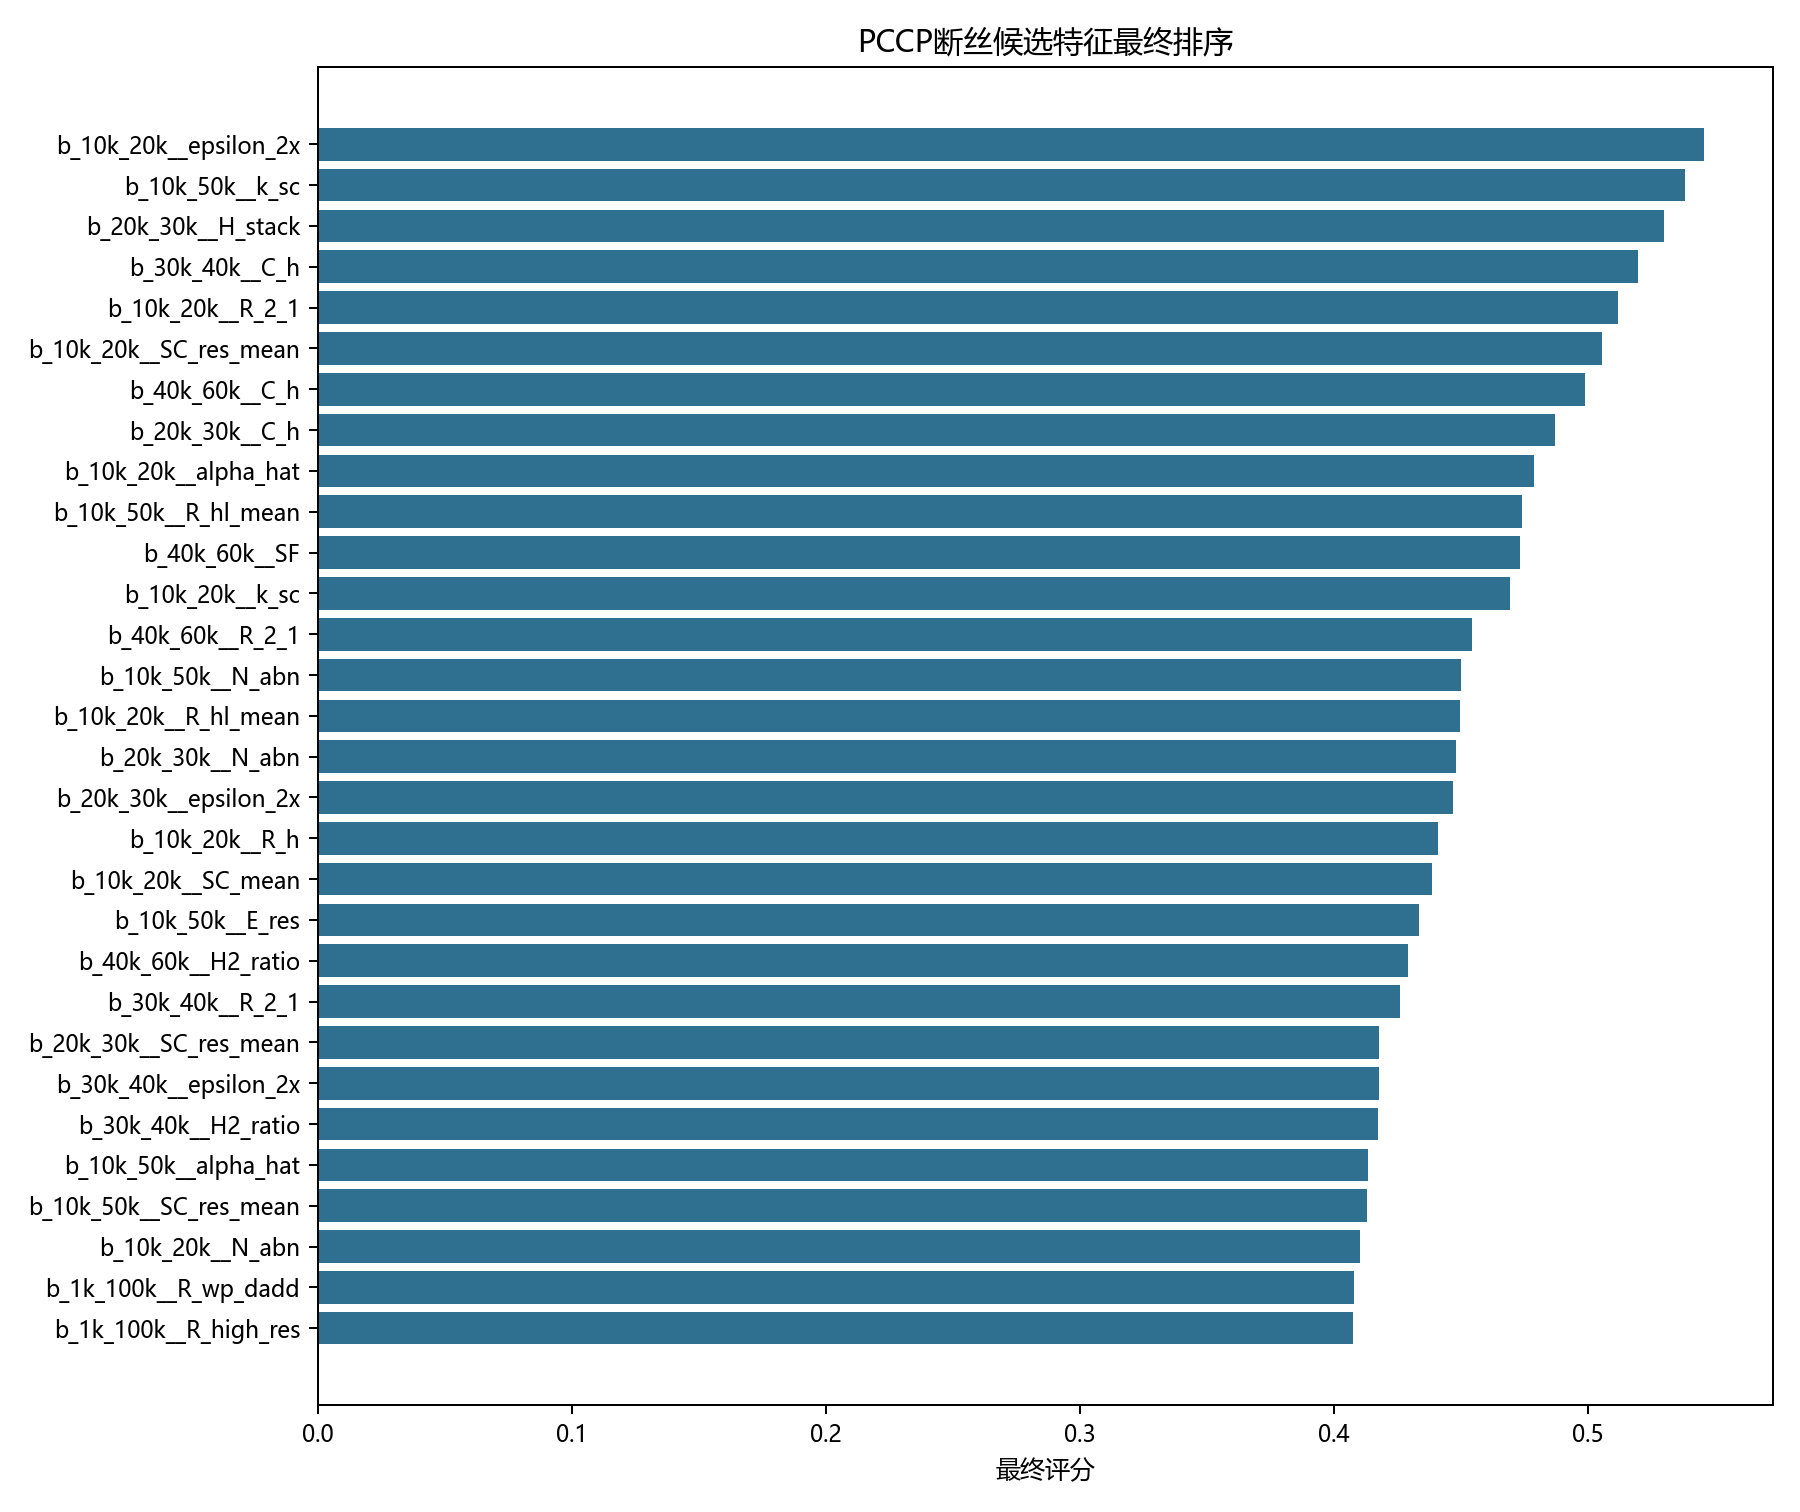

**图 20 最终Top特征六类箱线图**

<sub>图片已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\plots\图20_最终Top特征六类箱线图.png`</sub>

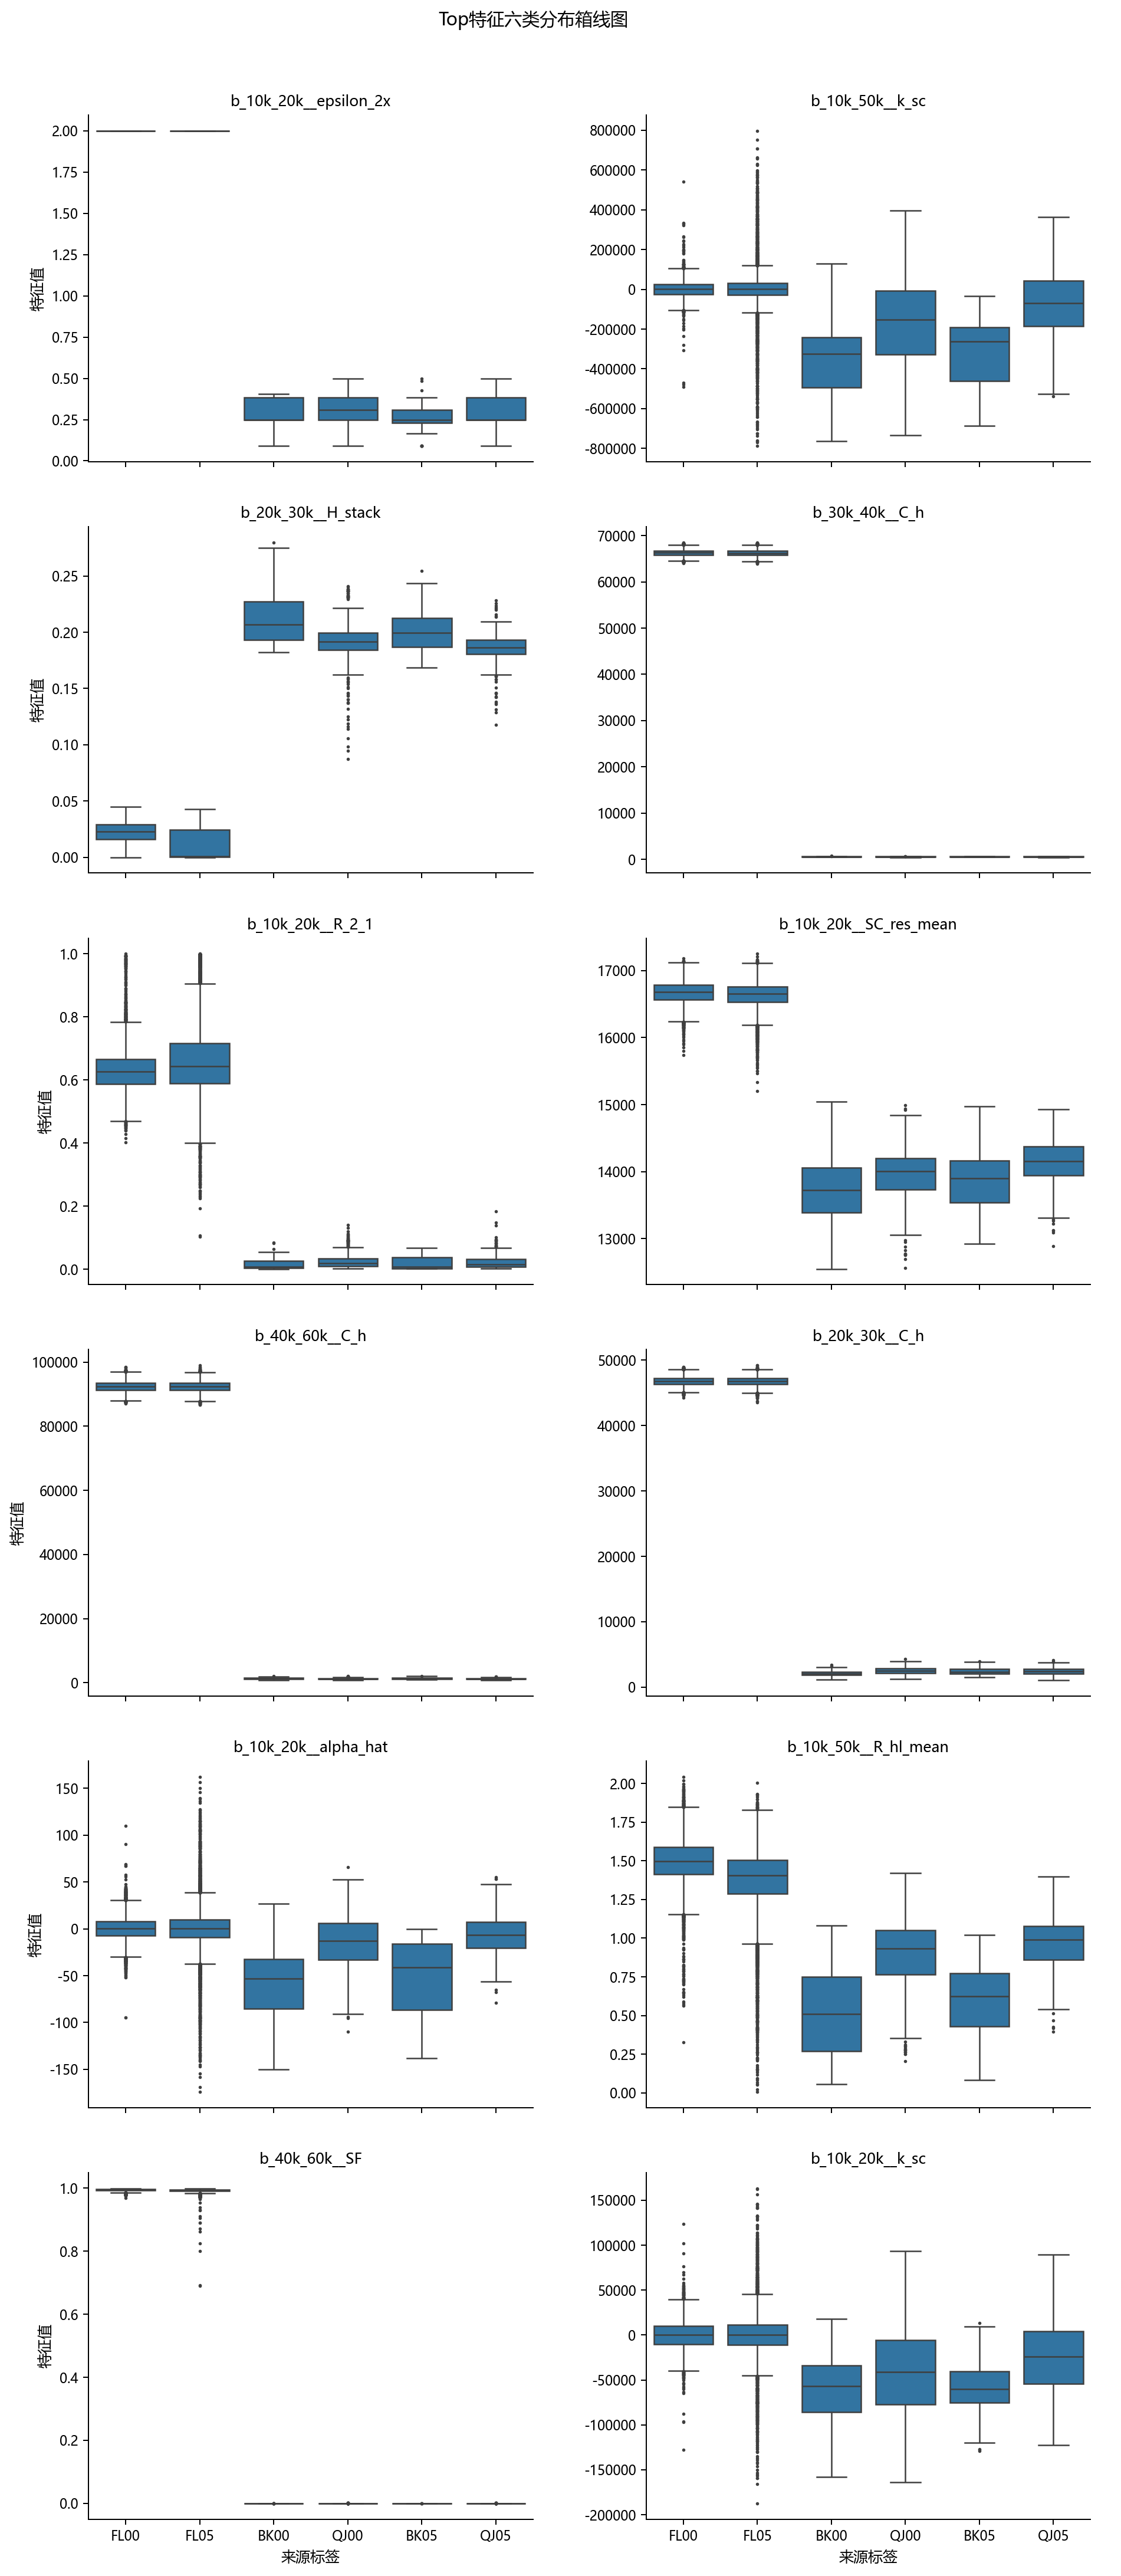

In [31]:
final_feature_ranking = build_final_ranking(
    feature_columns=feature_cols,
    discrimination=feature_discrimination,
    stability=feature_stability,
    cross_flow=cross_flow_feature,
    redundancy=correlation_cluster,
    mrmr_rank=mrmr_rank,
)
write_csv(add_feature_meaning_columns(final_feature_ranking), RUN_DIR / 'final_feature_ranking.csv')

final_ranking_path = RUN_DIR / 'plots/final_feature_ranking_top30.png'
top_boxplot_path = RUN_DIR / 'plots/top_feature_boxplots.png'
plot_final_ranking(final_feature_ranking, final_ranking_path, top_n=30)
plot_top_feature_boxplots(
    df,
    final_feature_ranking.head(CONFIG.max_plot_features)['feature'].tolist(),
    top_boxplot_path,
    max_features=12,
)

show_table('最终特征排序', final_feature_ranking)
show_image('最终特征Top30排序图', final_ranking_path)
show_image('最终Top特征六类箱线图', top_boxplot_path)


## 09 特征挖掘后的分类测试

本节验证挖掘出的特征能否支持实际分类，而不只是排名。

**模型与数据集划分**

- 模型：逻辑回归（Logistic Regression）、线性 SVM、RBF-SVM，均以标准化 + 该模型组成 pipeline。
- 划分规则更严格：在每个来源标签内部按 `source_file_name` 分组划分训练/测试，同一源文件不跨集合；训练集多数类最多采样到 `classification_max_train_rows_per_class`（3000），测试集保持分组划分后的真实分布，避免同源信息泄漏与样本混入。

**评价指标公式**（二分类，TP/FP/TN/FN 为四类计数）

- 平衡准确率：$\mathrm{balanced\_acc}=\frac{1}{2}\big(\frac{TP}{TP+FN}+\frac{TN}{TN+FP}\big)$，适合不均衡数据；
- AUC：ROC 曲线下面积，衡量排序能力；
- 正类召回率（断丝漏检程度）：$\mathrm{recall\_positive}=\frac{TP}{TP+FN}$；
- 特异度（误报程度）：$\mathrm{specificity}=\frac{TN}{TN+FP}$。

综合选择"综合分最高且特征数较少"的推荐组合。

In [32]:
from pccp_feature_mining.classification_test import run_classification_tests

classification_results, comparison_feature_recommendations = run_classification_tests(
    df,
    feature_discrimination=feature_discrimination,
    final_ranking=final_feature_ranking,
    output_dir=RUN_DIR / 'classification',
    feature_counts=CONFIG.classification_feature_counts,
    max_train_rows_per_class=CONFIG.classification_max_train_rows_per_class,
    random_state=CONFIG.random_state,
)
write_csv(add_feature_meaning_columns(classification_results), RUN_DIR / 'classification_test_results.csv')
write_csv(add_feature_meaning_columns(comparison_feature_recommendations), RUN_DIR / 'comparison_feature_recommendations.csv')
write_markdown_summary(RUN_DIR / 'summary_report.md', dataset_summary, final_feature_ranking, dataset.load_report)

show_table('分类测试结果', classification_results)
show_table('五个比较任务的推荐特征组合', comparison_feature_recommendations)

**表 36 分类测试结果**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表36_分类测试结果.csv`</sub>

,comparison,model,feature_count,train_rows,test_rows,train_positive,train_negative,test_positive,test_negative,accuracy,balanced_accuracy,auc,f1_positive,recall_positive,specificity,selected_features,selection_score,所选特征中文含义
10,BK00_vs_NONBK00,svm_linear,30,3072,3065,72,3000,30,3035,0.989,0.994,0.999,0.638,1.000,0.989,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,0.997,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
13,BK00_vs_NONBK00,svm_linear,50,3072,3065,72,3000,30,3035,0.989,0.995,0.999,0.645,1.000,0.989,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,0.997,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
12,BK00_vs_NONBK00,logistic_regression,50,3072,3065,72,3000,30,3035,0.981,0.990,1.000,0.508,1.000,0.981,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,0.996,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
9,BK00_vs_NONBK00,logistic_regression,30,3072,3065,72,3000,30,3035,0.974,0.987,0.999,0.426,1.000,0.973,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,0.994,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
0,BK00_vs_NONBK00,logistic_regression,5,3072,3065,72,3000,30,3035,0.949,0.974,0.994,0.279,1.000,0.949,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,0.987,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
1,BK00_vs_NONBK00,svm_linear,5,3072,3065,72,3000,30,3035,0.946,0.972,0.992,0.264,1.000,0.945,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,0.985,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
7,BK00_vs_NONBK00,svm_linear,20,3072,3065,72,3000,30,3035,0.973,0.970,0.997,0.411,0.967,0.973,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,0.979,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
4,BK00_vs_NONBK00,svm_linear,10,3072,3065,72,3000,30,3035,0.969,0.968,0.993,0.377,0.967,0.969,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,0.976,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
6,BK00_vs_NONBK00,logistic_regression,20,3072,3065,72,3000,30,3035,0.956,0.961,0.996,0.301,0.967,0.956,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,0.974,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
3,BK00_vs_NONBK00,logistic_regression,10,3072,3065,72,3000,30,3035,0.956,0.961,0.994,0.302,0.967,0.956,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,0.974,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...


**表 37 五个比较任务的推荐特征组合**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表37_五个比较任务的推荐特征组合.csv`</sub>

,comparison,recommended_feature_count,recommended_model,selection_score,balanced_accuracy,auc,recall_positive,specificity,recommended_features,split_note,推荐特征中文含义
0,BK00_vs_NONBK00,30,svm_linear,0.997,0.994,0.999,1.000,0.989,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,按source_file_name分组，且在每个来源标签内划分训练/测试；训练集多数类最多采...,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
1,BK00_vs_QJ00,50,logistic_regression,0.972,0.962,0.987,0.967,0.958,b_1k_10k__H2_ratio;b_1k_100k__R_wp_dada;b_1k_1...,按source_file_name分组，且在每个来源标签内划分训练/测试；训练集多数类最多采...,b_1k_10k__H2_ratio: 1-10 kHz频带，二倍频能量比，描述二倍频结构强...
2,BK05_vs_NONBK05,5,logistic_regression,0.995,0.993,0.995,1.000,0.986,b_20k_30k__R_res_hl_mean;b_20k_30k__E_res;b_10...,按source_file_name分组，且在每个来源标签内划分训练/测试；训练集多数类最多采...,b_20k_30k__R_res_hl_mean: 20-30 kHz频带，残差高低频能量比...
3,BK05_vs_QJ05,20,logistic_regression,0.981,0.958,0.999,1.000,0.917,b_1k_100k__R_wp_dada;b_1k_100k__R_wp_dadd;b_1k...,按source_file_name分组，且在每个来源标签内划分训练/测试；训练集多数类最多采...,b_1k_100k__R_wp_dada: 1-100 kHz频带，小波包节点能量占比 da...
4,BK_vs_NONBK,50,logistic_regression,0.995,0.990,0.999,1.000,0.979,b_20k_30k__H_stack;b_10k_50k__E_res;b_10k_20k_...,按source_file_name分组，且在每个来源标签内划分训练/测试；训练集多数类最多采...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...


,comparison,recommended_feature_count,recommended_model,selection_score,balanced_accuracy,auc,recall_positive,specificity,recommended_features,split_note,推荐特征中文含义
0,BK00_vs_NONBK00,30,svm_linear,0.997,0.994,0.999,1.000,0.989,b_10k_50k__R_hl_mean;b_10k_20k__H_stack;b_10k_...,按source_file_name分组，且在每个来源标签内划分训练/测试；训练集多数类最多采...,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
1,BK00_vs_QJ00,50,logistic_regression,0.972,0.962,0.987,0.967,0.958,b_1k_10k__H2_ratio;b_1k_100k__R_wp_dada;b_1k_1...,按source_file_name分组，且在每个来源标签内划分训练/测试；训练集多数类最多采...,b_1k_10k__H2_ratio: 1-10 kHz频带，二倍频能量比，描述二倍频结构强...
2,BK05_vs_NONBK05,5,logistic_regression,0.995,0.993,0.995,1.000,0.986,b_20k_30k__R_res_hl_mean;b_20k_30k__E_res;b_10...,按source_file_name分组，且在每个来源标签内划分训练/测试；训练集多数类最多采...,b_20k_30k__R_res_hl_mean: 20-30 kHz频带，残差高低频能量比...
3,BK05_vs_QJ05,20,logistic_regression,0.981,0.958,0.999,1.000,0.917,b_1k_100k__R_wp_dada;b_1k_100k__R_wp_dadd;b_1k...,按source_file_name分组，且在每个来源标签内划分训练/测试；训练集多数类最多采...,b_1k_100k__R_wp_dada: 1-100 kHz频带，小波包节点能量占比 da...
4,BK_vs_NONBK,50,logistic_regression,0.995,0.990,0.999,1.000,0.979,b_20k_30k__H_stack;b_10k_50k__E_res;b_10k_20k_...,按source_file_name分组，且在每个来源标签内划分训练/测试；训练集多数类最多采...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...


In [33]:
conclusion_rows = []
for _, row in comparison_feature_recommendations.iterrows():
    feats = str(row['recommended_features']).split(';')
    conclusion_rows.append({
        '比较任务': row['comparison'],
        '建议特征数量': int(row['recommended_feature_count']),
        '建议模型': row['recommended_model'],
        'balanced_accuracy越大越好': row['balanced_accuracy'],
        'auc越大越好': row['auc'],
        '断丝召回率越大越好': row['recall_positive'],
        'Other/QJ特异度越大越好': row['specificity'],
        '具体特征': '；'.join(feats),
        '具体特征中文含义': describe_feature_list(feats),
    })
conclusion_table = pd.DataFrame(conclusion_rows)
write_csv(conclusion_table, RUN_DIR / 'classification_conclusion_table.csv')
show_table('分类验证结论汇总', conclusion_table)

**表 38 分类验证结论汇总**

<sub>完整数据已存储: `E:\codes\ZZ-BK\outputs\PCCP_feature_mining_notebook\run_20260907_144308\tables\表38_分类验证结论汇总.csv`</sub>

,比较任务,建议特征数量,建议模型,balanced_accuracy越大越好,auc越大越好,断丝召回率越大越好,Other/QJ特异度越大越好,具体特征,具体特征中文含义
0,BK00_vs_NONBK00,30,svm_linear,0.994,0.999,1.000,0.989,b_10k_50k__R_hl_mean；b_10k_20k__H_stack；b_10k_...,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
1,BK00_vs_QJ00,50,logistic_regression,0.962,0.987,0.967,0.958,b_1k_10k__H2_ratio；b_1k_100k__R_wp_dada；b_1k_1...,b_1k_10k__H2_ratio: 1-10 kHz频带，二倍频能量比，描述二倍频结构强...
2,BK05_vs_NONBK05,5,logistic_regression,0.993,0.995,1.000,0.986,b_20k_30k__R_res_hl_mean；b_20k_30k__E_res；b_10...,b_20k_30k__R_res_hl_mean: 20-30 kHz频带，残差高低频能量比...
3,BK05_vs_QJ05,20,logistic_regression,0.958,0.999,1.000,0.917,b_1k_100k__R_wp_dada；b_1k_100k__R_wp_dadd；b_1k...,b_1k_100k__R_wp_dada: 1-100 kHz频带，小波包节点能量占比 da...
4,BK_vs_NONBK,50,logistic_regression,0.990,0.999,1.000,0.979,b_20k_30k__H_stack；b_10k_50k__E_res；b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...


,比较任务,建议特征数量,建议模型,balanced_accuracy越大越好,auc越大越好,断丝召回率越大越好,Other/QJ特异度越大越好,具体特征,具体特征中文含义
0,BK00_vs_NONBK00,30,svm_linear,0.994,0.999,1.000,0.989,b_10k_50k__R_hl_mean；b_10k_20k__H_stack；b_10k_...,b_10k_50k__R_hl_mean: 10-50 kHz频带，高低频能量比均值，描述高...
1,BK00_vs_QJ00,50,logistic_regression,0.962,0.987,0.967,0.958,b_1k_10k__H2_ratio；b_1k_100k__R_wp_dada；b_1k_1...,b_1k_10k__H2_ratio: 1-10 kHz频带，二倍频能量比，描述二倍频结构强...
2,BK05_vs_NONBK05,5,logistic_regression,0.993,0.995,1.000,0.986,b_20k_30k__R_res_hl_mean；b_20k_30k__E_res；b_10...,b_20k_30k__R_res_hl_mean: 20-30 kHz频带，残差高低频能量比...
3,BK05_vs_QJ05,20,logistic_regression,0.958,0.999,1.000,0.917,b_1k_100k__R_wp_dada；b_1k_100k__R_wp_dadd；b_1k...,b_1k_100k__R_wp_dada: 1-100 kHz频带，小波包节点能量占比 da...
4,BK_vs_NONBK,50,logistic_regression,0.990,0.999,1.000,0.979,b_20k_30k__H_stack；b_10k_50k__E_res；b_10k_20k_...,b_20k_30k__H_stack: 20-30 kHz频带，谐波栈能量比，描述多阶谐波组...


## 10 一键运行入口

本节提供命令式入口，适合不逐节查看中间结果时直接生成全部产物。它会自动创建带时间戳的输出目录，并生成方案约定的核心 CSV、分布图、组合搜索结果、最终排序和分类测试结果。正式分析建议保持 `bootstrap_rounds=200` 或更高；快速调试可设置 `max_rows_per_label` 和较小的 `bootstrap_rounds`。

In [34]:
from pccp_feature_mining.run_all import run_pccp_feature_mining

# summary = run_pccp_feature_mining(CONFIG)
# summary